# Is radar a reasonable sensor for an odometry factor graph in fast flight?

Vision-based odometry fails in smoke, dust, fog and darkness. Millimetre-wave
radar keeps working there, and a single-chip module is small enough to fly. The
question this notebook answers is whether that module is good enough to carry
a 6-DoF odometry factor graph on an agile quadrotor, and if so, what the factor
graph has to look like for it to work.

The answer is built from the raw rosbags, in three acts:

**Part I -- the sensor (the main result).** What one radar return means, what a
frame of returns can and cannot observe, and how the error behaves. Every
measurement here is *estimator-free*: residuals are formed against the MoCap
reference through the exact forward model, never against our own solver's
output. The act ends with the measured error model and the factor-graph design
it forces.

**Part II -- does it work.** The whole model goes into a sliding-window
continuous-time solver and each layer is ablated, so the claims of Part I are
tested rather than asserted.

**Part III -- is it competitive.** A held-out flight, a different platform (the
ICINS 2021 dataset), and a comparison against published EKF radar-inertial
odometry.

| Act | # | Question | Measurement | Consequence |
|---|---|---|---|---|
| I | 1 | What is this sensor? | chirp configuration | ambiguity/resolution/CPI budget |
| I | 2 | What does one return mean? | forward model vs MoCap | the radar factor |
| I | 3 | When do measurements arrive? | 10 Hz async, jitter, 50 ms CPI | continuous-time B-spline state |
| I | 4 | Is the ambiguity a corner case? | 2 to 38 % of points wrapped | per-frame unwrapping |
| I | 5 | What can one frame observe? | bearing geometry, conditioning | where radar is weak (vertical, forward) |
| I | 6 | How is the error distributed? | Gaussian core + structured tails | least squares + Huber backstop |
| I | 7 | Where does the error live? | elevation, SNR, per-point vs frame-shared | prefilter; SNR gives **no** usable weight (negative result) |
| I | 8 | How does it scale with dynamics? | per-point $\sigma$ vs speed and geometry | the adaptive weighting law |
| II | 9 | Is the spline the bottleneck? | representation error vs knot spacing | no (adaptive-knots negative result) |
| II | 10 | Why marginalize? | toy Gaussian demo | Schur + Markov blanket, prior scale 1.0 |
| II | 11 | Does it work? | run the solver, ablate every layer | one flag-free configuration |
| III | 12 | Is it competitive? | held-out, ICINS, EKF baselines | comparable, with a named failure regime |

**How to run**: kernel = the repo root `.venv` (python 3.12). Runs top to
bottom; the load cell (~2 min) caches three bags in memory, section 9 takes
~2 min, section 11 runs the real C++ solver (~1 min, skip with
`RUN_SOLVER = False`).

Sources: each analysis cell is adapted from the scripts that produced the paper
numbers (`analysis/characterize_radar.py`, `characterize_speed_law.py`,
`characterize_pointwise_noise.py`, `characterize_reference_immune.py`,
`characterize_frame_observability.py`, `characterize_imu_noise.py`,
`characterize_shape_contradiction.py`, `characterize_frame_correlation.py`,
`characterize_reference_immunity_bound.py`, `validate_live_solver.py`,
`radar_config_spec.py`, `derive_stream_weights.py`,
`adaptive_knots/v1_representation_error.py`); paper values are quoted inline so
every reproduced number can be cross-checked.


In [1]:
# Setup: repo-relative paths, imports, shared helpers
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'analysis' / 'lib').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('repo root not found (run from inside the repo)')
    REPO_ROOT = REPO_ROOT.parent
ANALYSIS = REPO_ROOT / 'analysis'
for p in (ANALYSIS, ANALYSIS / 'lib', ANALYSIS / 'adaptive_knots'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.signal import butter, filtfilt
from scipy.spatial.transform import Rotation, Slerp
from scipy.stats import linregress

from config_loader import load_config
from rosbag_loader.loader import load_bag_topics, stitch_cpu_counter_resets_improved
from radar_velocity_utils import (compute_doppler_residuals, rotation_matrix_from_euler,
                                  unwrap_doppler, quat_to_rotation_matrix)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'figure.figsize': (12, 4)})

# --- helpers copied from analysis/characterize_radar.py ---
def robust_sigma(x):
    '''1.4826 * MAD: sigma estimate insensitive to heavy tails.'''
    x = np.asarray(x)
    return 1.4826 * np.median(np.abs(x - np.median(x))) if len(x) else np.nan

def binned_sigma(x, residuals, edges, min_n=30):
    centers, sigmas, counts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        if np.sum(m) >= min_n:
            centers.append(0.5 * (lo + hi))
            sigmas.append(robust_sigma(residuals[m]))
            counts.append(int(np.sum(m)))
    return np.array(centers), np.array(sigmas), np.array(counts)

def binned_sigma_bias(x, residuals, edges, min_n=30):
    centers, sigmas, biases, counts = [], [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        if np.sum(m) >= min_n:
            centers.append(0.5 * (lo + hi))
            sigmas.append(robust_sigma(residuals[m]))
            biases.append(float(np.median(residuals[m])))
            counts.append(int(np.sum(m)))
    return np.array(centers), np.array(sigmas), np.array(biases), np.array(counts)

OMEGA_BIN_EDGES = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 14.0])
print(f'repo root: {REPO_ROOT}')

repo root: /home/mouse/MyData/radar-iwr6843-driver


---
# Part I -- Sensor

Everything in this act is measured against the MoCap reference through the
forward model, with no estimator in the loop. The act builds, in order: what
the sensor is, what one measurement means, when measurements arrive, what is
ambiguous about them, what a single frame can observe, how the error is
distributed, where it lives, and how it scales. It ends with the error model
and the factor graph that model forces.


## 0. Datasets and methodology

Three headline flights, one per regime: **slow racing** (gentle), **fast racing**
(aggressive, up to ~5 m/s), **backflips** (sustained flips to ~10 rad/s). Ground truth is
Vicon MoCap; the flight-controller state stream (`agiros_state`) carries the
MoCap-derived position, velocity, orientation and body rate used as the reference.

**The following residual definition is used by every section below:** for each radar return we
predict its Doppler *from the MoCap reference through the exact forward model the solver
uses* (bearing, extrinsics, lever arm) and analyze the per-point residual

$$ r = v_\mathrm{meas} - v_\mathrm{pred}(\mathrm{MoCap}). $$

Alias ambiguity is resolved against the ground-truth prediction here
(section 4 treats aliasing as its own property). Radar pitch is locked at a measured 27.5 deg.

In [2]:
# Load the three bags and compute per-point Doppler residuals (cached across re-runs)
CFG = load_config()
BAGS_CFG = CFG['bags']['bags']; TIMING = CFG['bags']['timing']
RC = CFG['bags'].get('radar_config', {}); EXT = CFG['extrinsics']

# Deployed extrinsics: pitch locked at the measured 27.5 deg (extrinsics.yaml keeps
# 25.5 only as the batch self-cal seed)
R_BS = rotation_matrix_from_euler(*np.radians([180.0, 27.5, 0.0]))
T_BS = np.array(EXT['translation_body_m'])
RADAR_OFF = EXT['imu_mocap_offset_sec'] - EXT['radar_imu_offset_sec']
IMU_OFF = EXT['imu_mocap_offset_sec']

BAG_KEYS = ['slow_racing_best_velocity', 'fast_racing_best_velocity',
            'backflips_best_velocity']
SHORT = {'slow_racing_best_velocity': 'slow racing',
         'fast_racing_best_velocity': 'fast racing',
         'backflips_best_velocity': 'backflips'}
COLOR = {'slow_racing_best_velocity': 'tab:blue',
         'fast_racing_best_velocity': 'tab:orange',
         'backflips_best_velocity': 'tab:red'}

D = globals().get('D', {})
for key in BAG_KEYS:
    if key in D:
        continue
    v_max = RC.get('best_velocity' if 'best_velocity' in key else 'default',
                   {}).get('v_max', 4.99)
    data = load_bag_topics(str(REPO_ROOT / BAGS_CFG[key]), verbose=False)
    t0 = data.start_time + TIMING[key][0]
    t1 = t0 + TIMING[key][1]
    radar = [f for f in data.radar_velocity
             if t0 <= f.timestamp <= t1 and f.positions is not None]
    imu = [m for m in data.imu_data if t0 <= m.timestamp <= t1]
    # pre-flight tail: the vehicle sits on the ground before t0, first with
    # motors off.  True rate is zero and true specific force is g there, so
    # it is the one reference-free IMU measurement this dataset contains
    # (used in section 8e).
    imu_pre = [m for m in data.imu_data if m.timestamp < t0]
    mocap_pre = [p for p in data.mocap_pose if p.timestamp < t0]
    states = data.agiros_state          # full range kept for interpolation
    dres = compute_doppler_residuals(states, radar, T_BS, R_BS,
                                     time_offset=RADAR_OFF, min_range=0.2)
    meas, pred = dres['measurements'], dres['predictions']
    unw = unwrap_doppler(meas, pred, v_max)   # ground-truth de-aliased
    r = unw - pred                            # the working residual everywhere below
    fi = np.array(dres['frame_indices']); pi = np.array(dres['point_indices'])
    st_t = np.array([s.timestamp for s in states])
    om_interp = interp1d(st_t, np.array([s.angular_velocity for s in states]),
                         axis=0, kind='linear', bounds_error=False,
                         fill_value='extrapolate')
    t_pts = np.array([radar[i].timestamp for i in fi]) + RADAR_OFF
    om_pts = np.linalg.norm(om_interp(t_pts), axis=1)
    u_z = np.array([radar[f].positions[p][2] / np.linalg.norm(radar[f].positions[p])
                    for f, p in zip(fi, pi)])
    D[key] = dict(v_max=v_max, t0=t0, t1=t1, radar=radar,
                  imu_pre=imu_pre, mocap_pre=mocap_pre,
                  bag_t0=data.start_time,
                  radar_full=list(data.radar_velocity), imu=imu, states=states,
                  mocap_pose=list(data.mocap_pose), dres=dres, meas=meas, pred=pred,
                  unw=unw, r=r, aliased=(unw != meas), fi=fi, pi=pi, om_pts=om_pts,
                  u_z=u_z, om_interp=om_interp, st_t=st_t)
    del data
    print(f'loaded {key}')

print(f"\n{'bag':<14} {'frames':>7} {'pts/frame':>10} {'frames<5':>9} "
      f"{'IMU rate':>9} {'v_max':>6}")
for key in BAG_KEYS:
    d = D[key]
    ppf = np.array([f.num_points() for f in d['radar']])
    imu_rate = (len(d['imu']) - 1) / (d['imu'][-1].timestamp - d['imu'][0].timestamp)
    print(f"{SHORT[key]:<14} {len(d['radar']):>7} {np.median(ppf):>10.0f} "
          f"{100 * np.mean(ppf < 5):>8.0f}% {imu_rate:>7.0f}Hz {d['v_max']:>6.3f}")
print('\npaper (Table: measured radar data properties): pts/frame 13 / 11 / 10, '
      'frames<5: 6 / 12 / 9 %')

# RANSAC prefilter masks (deployment order: consensus on unwrapped Doppler),
# built once and shared by sections 6 (ladder), 7 (demo), and 8e.
_rng_masks = np.random.default_rng(0)

def ransac_mask(P, v, thresh=0.15, iters=150):
    n = len(v)
    if n < 5:
        return np.ones(n, dtype=bool)
    Hn = P / np.maximum(np.linalg.norm(P, axis=1, keepdims=True), 1e-6)
    best = None
    for _ in range(iters):
        i3 = _rng_masks.choice(n, 3, replace=False)
        try:
            vc = np.linalg.solve(Hn[i3], v[i3])
        except np.linalg.LinAlgError:
            continue
        inl = np.abs(Hn @ vc - v) < thresh
        if best is None or inl.sum() > best.sum():
            best = inl
    return best if best is not None and best.sum() >= 5 else np.ones(n, dtype=bool)

masks = {}
for key in BAG_KEYS:
    d = D[key]
    masks[key] = {}
    for i, f in enumerate(d['radar']):
        if f.num_points() < 5:
            continue
        v = np.asarray(f.velocities, float).copy()
        sel = d['fi'] == i
        v[d['pi'][sel]] = d['unw'][sel]
        masks[key][i] = ransac_mask(np.asarray(f.positions, float), v)

loaded slow_racing_best_velocity


loaded fast_racing_best_velocity


loaded backflips_best_velocity

bag             frames  pts/frame  frames<5  IMU rate  v_max
slow racing        258         13        6%     993Hz  3.136
fast racing        179         11       12%     993Hz  3.136
backflips          181         10        9%     993Hz  3.136

paper (Table: measured radar data properties): pts/frame 13 / 11 / 10, frames<5: 6 / 12 / 9 %


## 1. Sensor explanation

Before any residual is computed: the module is a TI IWR6843AOPEVM, and the
driver uploads a chirp configuration that fixes every measurement property the
error model will need. Those properties are *derived from the configuration*
below, not inferred from the data -- which leaves the data free to serve as an
independent check.

Two configurations appear in this work: `6843AOP_best_velocity.cfg` for the
headline flights, and `6843AOP_3d.cfg` for the older flights used later as a
transfer test. They sit at opposite ends of the same trade.

The relations are the standard TDM-MIMO FMCW ones, and they all follow from how
one frame is built. The radar transmits a short frequency ramp -- a **chirp** --
lasting $T_c =$ idle + ramp. With $n_{TX}$ transmitters fired one after another,
one pass over all of them takes $T_\mathrm{loop} = n_{TX}T_c$, and that pass is
then repeated $N$ times to make one frame.

Those $N$ repeats are the **Doppler loops**, and they are what measures velocity:
a target's range barely changes between repeats, but the *phase* of its return
advances by a fixed step proportional to its radial velocity, so the processing
chain takes a second FFT *across the repeats* to read that step out. More repeats
means a longer look at that phase ramp, hence a finer velocity estimate. Their
total duration $T_\mathrm{CPI} = N\,T_\mathrm{loop}$ is the **coherent
processing interval**: the window the sensor integrates over to produce one
velocity number, and therefore the window over which the platform is implicitly
assumed not to change much.

Three consequences follow mechanically. Sampling the Doppler phase once per
$T_\mathrm{loop}$ sets the fastest velocity that can be read without wrapping
(Nyquist on that sampling); observing for $T_\mathrm{CPI}$ sets how finely
velocity can be resolved; and, separately, the bandwidth $B$ swept while the ADC
samples sets the range resolution:

$$ T_\mathrm{loop} = n_{TX} T_c, \qquad
   T_\mathrm{CPI} = N\,T_\mathrm{loop}, \qquad
   v_\mathrm{max} = \frac{\lambda}{4 T_\mathrm{loop}}, \qquad
   \Delta v = \frac{2 v_\mathrm{max}}{N} = \frac{\lambda}{2 T_\mathrm{CPI}},
   \qquad \Delta r = \frac{c}{2B} $$

The trade this notebook keeps running into is already visible: $N$ buys velocity
resolution and costs nothing in $v_\mathrm{max}$, but it stretches
$T_\mathrm{CPI}$ in exact proportion. What a longer $T_\mathrm{CPI}$ worsens is
the constancy assumption behind the Doppler estimate: each return's radial
velocity (the ego-velocity projected on its ray, with rotation moving the ray
during the window) must hold still for the whole CPI, and the measurement's
effective timestamp becomes a ~50 ms average rather than an instant. Section 3
hands exactly that to the continuous-time state.




In [3]:
# Sensor specification from the uploaded chirp config, checked against the data.
from radar_config_spec import spec, PROFILES, CFG_DIR

SPEC = {label: spec(CFG_DIR / fname) for label, fname in PROFILES.items()}
HEAD = SPEC['best_velocity (headline flights)']
OLDFW = SPEC['3d (old-firmware flights)']

rows = [
    ('TX (TDM) / Doppler loops', lambda s: f"{s['n_tx']} / {s['n_loops']}",
     'transmitters time-shared per Doppler sample / samples per frame'),
    ('chirp / Doppler-sample spacing', lambda s: f"{1e6*s['t_chirp']:.0f} / {1e6*s['t_loop']:.0f} us",
     'one FM ramp / time between two looks by the SAME transmitter'),
    ('CPI (coherent integration)', lambda s: f"{1e3*s['t_cpi']:.2f} ms",
     'window whose phase history becomes ONE velocity measurement'),
    ('frame period / duty cycle', lambda s: f"{1e3*s['period']:.0f} ms / {100*s['duty']:.0f} %",
     'time between point clouds / share of it spent measuring'),
    ('unambiguous velocity v_max', lambda s: f"{s['v_max']:.3f} m/s",
     'speed past which Doppler wraps; set by the sample spacing'),
    ('Doppler bin dv', lambda s: f"{s['dv']:.4f} m/s",
     'velocity resolution; set by the CPI (dv = lambda / 2 T_CPI)'),
    ('  quantization dv/sqrt(12)', lambda s: f"{s['quant']:.4f} m/s",
     'noise floor the bin width alone contributes'),
    ('valid bandwidth / range res', lambda s: f"{s['b_valid']:.0f} MHz / {s['dr']:.3f} m",
     'swept bandwidth while sampling / range cell it buys'),
    ('static clutter removal', lambda s: 'ON' if s['clutter'] else 'off',
     'on-chip deletion of zero-Doppler returns; MUST be off for ego-motion'),
]
labels = list(SPEC)
print(f"{'quantity':<32}" + ''.join(f'{x:>26}' for x in labels) + '   what it is')
for name, fn, what in rows:
    print(f'{name:<32}' + ''.join(f'{fn(SPEC[x]):>26}' for x in labels)
          + f'   {what}')

# --- the data's own view of the same quantities (independent check)
d = D['fast_racing_best_velocity']
vals = np.sort(np.unique(np.concatenate([np.asarray(f.velocities)
                                         for f in d['radar']])))
dvq = np.diff(vals); dvq = dvq[dvq > 1e-6]
rng_all = np.sort(np.unique(np.concatenate(
    [np.linalg.norm(np.asarray(f.positions, float), axis=1)
     for f in d['radar'] if f.positions is not None])))
drq = np.diff(rng_all); drq = drq[drq > 1e-6]
print()
print('measured from the recorded point clouds. NOTE this is a')
print('cross-implementation check, not a config-independent one: the firmware')
print('derives the reported velocities from the same .cfg by the same relations,')
print('so agreement confirms our arithmetic, not the configuration itself.')
print('(The .cfg HEADER disagrees -- it claims v_max 3.84 and dv 0.06 -- because')
print('it was generated before profileCfg was edited. The data agrees with the')
print('derivation, not with the header.)')
print(f'  Doppler quantization  {np.median(dvq):.4f} m/s   vs config {HEAD["dv"]:.4f}')
print(f'  range quantization    {np.median(drq):.3f} m     vs config {HEAD["dr"]:.3f}')
print(f'  v_max used in bags.yaml {d["v_max"]:.3f} m/s     vs config {HEAD["v_max"]:.3f}')
print()
print(f'The CPI is {1e3*HEAD["t_cpi"]:.1f} ms inside a {1e3*HEAD["period"]:.0f} ms frame: a radar')
print('"measurement" is a coherent AVERAGE over half the frame interval, not an')
print(f'instantaneous sample. At 4 m/s the platform moves {4*HEAD["t_cpi"]*100:.0f} cm during one.')


quantity                        best_velocity (headline flights) 3d (old-firmware flights)   what it is
TX (TDM) / Doppler loops                           3 / 128                    3 / 16   transmitters time-shared per Doppler sample / samples per frame
chirp / Doppler-sample spacing                130 / 390 us               83 / 249 us   one FM ramp / time between two looks by the SAME transmitter
CPI (coherent integration)                        49.92 ms                   3.98 ms   window whose phase history becomes ONE velocity measurement
frame period / duty cycle                    100 ms / 50 %              33 ms / 12 %   time between point clouds / share of it spent measuring
unambiguous velocity v_max                       3.148 m/s                 4.831 m/s   speed past which Doppler wraps; set by the sample spacing
Doppler bin dv                                  0.0492 m/s                0.6039 m/s   velocity resolution; set by the CPI (dv = lambda / 2 T_CPI)
  quantization 

> **Design consequence.** The "best velocity" profile buys a very fine Doppler
> bin (0.049 m/s, so velocity quantization contributes 0.014 m/s and is
> negligible) by spending 128 Doppler loops, and it pays for that three times
> over: the unambiguous velocity drops to $\pm 3.15$ m/s, which an agile
> quadrotor exceeds constantly (section 4); the range resolution coarsens to
> 0.214 m; and the coherent integration window stretches to 49.9 ms, half the
> frame period. That last ratio is a configuration property, not a law: chirping
> occupies the CPI at the start of each frame and the chip idles for the rest,
> so this configuration already spends half its wall clock integrating, and
> another doubling of $N$ would collide with the 10 Hz frame rate.
>
> Three things follow immediately, and each is picked up later:
> 1. **Doppler is the good channel, bearing is the coarse one.** The angular
>    resolution is ~30 deg. Section 5 measures what that costs, and section 8
>    finds that the bearing, not the Doppler, is what limits the noise model.
> 2. **The measurement is not instantaneous.** A 49.9 ms coherent average is a
>    first-order fact for a continuous-time state; the constant part of it is
>    absorbed by the time-offset calibration (section 3), but the variation
>    *within* the window cannot be.
> 3. **Static clutter removal must stay off.** It is enabled in the old
>    profile and disabled in the headline one. Ego-velocity estimation lives
>    entirely on static returns, so removing them removes the signal.


## 2. Forward model

A radar return is a bearing $\mathbf{u}_s$ (unit vector, sensor frame) plus a radial
Doppler velocity $v_d$. For a static world point observed from a moving platform:

$$ v_\mathrm{pred} = -\,\mathbf{u}_b^\top \left( R_{bw}\, \mathbf{v}_w \;+\;
   \boldsymbol{\omega}_b \times \mathbf{t}_{bs} \right), \qquad
   \mathbf{u}_b = R_{bs}\, \mathbf{u}_s $$

with $\mathbf{v}_w$ the platform velocity in world, $R_{bw}$ world-to-body rotation,
$\boldsymbol{\omega}_b \times \mathbf{t}_{bs}$ the lever-arm velocity of the radar
antenna (mounted 8 cm forward, 2 cm left, 1 cm below the body origin), and $R_{bs}$ the
mounting rotation (roll 180 deg, pitch 27.5 deg measured with an inclinometer).

**The minus sign** is the TI convention: positive Doppler = receding target. Flip it and nothing fits (demonstrated below).

slow racing  sigma_rob: correct 0.097   no lever arm 0.095   sign flipped 2.651  (m/s)
fast racing  sigma_rob: correct 0.189   no lever arm 0.185   sign flipped 2.054  (m/s)


backflips    sigma_rob: correct 0.354   no lever arm 0.368   sign flipped 1.494  (m/s)

bag           |L| median   |L| p90  var(no-lever)-var(correct)
slow racing        0.006     0.025                    -0.00043
fast racing        0.027     0.115                    -0.00149
backflips          0.079     0.321                    +0.01030

Reading the lever numbers: the term is signal ~ |omega| x 8.3 cm, but it is
computed from interpolated, jitter-timed MoCap omega, so it also carries an
error. On the racing flights the contribution is tiny (|L| median 0.006-0.027
m/s) and the error cancels the benefit: REMOVING the term even lowers sigma
by ~2%, which is at the edge of statistical resolution (sigma is estimated
to ~1.5% at these point counts). On backflips the contribution reaches
0.32 m/s at the 90th percentile (ceiling |omega| x 8.3 cm ~ 0.8 m/s at flip
rates) and clearly wins: removing it costs +0.010 in variance, far outside
the racing-bag scatter. The lever arm is a high-rate fea

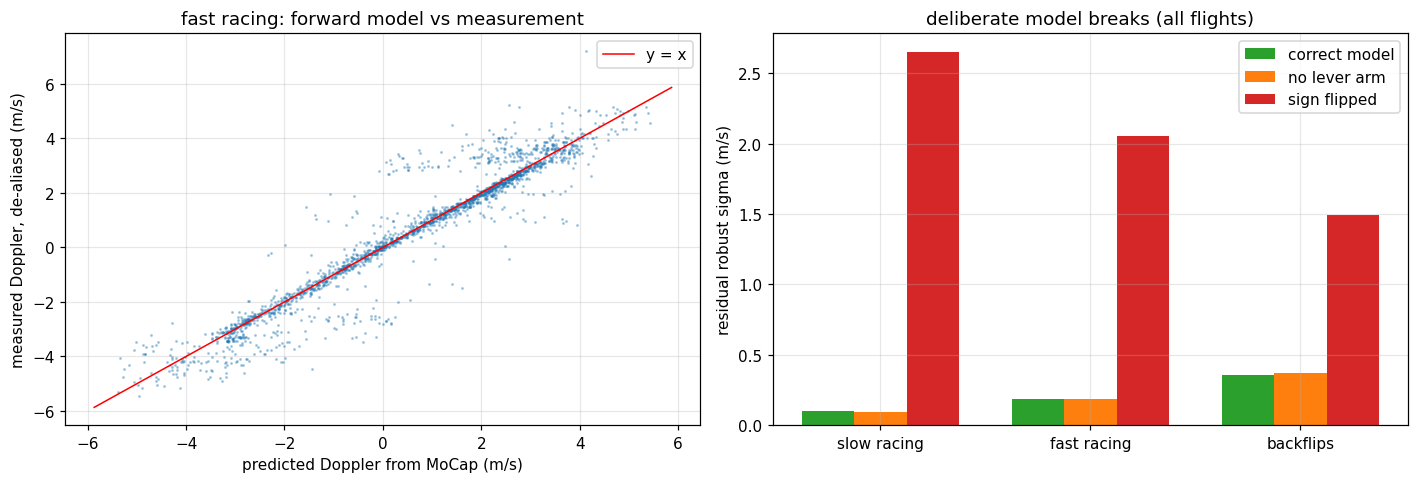

In [4]:
# Forward-model sanity: prediction vs measurement, then two deliberate model
# breaks on ALL flights (flip the Doppler sign; remove the lever arm), plus a
# measurement of the lever term's per-point contribution |L| to see in which
# regime it carries signal.
rows, labels, lever_stats = [], [], []
for key in BAG_KEYS:
    d = D[key]
    s_ok = robust_sigma(d['r'])
    unw_f = unwrap_doppler(d['meas'], -d['pred'], d['v_max'])
    s_flip = robust_sigma(unw_f - (-d['pred']))
    dres_nl = compute_doppler_residuals(d['states'], d['radar'], np.zeros(3), R_BS,
                                        time_offset=RADAR_OFF, min_range=0.2)
    unw_nl = unwrap_doppler(dres_nl['measurements'], dres_nl['predictions'], d['v_max'])
    s_nl = robust_sigma(unw_nl - dres_nl['predictions'])
    L = d['pred'] - dres_nl['predictions']          # the modeled lever contribution
    rows.append([s_ok, s_nl, s_flip]); labels.append(SHORT[key])
    lever_stats.append((np.median(np.abs(L)), np.percentile(np.abs(L), 90),
                        s_nl**2 - s_ok**2))
    print(f"{SHORT[key]:<12} sigma_rob: correct {s_ok:.3f}   no lever arm {s_nl:.3f}   "
          f"sign flipped {s_flip:.3f}  (m/s)")
print()
print(f"{'bag':<12} {'|L| median':>11} {'|L| p90':>9} {'var(no-lever)-var(correct)':>27}")
for lb, (l50, l90, dv) in zip(labels, lever_stats):
    print(f'{lb:<12} {l50:>11.3f} {l90:>9.3f} {dv:>+27.5f}')
print()
print('Reading the lever numbers: the term is signal ~ |omega| x 8.3 cm, but it is')
print('computed from interpolated, jitter-timed MoCap omega, so it also carries an')
print('error. On the racing flights the contribution is tiny (|L| median 0.006-0.027')
print('m/s) and the error cancels the benefit: REMOVING the term even lowers sigma')
print('by ~2%, which is at the edge of statistical resolution (sigma is estimated')
print('to ~1.5% at these point counts). On backflips the contribution reaches')
print('0.32 m/s at the 90th percentile (ceiling |omega| x 8.3 cm ~ 0.8 m/s at flip')
print('rates) and clearly wins: removing it costs +0.010 in variance, far outside')
print('the racing-bag scatter. The lever arm is a high-rate feature; it earns its place in')
print('the regime that needs it and costs nothing measurable elsewhere.')

d = D['fast_racing_best_velocity']
sub = np.random.default_rng(0).choice(len(d['pred']), min(4000, len(d['pred'])),
                                      replace=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(d['pred'][sub], d['unw'][sub], '.', ms=2, alpha=0.3)
lim = np.percentile(np.abs(d['pred']), 99.5) * 1.15
axes[0].plot([-lim, lim], [-lim, lim], 'r-', lw=1, label='y = x')
axes[0].set_xlabel('predicted Doppler from MoCap (m/s)')
axes[0].set_ylabel('measured Doppler, de-aliased (m/s)')
axes[0].set_title('fast racing: forward model vs measurement')
axes[0].legend()
x = np.arange(len(labels)); w = 0.25
for i, (name, c) in enumerate([('correct model', 'tab:green'),
                               ('no lever arm', 'tab:orange'),
                               ('sign flipped', 'tab:red')]):
    axes[1].bar(x + (i - 1) * w, [r[i] for r in rows], w, label=name, color=c)
axes[1].set_xticks(x, labels)
axes[1].set_ylabel('residual robust sigma (m/s)')
axes[1].set_title('deliberate model breaks (all flights)')
axes[1].legend()
fig.tight_layout()

<details>
<summary><b>Unfold: what σ<sub>rob</sub> is, and why not the standard deviation</b></summary>

> Every spread quoted in this notebook is $\sigma_\mathrm{rob}$ rather than the
> sample standard deviation. For a sensor whose whole story is heavy tails, that
> choice is not cosmetic.
>
> **The construction.** Take the median of the data; take the absolute deviations
> from it; take *their* median. That is the median absolute deviation,
> $\mathrm{MAD} = \mathrm{median}_j\,\lvert x_j - \mathrm{median}(x)\rvert$, and
>
> $$ \sigma_\mathrm{rob} = 1.4826\,\cdot\,\mathrm{MAD}. $$
>
> **Where 1.4826 comes from.** For data that really is Gaussian the MAD converges
> to $0.6745\,\sigma$ (that is the 75th percentile of a standard normal), so
> multiplying by $1/0.6745 = 1.4826$ makes $\sigma_\mathrm{rob}$ an estimate of
> the *same* $\sigma$ the standard deviation estimates. On clean Gaussian data
> the two agree; the constant exists precisely so they are comparable.
>
> **Why not the standard deviation.** It is a mean of squares, so every point
> contributes in proportion to the square of how far out it sits: one return at
> $10\sigma$ moves it noticeably. The median ignores everything outside the middle
> of the sample. In estimator terms the standard deviation has a **breakdown point
> of 0** -- a single bad point can carry it anywhere -- while the MAD's is
> **50 %**: half the data must be corrupted before it moves. That is not a
> technicality here. Section 6 measures 2-12 % of returns beyond $3\sigma$, which
> is more than enough to inflate a standard deviation while leaving
> $\sigma_\mathrm{rob}$ still reporting the width of the core.
>
> **So it answers a specific question:** *how wide is the well-behaved bulk of this
> distribution?* -- not *how much total spread is there?* Both are wanted, which is
> why section 6 quotes the 1-99 % standard deviation alongside it. That one *does*
> respond to tails, and the gap between the two is itself a tail measurement.

</details>

> **Design consequence.** Both conventions survive their break test, so the forward
> model as written is justified as the radar factor everywhere downstream. The sign
> flip is catastrophic (sigma 0.10-0.35 to 1.5-2.7 m/s): the TI receding-positive
> convention is settled. The lever arm is a high-rate feature: at racing rates its
> contribution is tiny and its interpolation/timing error cancels the benefit
> (removing it shifts sigma by about -2%, at the edge of statistical resolution),
> while at flip rates the contribution reaches 0.32 m/s at the 90th percentile and removing it measurably
> degrades the fit. It earns its place in the regime that needs it and costs nothing
> measurable elsewhere. (In the solver, omega comes from the estimated spline rather
> than interpolated MoCap, so the racing-rate error term there is, if anything,
> smaller.)

## 3. Temporal structure

Three timing facts decide the estimator architecture before any tuning happens.

Three returns determine a 3D ego-velocity exactly; five is the practical floor
for any outlier-robust per-frame fit. 6-12% of frames are below it.


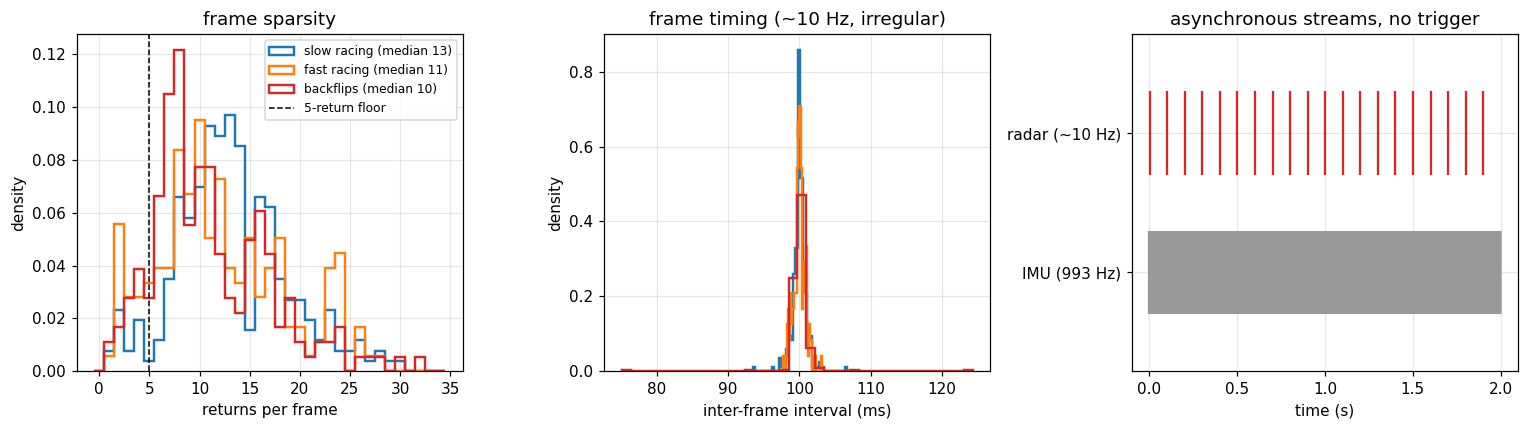

In [5]:
# 2a. Rates and sparsity: 10 Hz radar vs ~1 kHz IMU, and thin frames
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for key in BAG_KEYS:
    d = D[key]
    ppf = np.array([f.num_points() for f in d['radar']])
    axes[0].hist(ppf, bins=np.arange(0, 36) - 0.5, histtype='step', lw=1.6,
                 label=f"{SHORT[key]} (median {np.median(ppf):.0f})",
                 color=COLOR[key], density=True)
    ft = np.array([f.timestamp for f in d['radar']])
    axes[1].hist(1e3 * np.diff(ft), bins=40, histtype='step', lw=1.6,
                 color=COLOR[key], density=True)
axes[0].axvline(5, color='k', ls='--', lw=1, label='5-return floor')
axes[0].set_xlabel('returns per frame'); axes[0].set_ylabel('density')
axes[0].set_title('frame sparsity')
axes[0].legend(fontsize=8)
axes[1].set_xlabel('inter-frame interval (ms)'); axes[1].set_ylabel('density')
axes[1].set_title('frame timing (~10 Hz, irregular)')

# a 2 s slice of arrival times: radar frames vs IMU samples
d = D['fast_racing_best_velocity']
tt0 = d['t0'] + 0.5 * (d['t1'] - d['t0'])   # window midpoint
ft = np.array([f.timestamp for f in d['radar']])
it = np.array([m.timestamp for m in d['imu']])
fsel = ft[(ft >= tt0) & (ft < tt0 + 2)] - tt0
isel = it[(it >= tt0) & (it < tt0 + 2)] - tt0
axes[2].eventplot([isel, fsel], lineoffsets=[0, 1], linelengths=0.6,
                  colors=['0.6', 'tab:red'])
axes[2].set_yticks([0, 1], ['IMU (993 Hz)', 'radar (~10 Hz)'])
axes[2].set_xlabel('time (s)'); axes[2].set_title('asynchronous streams, no trigger')
fig.tight_layout()
print('Three returns determine a 3D ego-velocity exactly; five is the practical floor')
print('for any outlier-robust per-frame fit. 6-12% of frames are below it.')

bag             clock MHz       R^2    sigma  rob sigma     p95     max   kurt


slow racing         200.0  1.000000  1.69ms    0.41ms  1.2ms   36ms  356.9
fast racing         200.0  1.000000  0.73ms    0.58ms  1.3ms    7ms   14.8
backflips           200.0  1.000000  6.62ms    0.82ms  2.1ms  132ms  363.5

paper: jitter sigma 1.7 / 0.7 / 6.6 ms
Distribution: a narrow near-Gaussian core plus sparse one-sided delay
spikes (one-sided, consistent with host-side buffering stalls, not separately
identified; excess kurtosis far above 0), so the
jitter is NOT Gaussian in the tails; sigma is dominated by the spikes
while the robust sigma shows the well-behaved core.


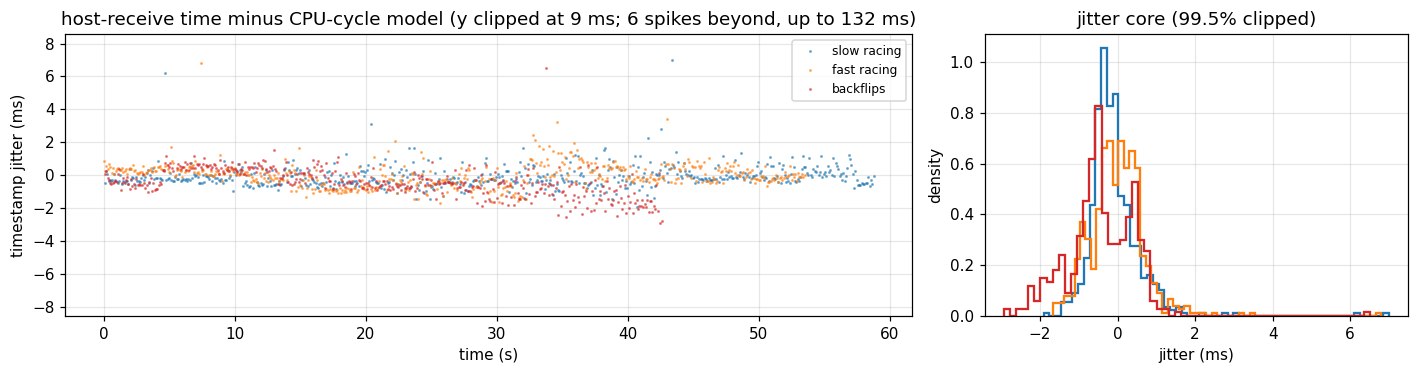

In [6]:
# 2b. Per-frame timestamp jitter, measured from the radar's own CPU-cycle counter
# (regress on-chip cycle count against host receive time; the scatter around the
#  line is the timing jitter of the frame timestamps we are forced to use)
print(f"{'bag':<14} {'clock MHz':>10} {'R^2':>9} {'sigma':>8} {'rob sigma':>10} "
      f"{'p95':>7} {'max':>7} {'kurt':>6}")
jit_save = {}
for key in BAG_KEYS:
    stitched, _ = stitch_cpu_counter_resets_improved(D[key]['radar_full'],
                                                     verbose=False)
    tr = np.array([f.timestamp for f in stitched
                   if f.time_cpu_cycles is not None and len(f.time_cpu_cycles)
                   and f.time_cpu_cycles[0] > 0])
    cc = np.array([f.time_cpu_cycles[0] for f in stitched
                   if f.time_cpu_cycles is not None and len(f.time_cpu_cycles)
                   and f.time_cpu_cycles[0] > 0])
    sl, ic, rv, _, _ = linregress(cc, tr)
    jit = tr - (sl * cc + ic)
    jit_save[key] = (tr, jit)
    print(f"{SHORT[key]:<14} {1/sl/1e6:>10.1f} {rv**2:>9.6f} "
          f"{1e3*np.std(jit):>5.2f}ms {1e3*robust_sigma(jit):>7.2f}ms "
          f"{1e3*np.percentile(np.abs(jit),95):>4.1f}ms "
          f"{1e3*np.max(np.abs(jit)):>4.0f}ms {sp_stats.kurtosis(jit):>6.1f}")
print('\npaper: jitter sigma 1.7 / 0.7 / 6.6 ms')
print('Distribution: a narrow near-Gaussian core plus sparse one-sided delay')
print('spikes (one-sided, consistent with host-side buffering stalls, not separately')
print('identified; excess kurtosis far above 0), so the')
print('jitter is NOT Gaussian in the tails; sigma is dominated by the spikes')
print('while the robust sigma shows the well-behaved core.')

# y-range clipped to the 99.5% quantile so the core is visible; spikes annotated
allj = np.concatenate([1e3 * j for _, j in jit_save.values()])
ylim = 1.3 * np.percentile(np.abs(allj), 99.5)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5),
                         gridspec_kw={'width_ratios': [2, 1]})
n_clip = 0
for key in BAG_KEYS:
    tr, jit = jit_save[key]
    axes[0].plot(tr - tr[0], 1e3 * jit, '.', ms=2, alpha=0.5, color=COLOR[key],
                 label=SHORT[key])
    n_clip += int(np.sum(np.abs(1e3 * jit) > ylim))
    core = 1e3 * jit[np.abs(1e3 * jit) < ylim]
    axes[1].hist(core, bins=60, histtype='step', lw=1.5, density=True,
                 color=COLOR[key])
axes[0].set_ylim(-ylim, ylim)
axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('timestamp jitter (ms)')
axes[0].set_title(f'host-receive time minus CPU-cycle model '
                  f'(y clipped at {ylim:.0f} ms; {n_clip} spikes beyond, '
                  f'up to {np.max(np.abs(allj)):.0f} ms)')
axes[0].legend(fontsize=8)
axes[1].set_xlabel('jitter (ms)'); axes[1].set_ylabel('density')
axes[1].set_title('jitter core (99.5% clipped)')
fig.tight_layout()

paper: sweep confirms the calibrated offset within 5 ms on the racing flights
(backflips, not swept here, has a shallow minimum near 25 ms in the
calibration record).


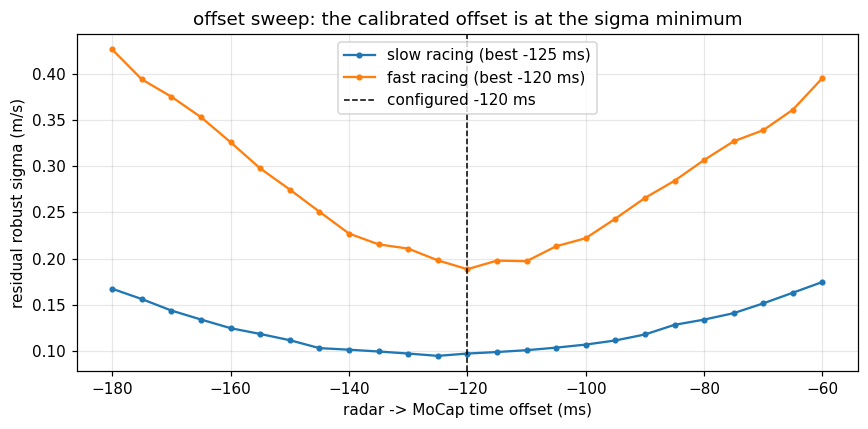

In [7]:
# 2c. The radar-to-MoCap time offset, found by a residual-sigma sweep.
# Why the sigma MINIMUM is the right offset: a misalignment dt adds an error
# term ~ (d v_pred/dt) * dt = radial-jerk-and-accel * dt to every residual,
# statistically independent of the sensor noise, so the spread adds in
# quadrature and is minimized exactly when the clocks align. The faster the
# dynamics, the sharper the minimum (hover data would give a flat curve;
# backflips gives a shallow one because sigma is already dominated by
# flip-regime noise).
fig, ax = plt.subplots(figsize=(8, 4))
for key in ['slow_racing_best_velocity', 'fast_racing_best_velocity']:
    d = D[key]
    offs = RADAR_OFF + np.linspace(-0.06, 0.06, 25)
    sig = []
    for o in offs:
        dd = compute_doppler_residuals(d['states'], d['radar'], T_BS, R_BS,
                                       time_offset=float(o), min_range=0.2)
        ru = unwrap_doppler(dd['measurements'], dd['predictions'], d['v_max']) \
            - dd['predictions']
        sig.append(robust_sigma(ru))
    best = offs[int(np.argmin(sig))]
    ax.plot(1e3 * offs, sig, '-o', ms=3, color=COLOR[key],
            label=f'{SHORT[key]} (best {1e3*best:.0f} ms)')
ax.axvline(1e3 * RADAR_OFF, color='k', ls='--', lw=1,
           label=f'configured {1e3*RADAR_OFF:.0f} ms')
ax.set_xlabel('radar -> MoCap time offset (ms)')
ax.set_ylabel('residual robust sigma (m/s)')
ax.set_title('offset sweep: the calibrated offset is at the sigma minimum')
ax.legend()
fig.tight_layout()
print('paper: sweep confirms the calibrated offset within 5 ms on the racing flights')
print('(backflips, not swept here, has a shallow minimum near 25 ms in the')
print('calibration record).')

> **Design consequence.** Frames are sparse, come at 10 Hz, are not synchronized to the
> IMU, and only frame-level timestamps exist, with 0.7 to 6.6 ms jitter. A
> continuous-time B-spline handles all of that directly: it can be read out at any
> timestamp, gives velocity and body rate in closed form, and needs no preintegration
> around changing biases. The missing per-chirp timestamps return as a term this work cannot separate:
> intra-frame smearing during a flip, which 8b reads as a flip-regime error
> sitting on top of the bearing law.
>
> *Open lever (checked, not built):* the radar's cycle counter is a much better clock
> than the USB receive time. Using it would remove the measured jitter. Order-of-
> magnitude worth (jitter times flip dynamics): ~0.1 m/s and a few degrees, and only
> at backflip rates; nothing on racing.

## 4. Aliasing

The firmware wraps Doppler into $\pm v_\mathrm{max} = \pm 3.136$ m/s (this radar config
trades unambiguous range for the fine 0.049 m/s resolution of section 1).
Anything faster wraps around.

bag             aliased points
slow racing               2.0%
fast racing              23.7%
backflips                37.8%

paper: 2.0 / 23.7 / 37.8 %  ->  on aggressive flights de-aliasing is a
first-order property of the data, not a corner case.


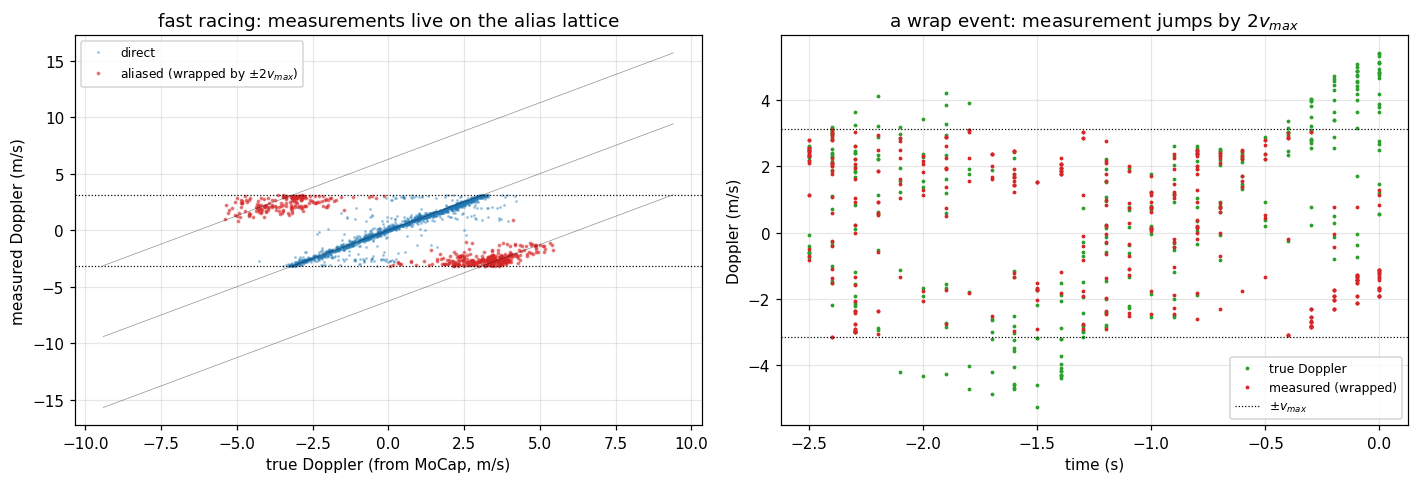

In [8]:
# Aliased fraction per bag + what a wrap looks like in the raw stream
print(f"{'bag':<14} {'aliased points':>15}")
for key in BAG_KEYS:
    print(f"{SHORT[key]:<14} {100*np.mean(D[key]['aliased']):>14.1f}%")
print('\npaper: 2.0 / 23.7 / 37.8 %  ->  on aggressive flights de-aliasing is a')
print('first-order property of the data, not a corner case.')

d = D['fast_racing_best_velocity']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sub = np.random.default_rng(1).choice(len(d['pred']), min(6000, len(d['pred'])),
                                      replace=False)
al = d['aliased'][sub]
axes[0].plot(d['pred'][sub][~al], d['meas'][sub][~al], '.', ms=2, alpha=0.3,
             color='tab:blue', label='direct')
axes[0].plot(d['pred'][sub][al], d['meas'][sub][al], '.', ms=3, alpha=0.5,
             color='tab:red', label='aliased (wrapped by $\\pm 2 v_{max}$)')
vm = d['v_max']
for k in (-1, 0, 1):
    xg = np.linspace(-3 * vm, 3 * vm, 10)
    axes[0].plot(xg, xg + k * 2 * vm, 'k-', lw=0.5, alpha=0.4)
axes[0].axhline(vm, color='k', ls=':', lw=0.8); axes[0].axhline(-vm, color='k', ls=':', lw=0.8)
axes[0].set_xlabel('true Doppler (from MoCap, m/s)')
axes[0].set_ylabel('measured Doppler (m/s)')
axes[0].set_title('fast racing: measurements live on the alias lattice')
axes[0].legend(fontsize=8)

# time slice around the largest |pred|: the sawtooth
t_pts = np.array([d['radar'][i].timestamp for i in d['fi']]) + RADAR_OFF
i_max = np.argmax(np.abs(d['pred']))
tc = t_pts[i_max]
sel = (t_pts > tc - 2.5) & (t_pts < tc + 2.5)
axes[1].plot(t_pts[sel] - tc, d['pred'][sel], '.', ms=3, color='tab:green',
             label='true Doppler')
axes[1].plot(t_pts[sel] - tc, d['meas'][sel], '.', ms=3, color='tab:red',
             label='measured (wrapped)')
axes[1].axhline(vm, color='k', ls=':', lw=0.8, label='$\\pm v_{max}$')
axes[1].axhline(-vm, color='k', ls=':', lw=0.8)
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('Doppler (m/s)')
axes[1].set_title('a wrap event: measurement jumps by $2 v_{max}$')
axes[1].legend(fontsize=8)
fig.tight_layout()

> **Design consequence.** The solver consumes unwrapped Doppler: once per frame, the
> alias is picked using a predicted velocity, which only needs to be right to within
> $\pm 3.1$ m/s, so an IMU-integrated velocity is enough. What cannot be fixed
> downstream is the aliased detection's on-chip bearing (computed from the wrapped
> velocity). The measured treatment of that partial information -- a
> constant inverse-variance down-weight -- is in 8f.

## 5. What one frame can observe

A frame of $N$ returns gives $N$ Doppler scalars and $N$ bearings, and together
they determine the 3-DoF ego-velocity through $v_{r,j} = -\mathbf u_j^\top
\mathbf v$, i.e. a linear system $H\mathbf v = -\mathbf v_r$ with $H$ the
stacked unit bearings. How well that system is conditioned, and which body axis
is worst, is a property of the sensor and the scene geometry alone. It says what
*one frame on its own* is worth, which is the natural yardstick to hold the
fused estimate against -- not a lower bound on it, since a multi-frame smoother
with an IMU can and should do better than any single frame.

Two error components propagate differently, and separating them is the point of
this section. Writing the per-return Doppler error as a per-point part
$\sigma_i$ and a part $\sigma_c$ shared by the whole frame (section 8 measures
both), the **error covariance** of the velocity this one frame estimates is

$$ \operatorname{Cov}(\hat{\mathbf v}) = \sigma_i^2 (H^\top H)^{-1}
   \;+\; \sigma_c^2\, \mathbf g \mathbf g^\top, \qquad
   \mathbf g = (H^\top H)^{-1} H^\top \mathbf 1 $$

$\hat{\mathbf v}$ is the $3\times1$ velocity the frame would estimate on its own,
so this is a $3\times3$ matrix and it reads exactly as you would expect a
covariance to: the **diagonal** holds the variance of the error in each body axis
(multiply by a noise scale in m/s and take the square root to get that axis's
error), and the **off-diagonal** entries say how those three axis errors move
together. Only two things are taken from it below -- the diagonal, and the
*direction* the second term points in.

The first term shrinks as returns are added; the second does **not**, at any
$N$, because a Doppler offset common to the frame is indistinguishable from
real motion along $\mathbf g$.

<details>
<summary><b>Unfold: where that covariance comes from, term by term</b></summary>

> **The symbols.** $\mathbf v$ is the platform's true 3-D velocity in the body
> frame, and $\hat{\mathbf v}$ is the estimate a single frame gives when we
> solve its returns by least squares -- *not* a measured quantity, but the
> answer this one frame would produce on its own. $H$ is the
> $N\times 3$ matrix whose row $j$ is the unit ray $\mathbf u_j^\top$ toward
> return $j$. $\mathbf v_r$ stacks the $N$ measured radial speeds. $\mathbf 1$
> is a column of $N$ ones.
>
> **The estimate.** Each return says $v_{r,j} = -\mathbf u_j^\top\mathbf v$, so
> the frame says $H\mathbf v = -\mathbf v_r$: $N$ equations, 3 unknowns. Least
> squares gives $\hat{\mathbf v} = -(H^\top H)^{-1}H^\top \mathbf v_r$.
>
> **Term 1, the per-point error.** Suppose each return's Doppler carries its own
> independent error of size $\sigma_i$. Standard least-squares propagation
> (push a covariance $\sigma_i^2 I$ through the linear map above) gives
> $\sigma_i^2 (H^\top H)^{-1}$. The matrix $(H^\top H)^{-1}$ is pure geometry:
> it says how much a given ray layout amplifies per-return noise into each
> velocity axis. With rays spread evenly over a sphere it would be
> $\tfrac{3}{N}I$, i.e. error falling like $1/\sqrt N$; with the rays bunched
> into a narrow cone it blows up along the directions nothing looks at.
>
> **Term 2, the frame-shared error.** Now suppose the whole frame is off by the
> *same* amount $c$ (a reference-velocity error at that instant, a timestamp
> error, a scene-wide effect). Then $\mathbf v_r$ shifts by $c\,\mathbf 1$, and
> pushing that through the same formula shifts the estimate by exactly
> $-c\,\mathbf g$ with $\mathbf g = (H^\top H)^{-1}H^\top\mathbf 1$. Since $c$
> is random with size $\sigma_c$, that contributes $\sigma_c^2\,\mathbf g
> \mathbf g^\top$ -- a rank-one covariance, i.e. an error confined to the single
> direction $\mathbf g$.
>
> **Why $\mathbf g$ is a direction of motion.** $\mathbf g$ is the velocity that
> best explains "every return reads 1 m/s too fast". If all rays pointed the
> same way $\mathbf u$, that would be motion along $\mathbf u$, and
> $\mathbf g$ would be $\mathbf u$ itself. Real frames have spread, so
> $\mathbf g$ is the least-squares compromise -- roughly the mean ray direction,
> which for a forward-and-down-looking radar is mostly the body $x$ axis. That
> is why a frame-common Doppler error reads as *forward* motion.
>
> **Why one averages down and the other does not.** This is visible directly once
> $H^\top H$ is written out. $H$ stacks the $N$ unit bearings as rows, so both of
> the quantities in the formula are **sums of $N$ terms**:
>
> $$ H^\top H = \sum_{j=1}^{N} \mathbf u_j\mathbf u_j^\top
>    = N\,\overline{\mathbf u\mathbf u^\top}, \qquad
>    H^\top\mathbf 1 = \sum_{j=1}^{N} \mathbf u_j = N\,\bar{\mathbf u}, $$
>
> where an overline is the average over the frame's $N$ rays:
> $\overline{\mathbf u\mathbf u^\top} \equiv \tfrac{1}{N}\sum_j \mathbf u_j\mathbf u_j^\top$,
> $\bar{\mathbf u} \equiv \tfrac{1}{N}\sum_j \mathbf u_j$. So $H$ itself carries no $1/N$
> -- it is just a stack of bearings -- but $H^\top H$
> *grows* in proportion to $N$, and it is its **inverse** that therefore shrinks:
>
> $$ (H^\top H)^{-1} = \frac{1}{N}\,\overline{\mathbf u\mathbf u^\top}^{\,-1},
>    \qquad
>    \mathbf g = \underbrace{\frac{1}{N}\overline{\mathbf u\mathbf u^\top}^{\,-1}}_{(H^\top H)^{-1}}
>    \underbrace{N\,\bar{\mathbf u}}_{H^\top\mathbf 1}
>    = \overline{\mathbf u\mathbf u^\top}^{\,-1}\,\bar{\mathbf u}. $$
>
> The per-point term keeps that explicit $1/N$, so adding returns averages it
> away. In $\mathbf g$ **the two factors of $N$ cancel exactly**, leaving something
> that depends only on the ray *layout* and not at all on how many rays there are.
> That cancellation is the whole asymmetry, and it is the algebraic version of
> something obvious: averaging $N$ copies of the *same* error changes nothing. The
> last panel of the figure shows it happening in the data.

</details>


bag            N med  cond med  cond p90  elev std   per-point amp (x/y/z)   frame-shared amp (x/y/z)
slow racing       12       5.4      16.7       24d   0.50/0.57/0.80        1.20/0.16/0.81
fast racing        9       6.0      23.9       26d   0.58/0.78/0.83        1.17/0.20/0.66
backflips          7      13.8     110.9       18d   0.59/1.02/1.31        1.10/0.30/0.38

bag           noise stream               x fwd    y left      z up   single-frame velocity sigma (m/s)
slow racing   alias-cut (S3)             0.078     0.042     0.074   (sigma_i 0.071, sigma_c 0.058)
              as consumed (all)          0.090     0.047     0.084   (sigma_i 0.079, sigma_c 0.068)
              deployed live-edge vel      0.18   <- what the fused estimate actually reaches
fast racing   alias-cut (S3)             0.077     0.073     0.083   (sigma_i 0.093, sigma_c 0.047)
              as consumed (all)          0.123     0.123     0.138   (sigma_i 0.156, sigma_c 0.071)
              deployed live-edg

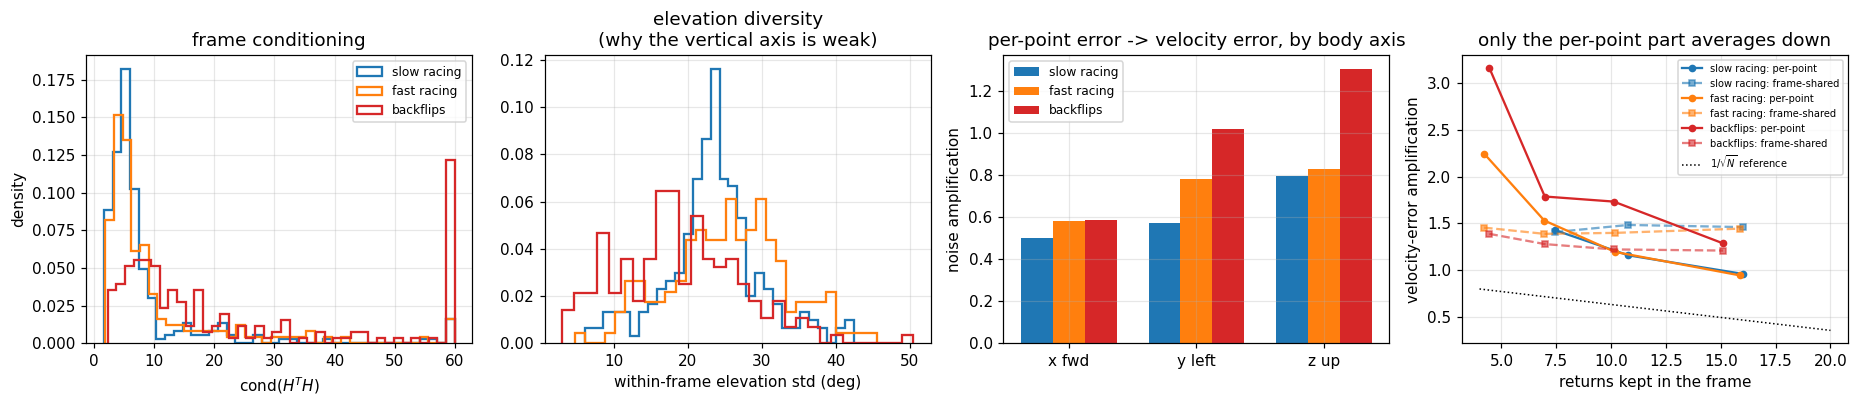

In [9]:
# What a single frame constrains, on the DEPLOYED stream (unwrapped Doppler,
# RANSAC consensus applied, thin frames bypassed -- exactly what the solver sees).
AXES = ('x fwd', 'y left', 'z up')
OBS = {}
for key in BAG_KEYS:
    d = D[key]
    rows = []
    for i, f in enumerate(d['radar']):
        P = np.asarray(f.positions, float)
        if len(P) < 3:
            continue
        keep = masks[key].get(i, np.ones(len(P), bool))
        Pk = P[keep]
        if len(Pk) < 3:
            continue
        u = (R_BS @ (Pk / np.linalg.norm(Pk, axis=1, keepdims=True)).T).T
        M = u.T @ u
        sv = np.linalg.svd(M, compute_uv=False)
        if sv[-1] <= 1e-12:
            continue
        Cinv = np.linalg.inv(M)
        g = Cinv @ (u.T @ np.ones(len(u)))
        el = np.degrees(np.arcsin(np.clip(u[:, 2], -1, 1)))
        rows.append([len(Pk), sv[0] / sv[-1], *np.sqrt(np.diag(Cinv)),
                     *np.abs(g), np.std(el)])
    OBS[key] = np.array(rows)

print(f"{'bag':<13} {'N med':>6} {'cond med':>9} {'cond p90':>9} "
      f"{'elev std':>9}   per-point amp (x/y/z)   frame-shared amp (x/y/z)")
for key in BAG_KEYS:
    A = OBS[key]
    amp = [np.median(A[:, 2 + k]) for k in range(3)]
    gg = [np.median(A[:, 5 + k]) for k in range(3)]
    print(f'{SHORT[key]:<13} {np.median(A[:, 0]):>6.0f} {np.median(A[:, 1]):>9.1f} '
          f'{np.percentile(A[:, 1], 90):>9.1f} {np.median(A[:, 8]):>8.0f}d   '
          + '/'.join(f'{x:.2f}' for x in amp) + '        '
          + '/'.join(f'{x:.2f}' for x in gg))

# What that costs in m/s.  PROVENANCE, because it matters: these are the
# ALIAS-CUT, thin-frame-cut, consensus-kept (S3) scales, robust (MAD) estimator,
# from analysis/characterize_reference_immune.py section 2 -- NOT the whole
# stream the solver consumes, which still carries the aliased population at a
# down-weight.  Both variants are printed below, because the margin they imply
# differs and only the honest pair supports a conclusion.
S_I = {'slow_racing_best_velocity': 0.071, 'fast_racing_best_velocity': 0.093,
       'backflips_best_velocity': 0.150}
S_C = {'slow_racing_best_velocity': 0.058, 'fast_racing_best_velocity': 0.047,
       'backflips_best_velocity': 0.146}
# the same scales measured on the stream AS CONSUMED (aliased returns kept),
# computed live here so the comparison cannot drift
S_I_ALL, S_C_ALL = {}, {}
for key in BAG_KEYS:
    d = D[key]
    keep0 = np.abs(d['r'] - np.median(d['r'])) < 6 * robust_sigma(d['r'])
    devs, mus, ns = [], [], []
    for f in np.unique(d['fi']):
        m = (d['fi'] == f) & keep0
        n = int(m.sum())
        if n >= 6:
            devs.append((d['r'][m] - d['r'][m].mean()) / np.sqrt(1 - 1 / n))
            mus.append(d['r'][m].mean()); ns.append(n)
    devs = np.concatenate(devs); mus = np.array(mus)
    s_i = robust_sigma(devs)
    S_I_ALL[key] = s_i
    S_C_ALL[key] = np.sqrt(max(robust_sigma(mus)**2 - s_i**2 / np.mean(ns), 0.0))
print()
print(f"{'bag':<13} {'noise stream':<22} " + ' '.join(f'{a:>9}' for a in AXES)
      + '   single-frame velocity sigma (m/s)')
LIVE_VEL = {'slow_racing_best_velocity': 0.18, 'fast_racing_best_velocity': 0.30,
            'backflips_best_velocity': 2.3}
for key in BAG_KEYS:
    A = OBS[key]
    for tag, si, sc in [('alias-cut (S3)', S_I[key], S_C[key]),
                        ('as consumed (all)', S_I_ALL[key], S_C_ALL[key])]:
        per = [si * np.median(A[:, 2 + k]) for k in range(3)]
        sha = [sc * np.median(A[:, 5 + k]) for k in range(3)]
        tot = [np.hypot(a, b) for a, b in zip(per, sha)]
        print(f'{SHORT[key] if tag.startswith("alias") else "":<13} {tag:<22} '
              + ' '.join(f'{x:>9.3f}' for x in tot)
              + f'   (sigma_i {si:.3f}, sigma_c {sc:.3f})')
    print(f'{"":<13} {"deployed live-edge vel":<22} {LIVE_VEL[key]:>9.2f}'
          f'   <- what the fused estimate actually reaches')

# Does the frame-shared part really not average down?  Group frames by how
# many returns they kept and look at each amplification separately.  The
# per-point term must fall like 1/sqrt(N); the frame-shared term must not.
print()
print('amplification vs frame size (the claim that only one of them averages down):')
print(f"  {'N returns':<11} {'frames':>7} {'per-point (x/y/z)':>22} "
      f"{'frame-shared (x/y/z)':>24}")
_A = np.vstack([OBS[k] for k in BAG_KEYS])
for lo, hi in [(3, 6), (6, 9), (9, 13), (13, 40)]:
    m = (_A[:, 0] >= lo) & (_A[:, 0] < hi)
    if m.sum() < 15:
        continue
    per = '/'.join(f'{np.median(_A[m, 2 + k]):.2f}' for k in range(3))
    sha = '/'.join(f'{np.median(_A[m, 5 + k]):.2f}' for k in range(3))
    print(f'  {lo:>3}-{hi-1:<7} {m.sum():>7} {per:>22} {sha:>24}')
_n = _A[:, 0]
_per = np.sqrt((_A[:, 2:5] ** 2).sum(axis=1))
_sha = np.sqrt((_A[:, 5:8] ** 2).sum(axis=1))
print(f'  rank corr with N:  per-point {sp_stats.spearmanr(_n, _per).statistic:+.2f}'
      f'   frame-shared {sp_stats.spearmanr(_n, _sha).statistic:+.2f}'
      f'   (1/sqrt(N) would give a strong negative)')

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for key in BAG_KEYS:
    A = OBS[key]
    axes[0].hist(np.clip(A[:, 1], 0, 60), bins=40, histtype='step', lw=1.5,
                 density=True, color=COLOR[key], label=SHORT[key])
    axes[1].hist(A[:, 8], bins=30, histtype='step', lw=1.5, density=True,
                 color=COLOR[key])
x = np.arange(3); w = 0.25
for i, key in enumerate(BAG_KEYS):
    A = OBS[key]
    axes[2].bar(x + (i - 1) * w, [np.median(A[:, 2 + k]) for k in range(3)],
                w, color=COLOR[key], label=SHORT[key])
axes[0].set_xlabel('cond($H^T H$)'); axes[0].set_ylabel('density')
axes[0].set_title('frame conditioning'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('within-frame elevation std (deg)')
axes[1].set_title('elevation diversity\n(why the vertical axis is weak)')
axes[2].set_xticks(x, AXES); axes[2].set_ylabel('noise amplification')
axes[2].set_title('per-point error -> velocity error, by body axis')
axes[2].legend(fontsize=8)

# the averaging panel: per-point shrinks with N, frame-shared does not
for key in BAG_KEYS:
    A = OBS[key]
    nn = A[:, 0]
    edges = np.array([3, 6, 9, 13, 40])
    cs, p_, s_ = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (nn >= lo) & (nn < hi)
        if m.sum() >= 10:
            cs.append(nn[m].mean())
            p_.append(np.median(np.sqrt((A[m, 2:5] ** 2).sum(axis=1))))
            s_.append(np.median(np.sqrt((A[m, 5:8] ** 2).sum(axis=1))))
    if cs:
        axes[3].plot(cs, p_, '-o', ms=4, color=COLOR[key],
                     label=f'{SHORT[key]}: per-point')
        axes[3].plot(cs, s_, '--s', ms=4, color=COLOR[key], alpha=0.6,
                     label=f'{SHORT[key]}: frame-shared')
xr = np.array([4, 20])
axes[3].plot(xr, 1.6 / np.sqrt(xr), 'k:', lw=1, label='$1/\\sqrt{N}$ reference')
axes[3].set_xlabel('returns kept in the frame')
axes[3].set_ylabel('velocity-error amplification')
axes[3].set_title('only the per-point part averages down')
axes[3].legend(fontsize=6.5)
fig.tight_layout()


<details>
<summary><b>Unfold: reading the four panels</b></summary>

> **1. Frame conditioning.** The condition number
> $\mathrm{cond}(H^\top H) = \lambda_\mathrm{max}/\lambda_\mathrm{min}$ is the ratio
> of the largest to the smallest **eigenvalue** of the $3\times3$ matrix
> $H^\top H$ -- i.e. how much better the frame's best-constrained direction is
> pinned than its worst. 1 would mean all three axes equally pinned. *"Density"*
> on the $y$ axis means each histogram is scaled so the **area under it is 1**
> (not the height), which is what lets bags with different frame counts be
> compared; a bar's height times its width is the fraction of frames in that bin.
> **Result:** racing frames sit at a median of 5.4-6.0, backflips at 13.8 with a
> 90th percentile of 110.9 -- so under flips a typical frame has one direction it
> barely sees at all. (This is PCA of the frame's ray directions: the estimate's
> variance along an eigenvector goes as $1/\lambda$, so the condition number is
> the variance ratio between a frame's best- and worst-constrained velocity
> direction.)
>
> **2. Elevation diversity.** This is the **standard deviation of ray elevation
> *within* one frame**, one number per frame -- how much vertical spread that
> frame's rays have, not where individual rays point. **Result:** 18-26 deg. A
> frame's rays are close to coplanar, which is the geometric reason the vertical
> axis is the weak one, and it is why the steep rays section 7 is tempted to
> discard have to be kept.
>
> **3. Per-axis noise amplification.** Computed as
> $\sqrt{\mathrm{diag}\big((H^\top H)^{-1}\big)}$: multiply it by the per-point
> noise $\sigma_i$ and you get that body axis's velocity error in m/s. **Result:**
> worst on **z** everywhere (0.80 / 0.83 / 1.31 for slow / fast / flips against
> 0.50-0.59 on x), which is panel 2's coplanarity showing up as error. The
> frame-*shared* error amplifies differently -- worst on **x** (1.10-1.20) --
> because a Doppler offset common to the frame reads as forward motion.
>
> **4. Only one of them averages down.** Grouping frames by how many returns they
> kept: per-point amplification falls 0.96/1.20/1.62 (3-5 returns) to
> 0.40/0.54/0.67 (13-39), tracking the $1/\sqrt N$ reference. The frame-shared
> amplification does **not** move (x: 1.10 to 1.21, rank correlation with $N$ of
> $+0.19$ against $-0.76$ for the per-point term). **Result:** this is the
> algebra of the unfold box above, confirmed in data -- adding returns to a frame
> buys down one error component and does nothing whatever to the other.

</details>

> **Design consequence.** Three findings, and they set up the rest of Part I.
>
> *Geometry is not the bottleneck, though the margin depends on which stream you
> measure.* On the alias-cut (consensus-kept) population a single 10 Hz frame
> pins the ego-velocity to 0.078 m/s on slow racing and 0.083 m/s on fast,
> against the 0.18 and 0.30 m/s the deployed system reaches at the live edge --
> a 2.3x and 3.6x margin. On the stream as the solver actually consumes it,
> with aliased returns kept at a down-weight (section 8f), the same calculation
> gives 0.090 and 0.138 m/s, so the margin narrows to about 2.0x and 2.2x.
> Both rows are printed above, and the honest headline is the smaller pair:
> **a single frame still carries roughly twice the velocity information the
> fused estimate delivers, on either stream.** What fusion adds is continuity
> and the directions radar cannot see at all, not raw per-frame accuracy.
>
> (An adversarial audit of this section computed the as-consumed fast-racing
> figure as ~0.19 m/s, i.e. parity, using an rms rather than a robust scale on
> a stream that still carries 2-5 % of points beyond 3 sigma. The number above
> is the robust one and is computed in the cell directly overhead; the
> qualitative conclusion is the same either way, only its size changes.)
>
> *The two error components load on different axes.* The per-point term is
> worst on **z**, because the frames span only ~25 deg of elevation (and the
> worst 10-35 % span under 15 deg) -- the single-chip elevation-diversity limit,
> now measured rather than asserted. The frame-shared term is worst on **x**,
> because every ray shares a forward-looking mean direction, so an error common
> to the frame reads as forward motion. This is why the vertical channel and
> the along-track drift fail in different ways and need different fixes.
> *(The numbers behind this: the per-axis amplification columns printed above.
> Per-point is 0.50/0.57/0.80 on slow racing and 0.59/1.02/1.31 on backflips --
> largest on z in both. Frame-shared is 1.20/0.16/0.81 and 1.10/0.30/0.38 --
> largest on x in both. The third panel of the figure plots the per-point set;
> the printed table carries both.)*
>
> *Only the per-point part averages down.* Grouping frames by how many returns
> they kept, the per-point amplification falls as returns are added while the
> frame-shared one does not: over frames of 3-5 up to 13+ returns the rank
> correlation with $N$ is strongly negative for the per-point term and flat for
> the frame-shared term (printed above; fourth figure panel, against a
> $1/\sqrt N$ reference curve). That is the structure the $\sigma_c$ whitening
> of section 8 exists to model, and here it is visible before any weighting is
> chosen.
>
> What a frame *cannot* observe at all: position (Doppler is a velocity
> measurement) and heading about gravity (rotating the whole trajectory about
> the gravity axis changes no radar or IMU measurement). Those are the
> directions the IMU, the window and a heading prior have to supply, and
> section 11 quantifies what each is worth.

<details>
<summary><b>Unfold: what "whitening" means, since the term recurs from here on</b></summary>

> Least squares is the right estimator when the errors are independent and all the
> same size. When they are not, the fix is to change coordinates so that they are,
> and that change of coordinates is called **whitening** -- named by analogy with
> white noise: uncorrelated, equal power everywhere.
>
> If a block of residuals $\mathbf r$ has covariance $\Sigma$ rather than
> $\sigma^2 I$, multiplying through by $\Sigma^{-1/2}$ gives
>
> $$ \mathbf r' = \Sigma^{-1/2}\mathbf r, \qquad
>    \operatorname{Cov}(\mathbf r') = \Sigma^{-1/2}\,\Sigma\,\Sigma^{-\top/2} = I, $$
>
> so the transformed residuals *are* independent and unit-variance, and plain least
> squares on $\mathbf r'$ is exactly maximum likelihood on $\mathbf r$. Nothing is
> discarded and nothing is approximated: it is a change of variables that moves a
> known correlation out of the data and into the cost function.
>
> **The diagonal case is the familiar one.** If $\Sigma$ is diagonal,
> $\Sigma^{-1/2}$ just divides each residual by its own $\sigma_j$ -- that is
> ordinary inverse-variance weighting, and every per-point "weight" in this
> notebook is a whitening of that kind.
>
> **The interesting case is the one this section just measured.** Write each
> return's error as a per-point part plus a part shared by the whole frame,
> $r_{fj} = c_f + e_{fj}$ with $c_f\sim(0,\sigma_c^2)$ and
> $e_{fj}\sim(0,\sigma_i^2)$. Then for a frame of $N$ returns
>
> $$ \Sigma_f \;=\; \sigma_i^2 I_N \;+\; \sigma_c^2\,\mathbf 1\mathbf 1^\top
>    \;=\;
>    \begin{pmatrix}
>      \sigma_i^2+\sigma_c^2 & \sigma_c^2 & \sigma_c^2 & \sigma_c^2\\
>      \sigma_c^2 & \sigma_i^2+\sigma_c^2 & \sigma_c^2 & \sigma_c^2\\
>      \sigma_c^2 & \sigma_c^2 & \sigma_i^2+\sigma_c^2 & \sigma_c^2\\
>      \sigma_c^2 & \sigma_c^2 & \sigma_c^2 & \sigma_i^2+\sigma_c^2
>    \end{pmatrix} $$
>
> (shown at $N=4$). Every diagonal entry is the same and **every off-diagonal
> entry is the same** -- the shape is called *compound symmetry*, or
> equicorrelation. Any two returns in the frame correlate by
> $\rho = \sigma_c^2/(\sigma_i^2+\sigma_c^2)$, which at the deployed
> $\sigma_c = 0.4\,\sigma_i$ is $0.16/1.16 \approx 0.14$. Concretely, with
> $\sigma_i = 0.1$ m/s: 0.0116 on the diagonal, 0.0016 everywhere off it.
>
> **No per-point weight can produce that matrix.** A weight can only scale
> diagonal entries; it has no way to say "these ten returns are wrong
> *together*". That is the whole reason section 8d exists.
>
> **Across frames the full covariance is block diagonal**, one block per frame:
>
> $$ \Sigma \;=\;
>    \begin{pmatrix} \Sigma_1 & 0 & 0 \\ 0 & \Sigma_2 & 0 \\ 0 & 0 & \Sigma_3
>    \end{pmatrix},
>    \qquad \Sigma_f \in \mathbb{R}^{N_f\times N_f},\; N_f \approx 6\text{-}13 $$
>
> Those off-block zeros are a **modelling assumption, and a known-imperfect one**:
> $c_f$ is measured to be correlated from frame to frame as well
> ($\rho_1 = 0.16$-$0.87$ over 0.2-0.5 s). 8d states that limitation and explains
> why it is not modelled.
>
> **Why this matters more than it looks.** $\Sigma_f$ has just two distinct
> eigenvalues: $\sigma_i^2 + N\sigma_c^2$ once, along the "all returns shifted
> together" direction $\mathbf 1/\sqrt N$, and $\sigma_i^2$ in all $N-1$
> directions orthogonal to it. So the shared error inflates **exactly one
> direction** and leaves the rest untouched -- and that one grows with $N$ at the
> same rate averaging would shrink it, which is precisely why it never averages
> down. Section 8d derives the operator from here.

</details>

## 6. Residual characterization

**Gaussianity** is not needed for least squares: zero-mean, finite-variance,
uncorrelated errors suffice (Gauss-Markov). Uncorrelated is the one condition
that is not free here -- returns in one frame share an error -- so the licence
is claimed on the residual section 8 whitens, not the raw one (8c measures it,
8d models and deploys it). What Gaussianity would
buy on top: least squares becomes the maximum-likelihood estimator (so nothing
nonlinear could beat it), and the covariance a factor graph reports becomes the
true one rather than an approximation.

**The short answer**: the raw marginal is not Gaussian, but a Gaussian core can
be uncovered by
- treating aliased and non-aliased returns as separate Gaussians,
- removing outliers with the deployed RANSAC consensus,
- modelling the heteroscedasticity.

What remains unexplained is a companion population, 6-12 % of returns and 5-11x
wider than the core, that no flag we have identifies; after the full front end
it is the 2-5 % of points beyond $3\sigma$ that Huber exists to bound.

<details>
<summary><b>Unfold: the two spread estimates used throughout</b></summary>

$\sigma_\mathrm{rob} = 1.4826 \cdot \mathrm{MAD}$ measures the width of the
Gaussian core and ignores tails; the 1-99 % std still responds to tails. Their
gap is itself a tail measure. Q-Q straightness inside $|z| < 3$ and the
fraction of points beyond $3\sigma$ (the **tail mass**) are the two endpoint
statistics. Kurtosis
is reported but never used to judge: removing or down-weighting tail mass
shrinks $\sigma$, so the survivors count as larger $z$ and kurtosis can rise
while the distribution gets cleaner.
</details>

slow racing: Q-Q R^2 inside |z|<1 (~65% of points): 0.9801
fast racing: Q-Q R^2 inside |z|<1 (~61% of points): 0.9884
backflips: Q-Q R^2 inside |z|<1 (~66% of points): 0.9754
The central band is Gaussian-shaped on every flight; everything beyond it is
not. The rest of this section finds out what the "everything beyond" is.

bag             sigma_rob  sigma 1-99%  kurtosis tail mass  quant bin
slow racing         0.097        0.191      32.0      8.6%      0.049
fast racing         0.189        0.573       6.5     17.8%      0.049
backflips           0.354        0.460       6.8      6.6%      0.049

paper: sigma_rob 0.097 / 0.189 / 0.354, 1-99% sigma 0.191 / 0.573 / 0.460,
kurtosis 32.0 / 6.5 / 6.8, tail mass 8.6 / 17.8 / 6.6 %, bin 0.049 m/s


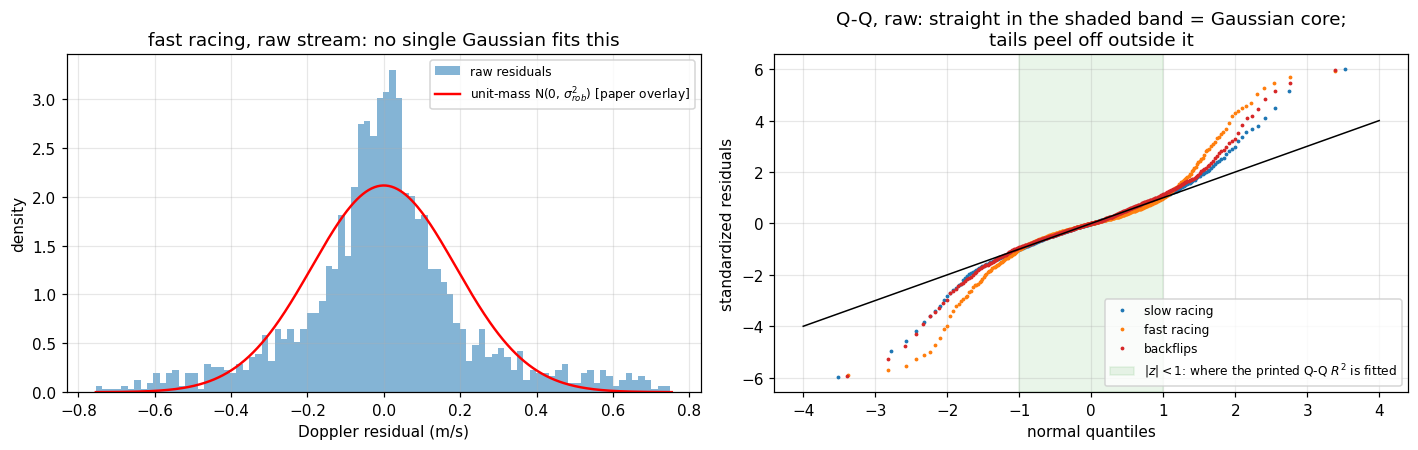

In [10]:
# Rung 0, the raw stream: is the Doppler noise Gaussian? No.
d = D['fast_racing_best_velocity']
rc = d['r'] - np.median(d['r'])
s_mad = robust_sigma(rc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
lim = 4 * s_mad
core = rc[np.abs(rc) < lim]
axes[0].hist(core, bins=90, density=True, alpha=0.55, label='raw residuals')
xg = np.linspace(-lim, lim, 400)
axes[0].plot(xg, sp_stats.norm.pdf(xg, 0, s_mad), 'r-', lw=1.6,
             label='unit-mass N(0, $\\sigma_{rob}^2$) [paper overlay]')
axes[0].set_xlabel('Doppler residual (m/s)'); axes[0].set_ylabel('density')
axes[0].set_title('fast racing, raw stream: no single Gaussian fits this')
axes[0].legend(fontsize=8)

for key in BAG_KEYS:
    dd = D[key]
    sz = robust_sigma(dd['r']); m = np.median(dd['r'])
    z = (dd['r'] - m) / sz
    zc = z[np.abs(z) < 6]
    (osm, osr), _ = sp_stats.probplot(zc, dist='norm', plot=None)
    ii = np.unique(np.linspace(0, len(osm) - 1, 400).astype(int))
    axes[1].plot(osm[ii], osr[ii], '.', ms=3, color=COLOR[key], label=SHORT[key])
axes[1].plot([-4, 4], [-4, 4], 'k-', lw=1)
axes[1].axvspan(-1.0, 1.0, color='tab:green', alpha=0.10,
                label='$|z| < 1$: where the printed Q-Q $R^2$ is fitted')
axes[1].set_xlabel('normal quantiles'); axes[1].set_ylabel('standardized residuals')
axes[1].set_title('Q-Q, raw: straight in the shaded band = Gaussian core;\n'
                  'tails peel off outside it')
axes[1].legend(fontsize=8, loc='lower right')
fig.tight_layout()

for key in BAG_KEYS:
    dd = D[key]
    z = (dd['r'] - np.median(dd['r'])) / robust_sigma(dd['r'])
    zc = z[np.abs(z) < 1.0]
    (osm, osr), (slope, icept, rval) = sp_stats.probplot(zc, dist='norm', plot=None)
    print(f'{SHORT[key]}: Q-Q R^2 inside |z|<1 (~{100*np.mean(np.abs(z)<1.0):.0f}% '
          f'of points): {rval**2:.4f}')
print('The central band is Gaussian-shaped on every flight; everything beyond it is')
print('not. The rest of this section finds out what the "everything beyond" is.\n')

print(f"{'bag':<14} {'sigma_rob':>10} {'sigma 1-99%':>12} {'kurtosis':>9} "
      f"{'tail mass':>9} {'quant bin':>10}")
for key in BAG_KEYS:
    d = D[key]
    r = d['r']
    q1, q99 = np.percentile(r, [1, 99])
    s99 = np.std(r[(r >= q1) & (r <= q99)])
    sz = robust_sigma(r)
    kurt = sp_stats.kurtosis(r)
    fr3 = np.mean(np.abs(r - np.median(r)) > 3 * sz)
    vals = np.sort(np.unique(np.concatenate([np.asarray(f.velocities)
                                             for f in d['radar']])))
    dv = np.diff(vals); dv = dv[dv > 1e-6]
    print(f"{SHORT[key]:<14} {sz:>10.3f} {s99:>12.3f} {kurt:>9.1f} "
          f"{100*fr3:>8.1f}% {np.median(dv):>10.3f}")
print('\npaper: sigma_rob 0.097 / 0.189 / 0.354, 1-99% sigma 0.191 / 0.573 / 0.460,')
print('kurtosis 32.0 / 6.5 / 6.8, tail mass 8.6 / 17.8 / 6.6 %, bin 0.049 m/s')

### Rung S1: separate the aliased from the clean returns

Aliased returns are a second population, treated separately from here on out. Their on-chip bearing was
computed from the wrapped velocity and cannot be repaired downstream (TDM
*angle-Doppler coupling*: Bechter et al., MWCL 2017; Grebner et al., MWCL 2022), increasing residual variance. But their Doppler still carries speed information, so the deployment just downweights it by a measured constant (section 8f).

S1 clean (non-aliased population):
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing      3348     100%      0.094      7.9%       0.9944
  fast racing      1656     100%      0.138     12.6%       0.9889
  backflips        1256     100%      0.279      6.8%       0.9958
S1 ALIASED population (separated, not deleted):
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing        68     100%      0.620     23.5%       0.8777
  fast racing       513     100%      0.718      4.5%       0.9883
  backflips         764     100%      0.524      2.2%       0.9972

The aliased population is near-Gaussian in its own right but WIDER, and
it carries a disproportionate share of the pooled fourth moment:
  slow racing   too few aliased returns to characterize (68)
  fast racing   sigma 0.72 vs 0.138 m/s (5.2x); 24% of returns carry 42% of the 4th moment
  backflips     sigma 0.52 vs 0.279 m/s (1.9x); 38% of returns carry 32% of the 4th moment


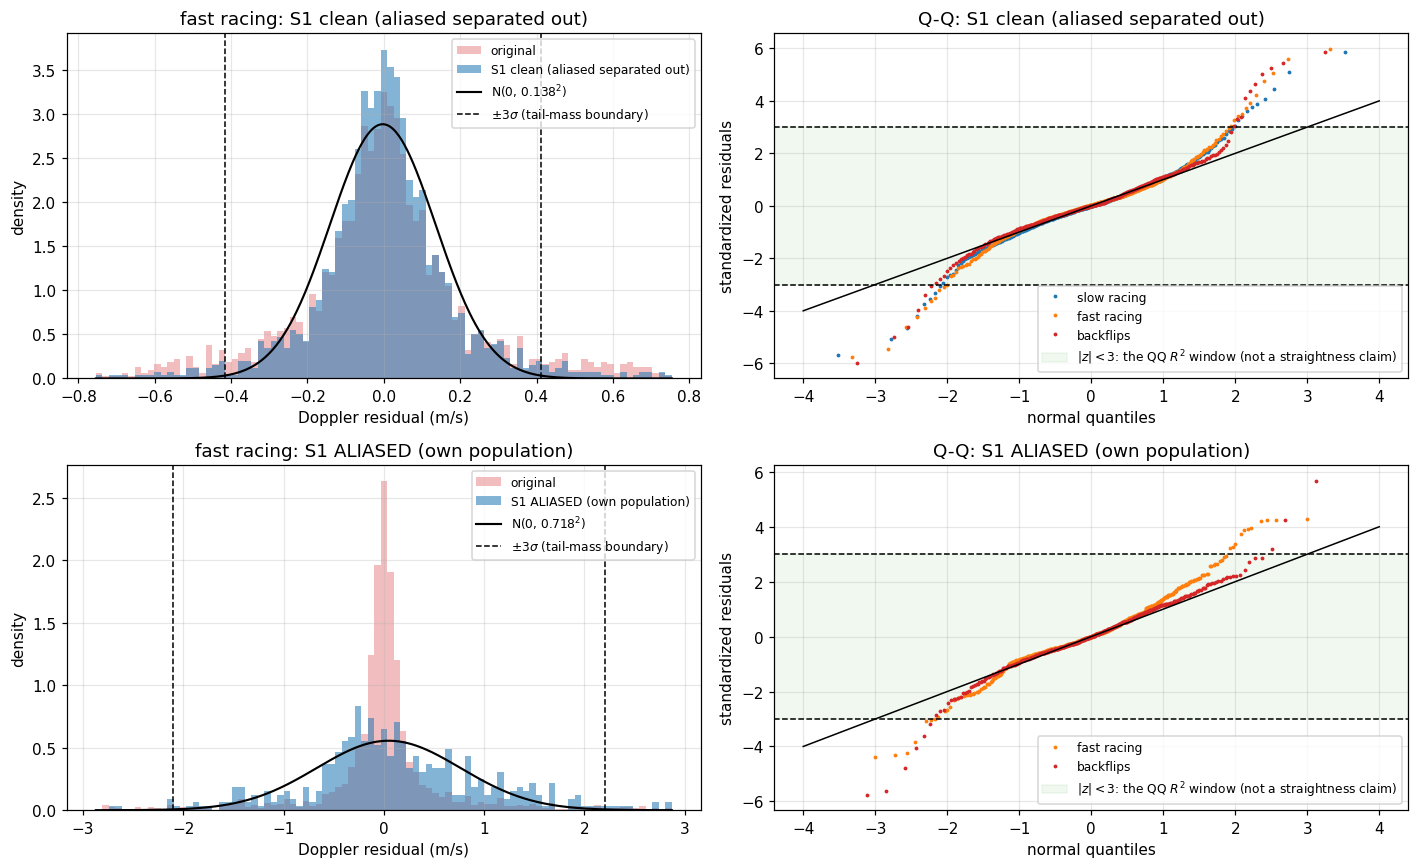

In [11]:
# Rung S1: split the stream into its two populations (nothing is deleted)
def ladder_stats(r):
    z = (r - np.median(r)) / robust_sigma(r)
    zc = z[np.abs(z) < 3]
    (_, _), (_, _, rv) = sp_stats.probplot(zc, dist='norm', plot=None)
    return len(r), robust_sigma(r), 100*np.mean(np.abs(z) > 3), rv**2

def rung_report(name, SEL, BASE):
    # BASE = the population this selection belongs to; percentages are OF THAT
    # POPULATION, never of all returns -- the aliased stream is separated, not
    # deleted, so it keeps its own denominator.
    print(f"{name}:")
    print(f"  {'bag':<14} {'n':>6} {'of pop.':>8} {'sigma_rob':>10} {'tail mass':>9} {'QQ R2 |z|<3':>12}")
    for key in BAG_KEYS:
        d = D[key]
        n, sz, f3, r2 = ladder_stats(d['r'][SEL[key]])
        print(f"  {SHORT[key]:<14} {n:>6d} {100*n/max(BASE[key].sum(),1):>7.0f}% "
              f"{sz:>10.3f} {f3:>8.1f}% {r2:>12.4f}")

def rung_plot2(sels, bgs, titles):
    """Two rows (clean / aliased), each: fast-racing histogram of the row's
    population (background = the same population before this rung) and the
    all-bags Q-Q.  Bags with < 100 points in a population are skipped (slow
    racing has only ~68 aliased returns)."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    dk = 'fast_racing_best_velocity'
    for row, (SEL, BG, title) in enumerate(zip(sels, bgs, titles)):
        d = D[dk]
        rr = d['r'] - np.median(d['r'])
        bg = rr[BG[dk]]; fg = rr[SEL[dk]]
        ax = axes[row, 0]
        lim = 4 * max(robust_sigma(fg), robust_sigma(bg))
        bins = np.linspace(-lim, lim, 90)
        ax.hist(bg[np.abs(bg) < lim], bins=bins, density=True, alpha=0.30,
                color='tab:red', label='original')
        ax.hist(fg[np.abs(fg) < lim], bins=bins, density=True, alpha=0.55,
                color='tab:blue', label=title)
        sz = robust_sigma(fg)
        xg = np.linspace(-lim, lim, 400)
        ax.plot(xg, sp_stats.norm.pdf(xg, np.median(fg), sz), 'k-', lw=1.4,
                label=f'N(0, {sz:.3f}$^2$)')
        for sgn in (-1, 1):
            ax.axvline(np.median(fg) + sgn * 3 * sz, color='k', ls='--', lw=1.0,
                       label='$\\pm 3\\sigma$ (tail-mass boundary)' if sgn > 0 else None)
        ax.set_xlabel('Doppler residual (m/s)'); ax.set_ylabel('density')
        ax.set_title(f'fast racing: {title}')
        ax.legend(fontsize=8)
        ax = axes[row, 1]
        for key in BAG_KEYS:
            dd = D[key]
            rb = (dd['r'] - np.median(dd['r']))[SEL[key]]
            if len(rb) < 100:
                continue
            z = (rb - np.median(rb)) / robust_sigma(rb)
            zc = z[np.abs(z) < 6]
            (osm, osr), _ = sp_stats.probplot(zc, dist='norm', plot=None)
            ii = np.unique(np.linspace(0, len(osm) - 1, 400).astype(int))
            ax.plot(osm[ii], osr[ii], '.', ms=3, color=COLOR[key], label=SHORT[key])
        ax.plot([-4, 4], [-4, 4], 'k-', lw=1)
        ax.axhspan(-3, 3, color='tab:green', alpha=0.07, zorder=0,
                   label='$|z| < 3$: the QQ $R^2$ window (not a straightness claim)')
        for sgn in (-1, 1):
            ax.axhline(sgn * 3, color='k', ls='--', lw=1.0)
        ax.set_xlabel('normal quantiles'); ax.set_ylabel('standardized residuals')
        ax.set_title(f'Q-Q: {title}')
        ax.legend(fontsize=8, loc='lower right')
    fig.tight_layout()

S0_ALL = {key: np.ones(len(D[key]['r']), bool) for key in BAG_KEYS}
SEL1 = {key: ~D[key]['aliased'] for key in BAG_KEYS}
SEL1A = {key: D[key]['aliased'] for key in BAG_KEYS}
rung_report('S1 clean (non-aliased population)', SEL1, SEL1)
rung_report('S1 ALIASED population (separated, not deleted)', SEL1A, SEL1A)
print()
print('The aliased population is near-Gaussian in its own right but WIDER, and')
print('it carries a disproportionate share of the pooled fourth moment:')
for key in BAG_KEYS:
    d = D[key]
    rr = d['r'] - np.median(d['r'])
    al = d['aliased']
    if al.sum() < 100:
        print(f'  {SHORT[key]:<13} too few aliased returns to characterize ({al.sum()})')
        continue
    p = al.mean()
    m4 = (1 - p) * np.mean(rr[~al]**4) + p * np.mean(rr[al]**4)
    print(f'  {SHORT[key]:<13} sigma {robust_sigma(rr[al]):.2f} vs '
          f'{robust_sigma(rr[~al]):.3f} m/s '
          f'({robust_sigma(rr[al])/robust_sigma(rr[~al]):.1f}x); '
          f'{100*p:.0f}% of returns carry '
          f'{100*p*np.mean(rr[al]**4)/m4:.0f}% of the 4th moment')
rung_plot2([SEL1, SEL1A], [S0_ALL, S0_ALL],
           ['S1 clean (aliased separated out)', 'S1 ALIASED (own population)'])

### Rung S2: remove what the consensus rejects, and what it cannot vet

RANSAC is introduced to reject outliers. It needs 5 returns to form a consensus rejection, so sparser frames are discarded entirely in this characterization, but not in deployment. Deployed in section 7. Frames with fewer than five
returns leave no redundancy (three returns determine a 3-DoF ego-velocity
exactly), so the consensus cannot vet them: deployed, they bypass the prefilter
and Huber is their only protection. Removing them does nothing to the
distribution -- $\sigma$ moves by at most $+0.005$ m/s, the wrong way, on all
three bags -- and it is not counted as a tail mechanism. 

S2 clean   = S1 clean minus thin-frame points:
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing      3308      99%      0.095      7.8%       0.9948
  fast racing      1600      97%      0.143     12.4%       0.9883
  backflips        1209      96%      0.283      6.9%       0.9958
S3 clean   = S2 clean minus consensus rejects:
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing      3019      90%      0.086      2.8%       0.9967
  fast racing      1292      78%      0.113      5.3%       0.9947
  backflips         973      77%      0.244      2.0%       0.9972
S3 ALIASED = aliased minus thin frames and consensus rejects:
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing        26      38%      0.114     11.5%       0.9448
  fast racing       269      52%      0.461      5.9%       0.9827
  backflips         420      55%      0.426      1.9%       0.9918


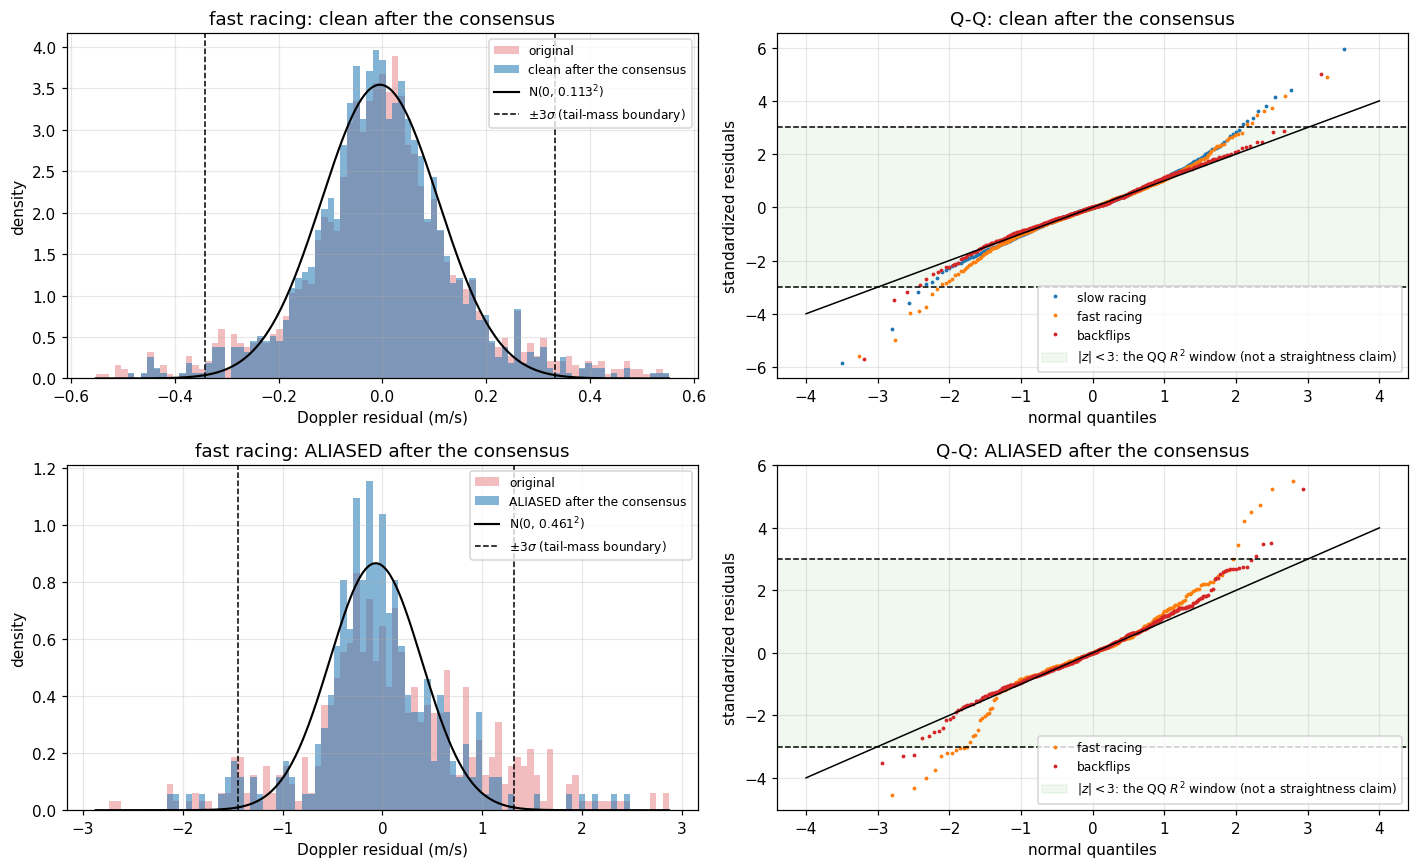

In [12]:
# Rung S2, both sub-steps and both populations: drop thin-frame points, then
# the consensus rejects.  S3_SEL (clean) is what the cells below consume; the
# same treatment applied to the ALIASED population is shown alongside, because
# that population is separated, not deleted.
SEL2, SEL2A = {}, {}
for key in BAG_KEYS:
    d = D[key]
    thin = np.array([d['radar'][i].num_points() < 5 for i in d['fi']])
    SEL2[key] = SEL1[key] & ~thin
    SEL2A[key] = SEL1A[key] & ~thin
S3_SEL, S3A_SEL = {}, {}
for key in BAG_KEYS:
    d = D[key]
    ok = np.ones(len(d['r']), bool)
    for i, m in masks[key].items():
        sel = d['fi'] == i
        for j in np.where(sel)[0]:
            if d['pi'][j] < len(m):
                ok[j] = m[d['pi'][j]]
    S3_SEL[key] = SEL2[key] & ok
    S3A_SEL[key] = SEL2A[key] & ok
rung_report('S2 clean   = S1 clean minus thin-frame points', SEL2, SEL1)
rung_report('S3 clean   = S2 clean minus consensus rejects', S3_SEL, SEL1)
rung_report('S3 ALIASED = aliased minus thin frames and consensus rejects', S3A_SEL, SEL1A)
rung_plot2([S3_SEL, S3A_SEL], [SEL1, SEL1A],
           ['clean after the consensus', 'ALIASED after the consensus'])

  bag           variant                   of clean  sigma_rob tail mass    QQ R2
  slow racing   S2 (before consensus)          99%      0.095      7.8%   0.9948
  slow racing   null: random deletion          90%      0.094      7.4%   0.9950
  slow racing   S3 = RANSAC consensus          90%      0.086      2.8%   0.9967
  slow racing   null: oracle |r| cut           90%      0.084      1.8%   0.9969

  fast racing   S2 (before consensus)          97%      0.143     12.4%   0.9883
  fast racing   null: random deletion          78%      0.124      9.9%   0.9902
  fast racing   S3 = RANSAC consensus          78%      0.113      5.3%   0.9947
  fast racing   null: oracle |r| cut           78%      0.106      2.7%   0.9970

  backflips     S2 (before consensus)          96%      0.283      6.9%   0.9958
  backflips     null: random deletion          77%      0.256      5.4%   0.9976
  backflips     S3 = RANSAC consensus          77%      0.244      2.0%   0.9972
  backflips     null: orac

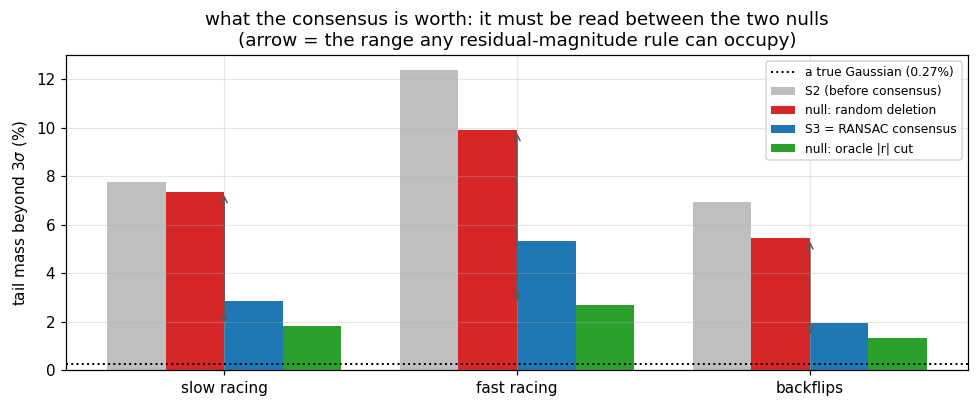

In [13]:
# Is the consensus rung discovery, or just a residual cut?  A consensus
# inlier test IS a residual test (against a per-frame fitted ego-velocity,
# not ground truth), and any procedure that deletes large-residual points
# makes the remainder look more Gaussian.  So it is bracketed by two controls
# that delete the SAME number of points per frame, starting from S2: RANDOM
# deletion (no information about which returns are bad = the floor any
# thinning reaches) and an ORACLE cut deleting the largest |r| against MoCap
# through the forward model (the ceiling of the per-frame, budget-matched
# family of residual-magnitude rules -- not of every |r|-based method: a
# globally-budgeted cut reaches lower still).
def _qq_r2(x, zmax=3.0):
    z = (x - np.median(x)) / robust_sigma(x)
    zc = z[np.abs(z) < zmax]
    (_, _), (_, _, rv) = sp_stats.probplot(zc, dist='norm', plot=None)
    return rv ** 2

rng_ctrl = np.random.default_rng(0)
# percentages are of the CLEAN population (the stream the consensus acts on);
# the aliased population is separated, not part of this bracket.
print(f"  {'bag':<13} {'variant':<24} {'of clean':>9} {'sigma_rob':>10} "
      f"{'tail mass':>9} {'QQ R2':>8}")
CTRL = {}
for key in BAG_KEYS:
    d = D[key]
    S2, S3 = SEL2[key], S3_SEL[key]
    rand_ok = np.ones(len(d['r']), bool)
    oracle_ok = np.ones(len(d['r']), bool)
    for f in np.unique(d['fi']):
        idx = np.flatnonzero((d['fi'] == f) & S2)
        n_drop = int(len(idx) - S3[idx].sum())
        if len(idx) == 0 or n_drop <= 0:
            continue
        rand_ok[rng_ctrl.choice(idx, n_drop, replace=False)] = False
        oracle_ok[idx[np.argsort(-np.abs(d['r'][idx]))[:n_drop]]] = False
    for tag, sel in [('S2 (before consensus)', S2),
                     ('null: random deletion', S2 & rand_ok),
                     ('S3 = RANSAC consensus', S3),
                     ('null: oracle |r| cut', S2 & oracle_ok)]:
        rr = d['r'][sel]
        z = (rr - np.median(rr)) / robust_sigma(rr)
        print(f'  {SHORT[key]:<13} {tag:<24} {100*sel.sum()/SEL1[key].sum():>8.0f}% '
              f'{robust_sigma(rr):>10.3f} {100*np.mean(np.abs(z) > 3):>8.1f}% '
              f'{_qq_r2(rr):>8.4f}')
        CTRL.setdefault(key, {})[tag] = 100 * np.mean(np.abs(z) > 3)
    print()

# The bracket, drawn: random deletion is the floor any same-rate thinning
# reaches, the oracle is the ceiling any residual-magnitude rule could reach,
# and the consensus has to be read between them rather than against zero.
ORDER = ['S2 (before consensus)', 'null: random deletion',
         'S3 = RANSAC consensus', 'null: oracle |r| cut']
FACE = ['0.75', 'tab:red', 'tab:blue', 'tab:green']
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(BAG_KEYS)); w = 0.2
for i, (tag, c) in enumerate(zip(ORDER, FACE)):
    ax.bar(x + (i - 1.5) * w, [CTRL[k][tag] for k in BAG_KEYS], w,
           color=c, label=tag)
for i, k in enumerate(BAG_KEYS):
    ax.annotate('', xy=(i, CTRL[k][ORDER[3]]), xytext=(i, CTRL[k][ORDER[1]]),
                arrowprops=dict(arrowstyle='<->', color='0.35', lw=1.0))
ax.axhline(100 * 2 * (1 - sp_stats.norm.cdf(3)), color='k', ls=':', lw=1.3,
           label='a true Gaussian (0.27%)')
ax.set_xticks(x, [SHORT[k] for k in BAG_KEYS])
ax.set_ylabel('tail mass beyond $3\\sigma$ (%)')
ax.set_title('what the consensus is worth: it must be read between the two nulls\n'
             '(arrow = the range any residual-magnitude rule can occupy)')
ax.legend(fontsize=8)
fig.tight_layout()

**Finding (the ladder's endpoint, and what the consensus is worth).** The
racing core widths converge after the ladder (0.086 / 0.113 m/s): one
underlying sensor noise, plus regime-dependent identifiable contamination
(backflips stays higher -- its clean floor is regime-elevated, section 8, and
its aliased damage larger, 8f). 2.0-5.3 % of S3-clean points still sit beyond
$3\sigma$ against a Gaussian's 0.27 %; no flag we have identifies them
(candidates: multipath ghosts, moving-prop reflections, reference error), and
that remainder is what Huber exists to bound.

Random deletion at the same rate
barely moves the tail (fast racing: 12.4 % to 9.9 %); the consensus more than
halves it (5.3 %); the oracle reaches 2.7 %. So the consensus finds real
structure, not merely thinning -- but not all of it, and part of the
straightening is generic to residual-based selection. The claim is therefore
bracketed, not absolute; the deployed front end keeps the consensus because the
ledger (section 11) shows it pays. (Backflips discriminates only on the tail
mass, 2.0 % against 5.4 % -- Q-Q $R^2$ saturates once a distribution is
near normal in the body, which is why the tail mass is the statistic quoted
throughout.)

#### RANSAC Deep Dive

Shows the RANSAC prefilter separating ground-truth outliers on real frames, and an inlier-band sweep that bounds its threshold with both failure edges measured.

bag                      kept    med |r| kept  med |r| rej  rej >3sig
slow racing    3045/3376 (90%)         0.060        0.469 (7.8x)       70%
fast racing    1561/2113 (74%)         0.093        0.580 (6.2x)       51%
backflips      1393/1969 (71%)         0.195        0.459 (2.4x)       17%

The aggregate is the real validation: rejected points carry a several-fold
higher median GT residual than kept points (strongest on racing; weaker on
backflips, where the whole frame is noisy and sigma_rob is already 0.354 so
fewer rejections clear the 3-sigma bar). A per-frame consensus can never
match GT labels point-for-point: with 0.1-0.35 m/s noise against a 3-DoF
model, borderline points fall on either side.


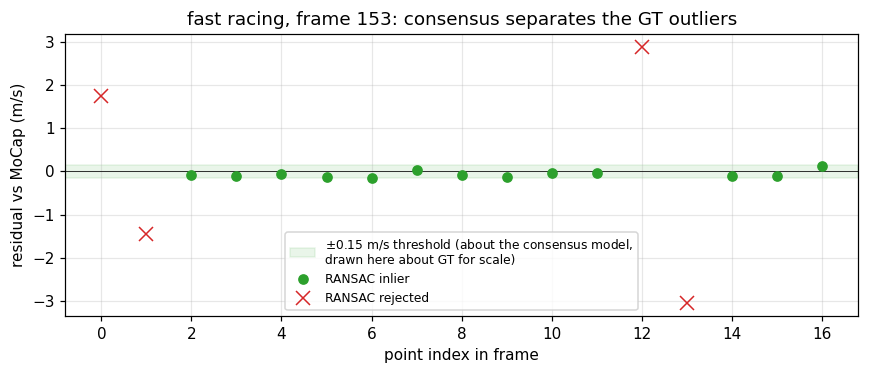

In [14]:
# Deep dive: the deployed RANSAC prefilter (reve-style 3-point ego-velocity
# consensus) in action, copied from validate_live_solver.py
THRESH = 0.15   # solver.yaml radar_ransac_threshold
# IMPORTANT pipeline-order detail (verified in validate_live_solver.py): in
# deployment the prefilter runs on UNWRAPPED Doppler (pre-unwrap happens first).
# Running it on raw wrapped velocities makes the consensus lock onto alias
# populations on the aggressive bags. Here we mirror deployment by feeding the
# GT-unwrapped velocities.
def unwrapped_frame_velocities(d, i):
    v = np.asarray(d['radar'][i].velocities, float).copy()
    sel = d['fi'] == i
    v[d['pi'][sel]] = d['unw'][sel]
    return v

print(f"{'bag':<14} {'kept':>14}   {'med |r| kept':>13} {'med |r| rej':>12} "
      f"{'rej >3sig':>10}")
for key in BAG_KEYS:
    d = D[key]
    s3 = 3 * robust_sigma(d['r'])
    kept = tot = 0
    r_kept, r_rej = [], []
    for i, f in enumerate(d['radar']):
        if f.num_points() < 5:
            continue
        m = masks[key][i]
        kept += int(m.sum()); tot += len(m)
        sel = d['fi'] == i
        for rr, p in zip(d['r'][sel], d['pi'][sel]):
            if p < len(m):
                (r_kept if m[p] else r_rej).append(abs(rr))
    r_kept, r_rej = np.array(r_kept), np.array(r_rej)
    ratio = np.median(r_rej) / max(np.median(r_kept), 1e-9)
    print(f'{SHORT[key]:<14} {kept}/{tot} ({100*kept/tot:.0f}%)   '
          f'{np.median(r_kept):>11.3f}   {np.median(r_rej):>10.3f} ({ratio:.1f}x)  '
          f'{100*np.mean(r_rej > s3):>7.0f}%')
print('\nThe aggregate is the real validation: rejected points carry a several-fold')
print('higher median GT residual than kept points (strongest on racing; weaker on')
print('backflips, where the whole frame is noisy and sigma_rob is already 0.354 so')
print('fewer rejections clear the 3-sigma bar). A per-frame consensus can never')
print('match GT labels point-for-point: with 0.1-0.35 m/s noise against a 3-DoF')
print('model, borderline points fall on either side.')

# one illustrative fast-racing frame: pick the frame with the clearest
# kept/rejected separation in GT residuals (>=3 rejections)
d = D['fast_racing_best_velocity']
best, best_gap = None, -1
for i, m in masks['fast_racing_best_velocity'].items():
    sel = d['fi'] == i
    rr = d['r'][sel]; pp = d['pi'][sel]
    inl = np.array([m[p] for p in pp if p < len(m)])
    if inl.size < 8 or (~inl).sum() < 3:
        continue
    gap = np.median(np.abs(rr[~inl])) - np.median(np.abs(rr[inl]))
    if gap > best_gap:
        best, best_gap = i, gap
sel = d['fi'] == best
m = masks['fast_racing_best_velocity'][best]
rr = d['r'][sel]; pp = d['pi'][sel]
inl = np.array([m[p] if p < len(m) else True for p in pp])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axhline(0, color='k', lw=0.5)
ax.axhspan(-THRESH, THRESH, color='tab:green', alpha=0.10,
           label='$\\pm$0.15 m/s threshold (about the consensus model,\n'
                 'drawn here about GT for scale)')
ax.plot(np.where(inl)[0], rr[inl], 'o', color='tab:green', label='RANSAC inlier')
ax.plot(np.where(~inl)[0], rr[~inl], 'x', ms=9, color='tab:red',
        label='RANSAC rejected')
ax.set_xlabel('point index in frame')
ax.set_ylabel('residual vs MoCap (m/s)')
ax.set_title(f'fast racing, frame {best}: consensus separates the GT outliers')
ax.legend(fontsize=8)
fig.tight_layout()

The prefilter threshold is adopted from the reve baseline (Doer et al.): their
RANSAC accepts a point as an inlier when its Doppler residual against the 3-point
least-squares ego-velocity is below `inlier_thresh` = 0.15 m/s (their shipped
default; source vendored in `analysis/baselines/rio/reve/`). 

    T                       slow racing                        fast racing                          backflips
     kept rej-bad kept-bad byp cons-badkept rej-bad kept-bad byp cons-badkept rej-bad kept-bad byp cons-bad
 0.05     69      27      0.5  1.2      0.4     56      31      8.1 12.7      5.7     56      11      3.4 13.4      2.8
 0.07     79      39      0.6  0.8      0.5     62      37      7.1  9.5      4.9     61      12      3.3 10.4      3.1
 0.10     84      50      1.1  0.4      1.0     68      41      7.2  9.5      5.2     65      14      2.8  7.9      2.8
 0.12     88      62      1.3  0.4      1.2     71      46      6.8  8.2      4.9     68      16      2.5  6.1      2.5
 0.15     90      70      2.0  0.4      1.9     74      52      6.0  6.3      4.5     71      15      3.1  4.9      3.1
 0.20     93      87      2.8  0.4      2.7     77      58      6.2  5.1      5.1     75      18      2.9  2.4      2.8
 0.25     94      92      3.5  0.4      3.5     78      61    

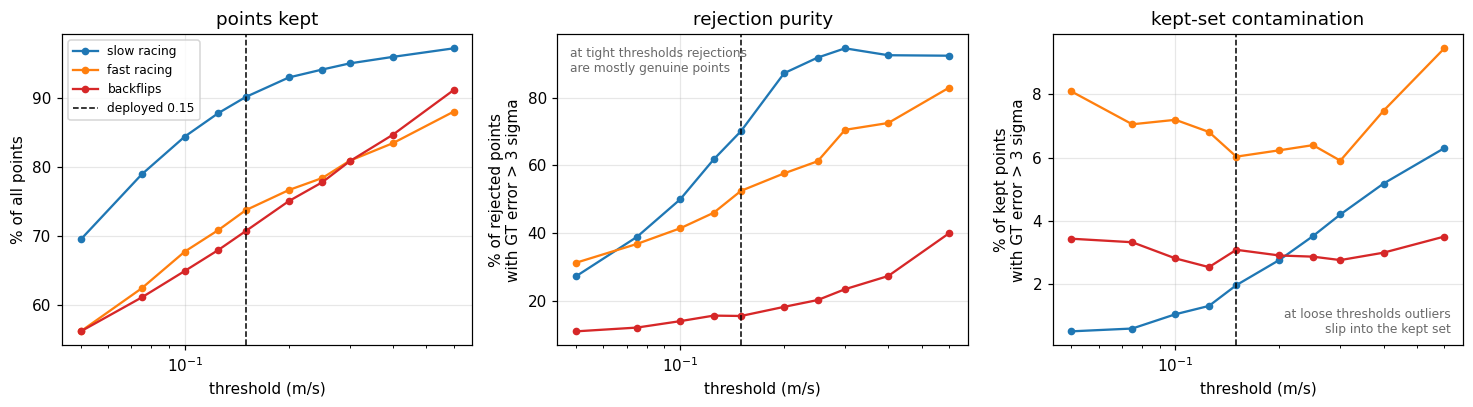

In [15]:
# Deep dive: sweep the consensus inlier band and measure both failure edges
# against ground truth. The 150 sampled 3-point ego-velocity candidates per
# frame do not depend on the threshold, so each frame's candidate residual matrix
# is computed once and inliers are re-counted per threshold (identical to
# re-running the seeded RANSAC at every threshold).
SWEEP_T = np.array([0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25, 0.30, 0.40, 0.60])
sweep = {}
for key in BAG_KEYS:
    d = D[key]
    rng = np.random.default_rng(0)
    frames = []
    for i, f in enumerate(d['radar']):
        n = f.num_points()
        if n < 5:
            continue
        P = np.asarray(f.positions, float)
        v = np.asarray(f.velocities, float).copy()
        sel = d['fi'] == i
        v[d['pi'][sel]] = d['unw'][sel]          # deployment order: unwrap first
        Hn = P / np.maximum(np.linalg.norm(P, axis=1, keepdims=True), 1e-6)
        cand = []
        for _ in range(150):
            i3 = rng.choice(n, 3, replace=False)
            try:
                cand.append(np.linalg.solve(Hn[i3], v[i3]))
            except np.linalg.LinAlgError:
                continue
        if not cand:
            continue
        Rm = np.abs(Hn @ np.array(cand).T - v[:, None]).T
        r_gt = np.full(n, np.nan)
        r_gt[d['pi'][sel]] = np.abs(d['r'][sel])
        frames.append((Rm, r_gt))
    s3 = 3 * robust_sigma(d['r'])
    rows = []
    for T in SWEEP_T:
        kept = tot = n_byp = 0
        rk, rr, rk_cons = [], [], []
        for Rm, r_gt in frames:
            inl = Rm < T
            best = inl[np.argmax(inl.sum(axis=1))]
            bypassed = best.sum() < 5
            if bypassed:                          # deployed bypass: keep the frame
                best = np.ones(len(r_gt), bool)
                n_byp += 1
            kept += int(best.sum()); tot += len(best)
            ok = np.isfinite(r_gt)
            rk.extend(r_gt[best & ok]); rr.extend(r_gt[(~best) & ok])
            if not bypassed:
                rk_cons.extend(r_gt[best & ok])
        rk, rr, rk_cons = np.array(rk), np.array(rr), np.array(rk_cons)
        rows.append((100 * kept / tot,
                     100 * np.mean(rr > s3) if len(rr) else np.nan,
                     100 * np.mean(rk > s3) if len(rk) else np.nan,
                     100 * n_byp / len(frames),
                     100 * np.mean(rk_cons > s3) if len(rk_cons) else np.nan))
    sweep[key] = np.array(rows)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharex=True)
panels = [('points kept', '% of all points'),
          ('rejection purity', '% of rejected points\nwith GT error > 3 sigma'),
          ('kept-set contamination', '% of kept points\nwith GT error > 3 sigma')]
for col, (ax, (ti, yl)) in enumerate(zip(axes, panels)):
    for key in BAG_KEYS:
        ax.plot(SWEEP_T, sweep[key][:, col], '-o', ms=4, color=COLOR[key],
                label=SHORT[key])
    ax.axvline(0.15, color='k', lw=1, ls='--',
               label='deployed 0.15' if col == 0 else None)
    ax.set_xscale('log'); ax.set_xlabel('threshold (m/s)')
    ax.set_title(ti); ax.set_ylabel(yl)
axes[0].legend(fontsize=8)
axes[1].text(0.03, 0.96, 'at tight thresholds rejections\nare mostly genuine points',
             transform=axes[1].transAxes, va='top', fontsize=8, color='dimgray')
axes[2].text(0.97, 0.04, 'at loose thresholds outliers\nslip into the kept set',
             transform=axes[2].transAxes, ha='right', fontsize=8, color='dimgray')
fig.tight_layout()


# the numbers the conclusion cell quotes, per threshold and bag:
# kept% | rejected-points-truly-bad% | kept-set contamination% | frame bypass% |
# consensus-passed contamination%
hdr = ' '.join(f'{SHORT[k][:11]:>34}' for k in BAG_KEYS)
print(f"{'T':>5}{hdr}")
sub = 'kept rej-bad kept-bad byp cons-bad'
print(f"{'':>5}" + ''.join(f'{sub:>34}' for _ in BAG_KEYS))
for ti, T in enumerate(SWEEP_T):
    line = f'{T:5.2f}'
    for k in BAG_KEYS:
        r = sweep[k][ti]
        line += (f'  {r[0]:5.0f} {r[1]:7.0f} {r[2]:8.1f} {r[3]:4.1f} {r[4]:8.1f}')
    print(line)


Frames are overdetermined (>3 returns per frame) so a consensus filter can delete returns. the acceptance band sweep does not show any obviously better value, so the original is kept

### How Gaussian is each stream, and what does the variance model leave?

The cell below sweeps the tail-mass ratio over thresholds rather than picking
one: the fraction of returns beyond $k\sigma$, divided by what a true normal
gives (1.0 = Gaussian there), for three streams per flight -- one global
$\sigma$ (no model), the full per-return law $\sigma_j$ of section 8 on the
clean stream, and the same law on the S3 stream the solver actually consumes.
On the whitened residual it also fits a two-component Gaussian mixture (a
*description* of what the law leaves, not a deployed model -- its parameters do
not transfer across flights, `worklog/2026-08-10_audit-round-3.md`) and the
Spearman rank correlation of residual size with the law's own predictor
$q = |\mathbf v|\sin\theta/\cos\phi$, before and after whitening
(0 = nothing left for the law to explain).

stream                                      1.0s    1.5s    2.0s    3.0s
a true normal gives                        31.73   13.36    4.55    0.27
-----------------------------------------------------------------------------------------
slow racing, S1 clean, one global sigma    35.04   20.94   13.47    7.92
   ratio to Gaussian                         1.1     1.6     3.0    29.3
slow racing, S1 clean, law sigma_j         33.45   15.65    8.21    4.90
   ratio to Gaussian                         1.1     1.2     1.8    18.1
slow racing, S3 deployed, law sigma_j      32.56   12.92    4.64    0.56
   ratio to Gaussian                         1.0     1.0     1.0     2.1

fast racing, S1 clean, one global sigma    36.23   24.34   18.66   12.56
   ratio to Gaussian                         1.1     1.8     4.1    46.5
fast racing, S1 clean, law sigma_j         35.02   18.78   12.68    9.18
   ratio to Gaussian                         1.1     1.4     2.8    34.0
fast racing, S3 deployed, law sig

backflips, S1 clean, one global sigma      34.63   17.99   10.59    6.85
   ratio to Gaussian                         1.1     1.3     2.3    25.4
backflips, S1 clean, law sigma_j           34.87   17.68   10.03    5.02
   ratio to Gaussian                         1.1     1.3     2.2    18.6
backflips, S3 deployed, law sigma_j        33.81   16.86    7.30    1.64
   ratio to Gaussian                         1.1     1.3     1.6     6.1

two-component mixture fit on the whitened residual, per flight:
  bag           sigma(w) rob  core mass  sigma_core  sigma_wide   ratio  3s ratio, ABS
  slow racing           0.86        94%        0.81        8.50   10.5x            16x
  fast racing           1.03        88%        0.93       10.35   11.1x            35x
  backflips             1.84        91%        1.76        9.69    5.5x            55x

Spearman rank correlation of residual size with the predictor q:
  bag             raw |r| vs q   whitened |w| vs q
  slow racing            +0.48  

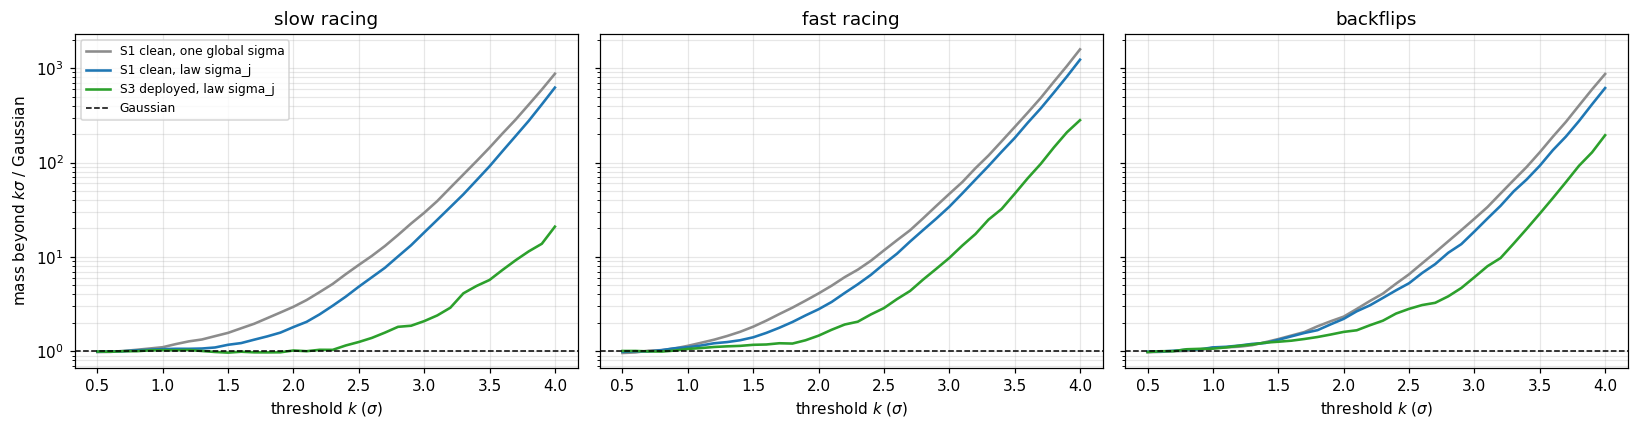

In [16]:
# Tail-mass ratios vs a true normal, mixture fit, and predictor correlation --
# measurements only; what and why is in the cell above, the reading below.
S0_LAW, COEF_LAW = 0.0811, 0.02618        # ARRAY law, characterize_shape_contradiction --block deploy
THR = [1.0, 1.5, 2.0, 3.0]
g_exp = [100 * 2 * (1 - sp_stats.norm.cdf(t)) for t in THR]

def _exceed(z):
    return [100 * np.mean(np.abs(z) > t) for t in THR]

def _std(x):
    return (x - np.median(x)) / robust_sigma(x)

def mixture2(w, iters=500):
    """Zero-mean two-component Gaussian mixture by EM (deterministic init from
    the robust sigma).  Fitted on the ABSOLUTE whitened residual r/sigma_j, so
    sigma_core doubles as the law's calibration factor."""
    w = np.asarray(w, float); w = w[np.isfinite(w)]
    s1, s2, p = robust_sigma(w), 5 * robust_sigma(w), 0.9
    for _ in range(iters):
        a = p * np.exp(-0.5 * (w / s1) ** 2) / s1
        b = (1 - p) * np.exp(-0.5 * (w / s2) ** 2) / s2
        g = a / np.maximum(a + b, 1e-300)
        p = g.mean()
        s1 = np.sqrt(max(np.sum(g * w ** 2) / max(np.sum(g), 1e-12), 1e-12))
        s2 = np.sqrt(max(np.sum((1 - g) * w ** 2) / max(np.sum(1 - g), 1e-12), 1e-12))
    return p, s1, s2

print(f"{'stream':<40} " + ' '.join(f'{t:>6.1f}s' for t in THR))
print(f"{'a true normal gives':<40} " + ' '.join(f'{v:>7.2f}' for v in g_exp))
print('-' * 40 + '-' * 49)
MIX, RESID_Q, ZCURVES = {}, {}, {}
for key in BAG_KEYS:
    d = D[key]
    rr = d['r'] - np.median(d['r'])
    cl = ~d['aliased']
    # per-return sigma from the full measured law: q_j = |v| sin(theta)/cos(phi)
    q = np.empty(len(rr))
    v_i = interp1d(d['st_t'], np.array([s.velocity for s in d['states']]), axis=0,
                   kind='linear', bounds_error=False, fill_value='extrapolate')
    q_i = interp1d(d['st_t'], np.array([s.orientation for s in d['states']]), axis=0,
                   kind='linear', bounds_error=False, fill_value='extrapolate')
    for f in np.unique(d['fi']):
        m = d['fi'] == f
        tf = d['radar'][int(f)].timestamp + RADAR_OFF
        v_b = quat_to_rotation_matrix(q_i(tf)).T @ v_i(tf)
        nv = max(np.linalg.norm(v_b), 1e-6)
        P = np.asarray(d['radar'][int(f)].positions, float)[d['pi'][m]]
        s_j = P / np.maximum(np.linalg.norm(P, axis=1), 1e-6)[:, None]   # sensor frame
        u_b = (R_BS @ s_j.T).T
        sin_t = np.sqrt(np.clip(1 - (u_b @ v_b / nv) ** 2, 0, 1))
        q[m] = nv * sin_t / np.maximum(s_j[:, 0], 0.15)                  # /cos(phi)
    sig_j = np.sqrt(S0_LAW ** 2 + (COEF_LAW * q) ** 2)
    # the three streams
    z_glob = _std(rr[cl])
    w_cl = rr[cl] / sig_j[cl]                       # ABSOLUTE whitened residual
    w_s3 = rr[S3_SEL[key]] / sig_j[S3_SEL[key]]     # ... on the deployed stream
    abs3 = 100 * np.mean(np.abs(w_cl - np.median(w_cl)) > 3) / g_exp[3]
    MIX[key] = (robust_sigma(w_cl), abs3) + mixture2(w_cl)
    # does the model finish the job?  if sigma_j captured the whole variance
    # structure, |whitened| would be independent of the predictor it was
    # built from.  Spearman is rank-based, so it needs no linearity.
    RESID_Q[key] = (sp_stats.spearmanr(np.abs(rr[cl]), q[cl]).statistic,
                    sp_stats.spearmanr(np.abs(w_cl), q[cl]).statistic)
    # grey vs blue = SAME stream, only the scaling differs (one global sigma
    # vs each return's own law sigma_j): that gap is the heteroscedasticity.
    # blue vs green = the front end (S1 clean vs the deployed S3 stream).
    ZCURVES[key] = [(z_glob, 'S1 clean, one global sigma', '0.55'),
                    (_std(w_cl), 'S1 clean, law sigma_j', 'tab:blue'),
                    (_std(w_s3), 'S3 deployed, law sigma_j', 'tab:green')]
    for z, tag, _c in ZCURVES[key]:
        e = _exceed(z)
        print(f'{SHORT[key] + ", " + tag:<40} ' + ' '.join(f'{v:>7.2f}' for v in e))
        print(f'{"   ratio to Gaussian":<40} '
              + ' '.join(f'{v / gg:>7.1f}' for v, gg in zip(e, g_exp)))
    print()

print('two-component mixture fit on the whitened residual, per flight:')
print(f"  {'bag':<13} {'sigma(w) rob':>12} {'core mass':>10} {'sigma_core':>11} "
      f"{'sigma_wide':>11} {'ratio':>7} {'3s ratio, ABS':>14}")
for key in BAG_KEYS:
    sw, a3, p, s1, s2 = MIX[key]
    print(f'  {SHORT[key]:<13} {sw:>12.2f} {100 * p:>9.0f}% {s1:>11.2f} '
          f'{s2:>11.2f} {s2 / s1:>6.1f}x {a3:>13.0f}x')
print()
print('Spearman rank correlation of residual size with the predictor q:')
print(f"  {'bag':<13} {'raw |r| vs q':>14} {'whitened |w| vs q':>19}")
for key in BAG_KEYS:
    a, b = RESID_Q[key]
    print(f'  {SHORT[key]:<13} {a:>+14.2f} {b:>+19.2f}')
# the same three streams as continuous curves: where each departs the
# Gaussian line is visible directly, instead of being read off one threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
tg = np.linspace(0.5, 4.0, 36)
gexp_g = 2 * (1 - sp_stats.norm.cdf(tg))
for ax, key in zip(axes, BAG_KEYS):
    for z, nm, c in ZCURVES[key]:
        ratio = [np.mean(np.abs(z) > t) / g for t, g in zip(tg, gexp_g)]
        ax.plot(tg, ratio, color=c, lw=1.7, label=nm)
    ax.axhline(1.0, color='k', lw=1.0, ls='--',
               label='Gaussian' if key == BAG_KEYS[0] else None)
    ax.set_yscale('log')
    ax.set_xlabel('threshold $k$ ($\\sigma$)')
    ax.set_title(SHORT[key])
    ax.grid(alpha=0.3, which='both')
axes[0].set_ylabel('mass beyond $k\\sigma$ / Gaussian')
axes[0].legend(fontsize=8, loc='upper left')
fig.tight_layout()

**Finding (most of the tail is structure; a remainder is not).** Read the
curves top to bottom, which is also before-to-after: before the rungs the tails
are largely *identifiable* structure -- a second labelled population and a
variance that moves with flight state -- and after the rungs and the variance
model an unexplainable remainder is still there. Specifically:

- **Two populations** (rung S1): the aliased returns are near-Gaussian in their
  own right but 2-5x wider (fast racing 0.72 against 0.14 m/s), and they carry
  32-42 % of the pooled fourth moment at 24-38 % of the points. A second
  Gaussian with a broken bearing (section 4) and recoverable Doppler -- not
  wild outliers.
- **Heteroscedasticity is the grey-vs-blue gap**: those two curves are the
  *same* S1-clean stream, differing only in whether each return is divided by
  one global $\sigma$ or by its own $\sigma_j$ from the measured law. Blue
  sitting below grey at every threshold on every flight is the point-to-point
  variance being conditioned away. The law even predicts the *between*-flight
  ordering: a Gaussian residual under the fitted $\sigma_j$ predicts
  $3\sigma$ ratios of 9.7 / 15.1 / 8.7 (slow / fast / flips) against
  29.3 / 46.5 / 25.4 measured -- a bag-independent ~3x remainder (round-3
  audit) -- so the bag differences are the law at different speed ranges, not a
  between-bag confound. The law itself is section 8's subject.
- **The front end is the blue-vs-green gap** (S1 clean vs the deployed S3
  stream): the rungs remove most of what the law cannot explain, bracketed
  between the random and oracle controls above.
- **What neither explains is the companion**: on every flight the whitened
  residual is a Gaussian core carrying 88-94 % of returns plus a companion
  5-11x wider carrying the rest -- the curves are a re-description of those two
  numbers (the fitted mixture reproduces the whole table; KS 1.3-2.5 %,
  round-3 audit). Its parameters are per flight and do not transfer
  ([audit round 3](../../worklog/2026-08-10_audit-round-3.md)), which is why
  section 8's two-parameter $\sigma_j$, which transfers and predicts *which*
  return is noisy, is the deliverable and the mixture is a description. After
  the full front end the companion is the green curve's remaining 2.1-9.7x at
  $3\sigma$ -- "Gaussian conditional on its variance" stays false, and Huber
  (next cell) exists to bound exactly this remainder.

Two law diagnostics ride along in the printed tables for section 8: the law's
absolute calibration is uneven ($\sigma(w)$ = 1.03 fast / 0.86 slow / 1.84
backflips, whose floor was never fitted -- its rows are shape-only, 55x at
$3\sigma$ on the law's own scale), and whitening leaves a residual rank
correlation with the law's own predictor (+0.25/+0.15/+0.07): the law
under-corrects. Both are 8b's business, not this section's.

bag            delta/sigma_S3  raw beyond delta  S3 beyond delta
slow racing             11.6x             2.66%            0.03%
fast racing              8.9x            11.48%            1.55%
backflips                4.1x             7.18%            1.13%

Sanity: delta sits 4.1-11.6x above the post-ladder core (vs 1.345x for a
textbook efficiency kernel) and 20x the 0.049 m/s quantization bin: it
shapes only the tail, never the fit. Same design for the accelerometer
(delta_a = 2.0 m/s^2 vs in-band residual 0.45-1.1 = 1.8-4.4x). Ablation
(measured at the rate-law-era defaults, like the other front-end rows of
the sec. 11 ledger): removing Huber is bit-par on slow (it touches 0.03%
of kept points) but costs fast racing drift 1.17 -> 1.45%.


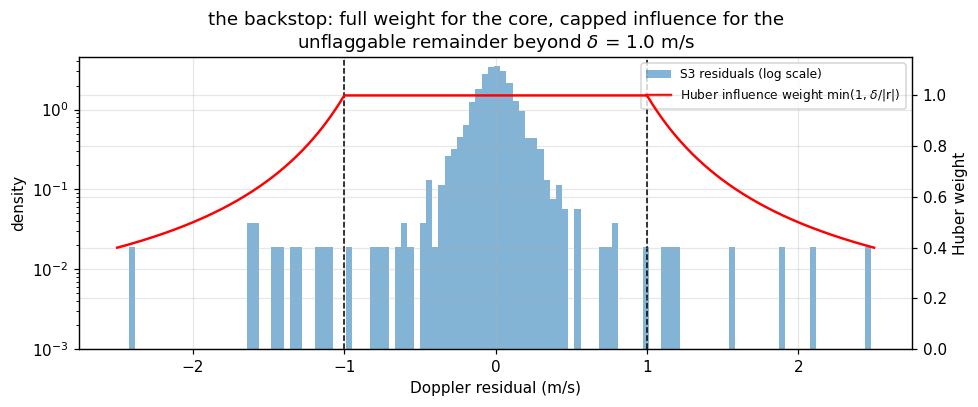

In [17]:
# Huber: the backstop for the unflaggable remainder + a brief parameter sanity
# check. delta = 1.0 m/s is deliberately NOT an efficiency-tuned M-estimator
# (that convention would be delta ~ 1.345 sigma); it is a wide backstop that
# leaves the core strictly quadratic and only caps what the ladder cannot flag.
print(f"{'bag':<14} {'delta/sigma_S3':>14} {'raw beyond delta':>17} {'S3 beyond delta':>16}")
for key in BAG_KEYS:
    d = D[key]
    rr = d['r'] - np.median(d['r'])
    r3 = rr[S3_SEL[key]]
    print(f'{SHORT[key]:<14} {1.0/robust_sigma(r3):>13.1f}x '
          f'{100*np.mean(np.abs(rr) > 1.0):>16.2f}% {100*np.mean(np.abs(r3) > 1.0):>15.2f}%')
print()
print('Sanity: delta sits 4.1-11.6x above the post-ladder core (vs 1.345x for a')
print('textbook efficiency kernel) and 20x the 0.049 m/s quantization bin: it')
print('shapes only the tail, never the fit. Same design for the accelerometer')
print('(delta_a = 2.0 m/s^2 vs in-band residual 0.45-1.1 = 1.8-4.4x). Ablation')
print('(measured at the rate-law-era defaults, like the other front-end rows of')
print('the sec. 11 ledger): removing Huber is bit-par on slow (it touches 0.03%')
print('of kept points) but costs fast racing drift 1.17 -> 1.45%.')

d = D['fast_racing_best_velocity']
rr = d['r'] - np.median(d['r'])
r3 = rr[S3_SEL['fast_racing_best_velocity']]
fig, ax = plt.subplots(figsize=(9, 3.8))
lim = 2.5
ax.hist(r3[np.abs(r3) < lim], bins=120, density=True, alpha=0.55,
        label='S3 residuals (log scale)')
ax.set_yscale('log'); ax.set_ylim(1e-3, None)
ax2 = ax.twinx()
xg = np.linspace(-lim, lim, 500)
ax2.plot(xg, np.minimum(1.0, 1.0/np.maximum(np.abs(xg), 1e-9)), 'r-', lw=1.6,
         label='Huber influence weight min(1, $\\delta$/|r|)')
ax2.set_ylim(0, 1.15); ax2.set_ylabel('Huber weight')
ax.axvline(1.0, color='k', ls='--', lw=1); ax.axvline(-1.0, color='k', ls='--', lw=1)
ax.set_xlabel('Doppler residual (m/s)'); ax.set_ylabel('density')
ax.set_title('the backstop: full weight for the core, capped influence for the\n'
             'unflaggable remainder beyond $\\delta$ = 1.0 m/s')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
fig.tight_layout()

> **Design consequence.** What the whitened residual *is*, measured: a Gaussian
> core carrying 88-94 % of the returns, plus a companion 5-11x wider carrying
> the rest -- one shape on all three flights (and on eight flights across two
> platforms, with per-flight numbers;
> [audit round 3](../../worklog/2026-08-10_audit-round-3.md)). A variance model
> rescales the core, and the companion is not the core: that is why
> conditioning on $\sigma_j$, the thing the next two sections measure and
> deploy, moves every threshold toward normal without reaching it. Which stream
> you ask also matters: before the front end, 18-34x the Gaussian tail survives
> at $3\sigma$; on the S3 stream the solver consumes, 2.1-9.7x, with slow
> racing at 1.0x out to $2\sigma$. Least squares is licensed by what the front
> end and the variance model leave, measured rather than assumed.
>
> Each cause gets the treatment it calls for, and this is the whole weighting
> design in one paragraph:
> - *two populations* -> label them and weight by measured variance: the
>   constant inverse-variance alias weight of 8f (down-weight, not deletion --
>   the distributional evidence here, not just the end-to-end record, is why);
> - *heteroscedasticity* -> a per-point variance model: the adaptive law of
>   section 8;
> - *genuine outliers* -> the consensus prefilter of section 7, with Huber's
>   $\delta = 1.0$ m/s as a wide backstop for what survives it.
>
> Because the aliased population is *down-weighted* rather than deleted, the
> likelihood the solver optimizes is the distribution measured here, to within
> that weight: there is no fork between the story and the shipped estimator.
> A Student-t likelihood was considered and rejected: a single t forces one
> tail shape on what is measured to be two populations, cannot say which return
> belongs to which, and treats clustered, flip-biased bad points as honest
> big-noise data (the GNC redescending-loss experiment confirmed this end to
> end). Modelling the two explicitly is what makes the per-point weight
> possible.

## 7. Where the error lives

Section 6 flagged the outlier populations by mechanism and demonstrated the
deployed consensus. This section maps how the radar error varies across the
sensor's rays, the flight regime, and signal strength: 4a bias and noise by
elevation, 4b by intensity.

slow racing  u_z bin centers: -0.9 -0.7 -0.5 -0.3 -0.1 +0.1 +0.3 +0.5 +0.7 +0.9
             bias  per bin:   +0.06 -0.02 -0.02 -0.02 -0.01 -0.01 -0.03 -0.01 +0.01 -0.01
             sigma per bin:   0.19 0.10 0.13 0.08 0.07 0.08 0.08 0.11 0.09 0.13
fast racing  u_z bin centers: -0.9 -0.7 -0.5 -0.3 -0.1 +0.1 +0.3 +0.5 +0.7 +0.9
             bias  per bin:   -0.00 -0.04 -0.01 -0.06 -0.02 -0.04 -0.01 +0.01 +0.03 -0.01
             sigma per bin:   0.21 0.14 0.22 0.24 0.19 0.21 0.18 0.16 0.15 0.15
backflips    u_z bin centers: -0.9 -0.7 -0.5 -0.3 -0.1 +0.1 +0.3 +0.5 +0.7 +0.9
             bias  per bin:   -0.09 -0.05 -0.04 -0.04 +0.02 +0.02 +0.04 +0.11 +0.34 +0.69
             sigma per bin:   0.64 0.43 0.31 0.29 0.34 0.32 0.31 0.30 0.65 1.05


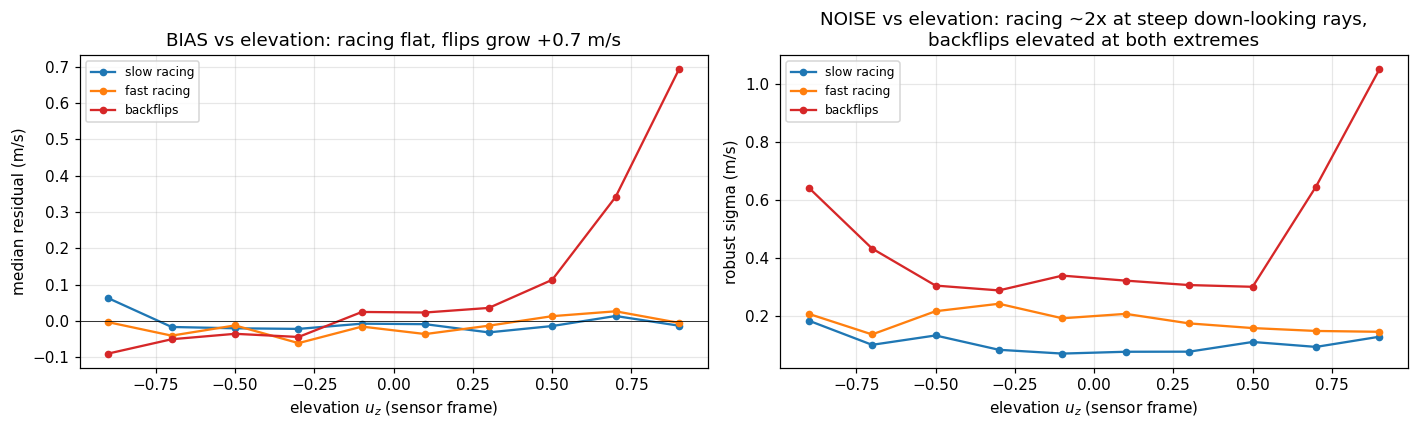

In [18]:
# 4a. Residual bias and sigma vs elevation angle (sensor-frame u_z of the ray)
uz_edges = np.linspace(-1.0, 1.0, 11)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
res4a = {}
for key in BAG_KEYS:
    d = D[key]
    c, s, b, n = binned_sigma_bias(d['u_z'], d['r'], uz_edges)
    res4a[key] = (c, s, b)
    axes[0].plot(c, b, '-o', ms=4, color=COLOR[key], label=SHORT[key])
    axes[1].plot(c, s, '-o', ms=4, color=COLOR[key], label=SHORT[key])
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('elevation $u_z$ (sensor frame)')
axes[0].set_ylabel('median residual (m/s)')
axes[0].set_title('BIAS vs elevation: racing flat, flips grow +0.7 m/s')
axes[1].set_xlabel('elevation $u_z$ (sensor frame)')
axes[1].set_ylabel('robust sigma (m/s)')
axes[1].set_title('NOISE vs elevation: racing ~2x at steep down-looking rays,\n'
                  'backflips elevated at both extremes')
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
for key in BAG_KEYS:
    c, s, b = res4a[key]
    print(f'{SHORT[key]:<12} u_z bin centers: ' + ' '.join(f'{x:+.1f}' for x in c))
    print(f'{"":<12} bias  per bin:   ' + ' '.join(f'{x:+.2f}' for x in b))
    print(f'{"":<12} sigma per bin:   ' + ' '.join(f'{x:.2f}' for x in s))


These are total residuals (frame-shared and return-individual error), so each curve is an upper bound.

Under fast and slow racing, the median error and error std stay stable. Only backflips diverge as elevation increases. This is a flight-regime effect, and thus steep rays are not removed. They are the sole carriers of vertical velocity and the flip-regime must be treated separately.

The one defensible statement, and it is narrower than it looks: the
STRONGEST decile is the quietest on every bag -- by 37% on fast racing, but
only 12% and 5% on the other two, and sigma peaks MID-range on all three,
so a monotone weight has the wrong shape over the whole lower half:
  slow racing  sigma weakest/peak/strongest decile 0.084/0.114/0.074
  fast racing  sigma weakest/peak/strongest decile 0.177/0.288/0.111
  backflips    sigma weakest/peak/strongest decile 0.308/0.442/0.293


confound-controlled exponent (within |v| terciles):
  slow racing  v~1.0: +1.11  v~2.3: +0.75  v~3.1: -0.42
  fast racing  v~1.4: +0.64  v~3.3: +1.17  v~4.7: +1.54
  backflips    v~2.0: -0.08  v~4.0: +0.51  v~4.8: +0.82
pooled alpha_hat = 0.61 (slow racing 0.56, fast racing 1.03, backflips 0.25);  per-point I/I_med spans 0.39-3.28

Direct test of the CRLB scaling on the variable actually used, the slope
of log10(sigma^2) against intensity in dB (CRLB on linear SNR would give
-0.10 per dB):
  slow rac

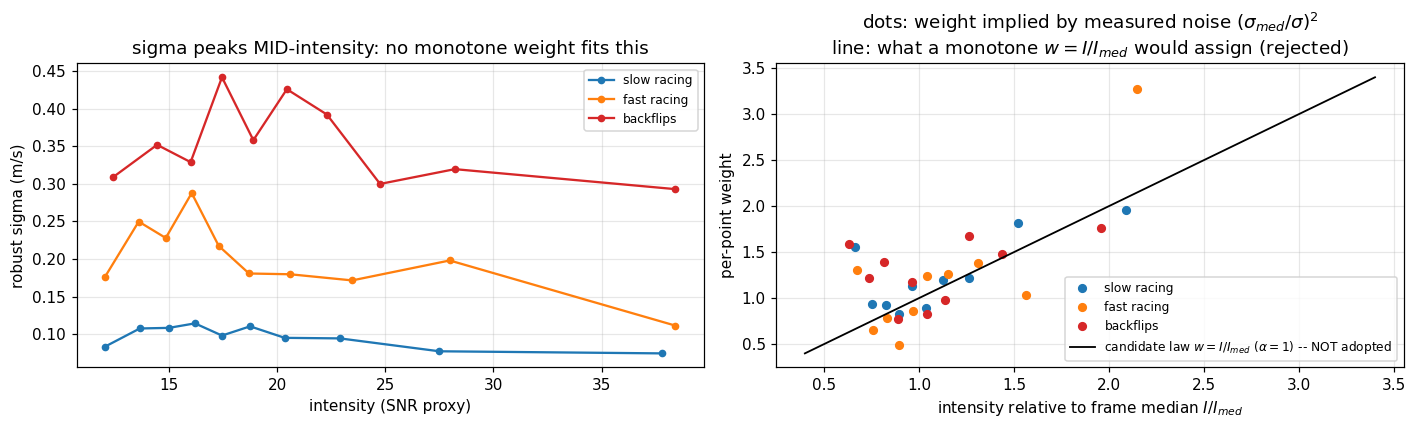

In [19]:
# 4b. Signal strength: does it predict residual size well enough to weight on?
# The answer is no, and this cell is where that is measured -- see the finding
# below it.  The intensity weight w = I/I_med it was built to justify was
# DELETED on 2026-08-09 (worklog/2026-08-09_snr-weight-deletion.md); the panels
# below plot it as the rejected candidate, not as the deployed rule.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
span_txt, alpha_txt, logx, logy, w_pts = [], [], [], [], []
for key in BAG_KEYS:
    d = D[key]
    inten = d['dres']['intensities']
    i_edges = np.unique(np.percentile(inten, np.linspace(0, 100, 11)))
    c, s, n = binned_sigma(inten, d['r'], i_edges)
    axes[0].plot(c, s, '-o', ms=4, color=COLOR[key], label=SHORT[key])
    s_med = np.interp(np.median(inten), c, s)
    imp = (s_med / s) ** 2                    # weight the measured noise implies
    x_rel = c / np.median(inten)
    axes[1].plot(x_rel, imp, 'o', ms=5, color=COLOR[key], label=SHORT[key])
    logx.extend(np.log(x_rel)); logy.extend(np.log(imp))
    alpha_txt.append(f'{SHORT[key]} {np.polyfit(np.log(x_rel), np.log(imp), 1)[0]:.2f}')
    span_txt.append(f'{SHORT[key]:<12} sigma weakest/peak/strongest decile '
                    f'{s[0]:.3f}/{s.max():.3f}/{s[-1]:.3f}')
    # the actual per-point relative intensity the solver weights with
    for f in d['radar']:
        if f.intensities is None:
            continue
        iv = np.asarray(f.intensities, float)
        iv = iv[iv > 0]
        if len(iv):
            w_pts.append(iv / np.median(iv))
w_pts = np.concatenate(w_pts)
a_pool = np.polyfit(logx, logy, 1)[0]
axes[0].set_xlabel('intensity (SNR proxy)')
axes[0].set_ylabel('robust sigma (m/s)')
axes[0].set_title('sigma peaks MID-intensity: no monotone weight fits this')
axes[0].legend(fontsize=8)
xr = np.linspace(0.4, 3.4, 10)
axes[1].plot(xr, xr, '-', color='k', lw=1.2,
             label='candidate law $w = I/I_{med}$ ($\\alpha=1$) -- NOT adopted')
axes[1].set_xlabel('intensity relative to frame median $I/I_{med}$')
axes[1].set_ylabel('per-point weight')
axes[1].set_title('dots: weight implied by measured noise $(\\sigma_{med}/\\sigma)^2$\n'
                  'line: what a monotone $w=I/I_{med}$ would assign (rejected)')
axes[1].legend(fontsize=8)
fig.tight_layout()
print('The one defensible statement, and it is narrower than it looks: the')
print('STRONGEST decile is the quietest on every bag -- by 37% on fast racing, but')
print('only 12% and 5% on the other two, and sigma peaks MID-range on all three,')
print('so a monotone weight has the wrong shape over the whole lower half:')
for t in span_txt:
    print('  ' + t)
print()
# confound control: the regime (speed) is the confounder that attenuates the
# pooled slope (errors-in-variables); refit the exponent within |v| terciles
print()
print('confound-controlled exponent (within |v| terciles):')
for key in BAG_KEYS:
    d = D[key]
    vi = interp1d(d['st_t'], np.array([s.velocity for s in d['states']]),
                  axis=0, kind='linear', bounds_error=False,
                  fill_value='extrapolate')
    t_pts = np.array([d['radar'][i].timestamp for i in d['fi']]) + RADAR_OFF
    v_pts = np.linalg.norm(vi(t_pts), axis=1)
    inten2 = d['dres']['intensities']
    terc = np.quantile(v_pts, [0, 1/3, 2/3, 1.0])
    parts = []
    for lo, hi in zip(terc[:-1], terc[1:]):
        m = (v_pts >= lo) & (v_pts < hi)
        if m.sum() < 350:
            continue
        i_m, r_m = inten2[m], d['r'][m]
        i_edges2 = np.unique(np.percentile(i_m, np.linspace(0, 100, 8)))
        c2, s2, _ = binned_sigma(i_m, r_m, i_edges2, min_n=40)
        if len(c2) < 4:
            continue
        s_med2 = np.interp(np.median(i_m), c2, s2)
        al = np.polyfit(np.log(c2 / np.median(i_m)),
                        np.log((s_med2 / s2) ** 2), 1)[0]
        parts.append(f'v~{0.5*(lo+hi):.1f}: {al:+.2f}')
    print(f'  {SHORT[key]:<12} ' + '  '.join(parts))

print(f'pooled alpha_hat = {a_pool:.2f} ({", ".join(alpha_txt)});'
      f'  per-point I/I_med spans {w_pts.min():.2f}-{w_pts.max():.2f}')
print()
print('Direct test of the CRLB scaling on the variable actually used, the slope')
print('of log10(sigma^2) against intensity in dB (CRLB on linear SNR would give')
print('-0.10 per dB):')
for key in BAG_KEYS:
    d = D[key]
    inten = d['dres']['intensities']
    e = np.unique(np.percentile(inten, np.linspace(0, 100, 9)))
    c, s, _ = binned_sigma(inten, d['r'], e)
    sl = np.polyfit(c, np.log10(s ** 2), 1)[0]
    print(f'  {SHORT[key]:<13} I spans {inten.min():.1f}-{inten.max():.1f} dB, '
          f'slope {sl:+.4f}/dB  ({abs(0.1/sl):.0f}x shallower than CRLB)')
print()
print(f'For scale, measured per-point I/I_med spans '
      f'{w_pts.min():.2f}-{w_pts.max():.2f} (the law, had it been adopted, was '
      f'to be applied unclamped).')


Signal strength does not predict residual size well enough to weight on, as the trend is not monotone.

> **Design consequence.**
>
> *The error is regime-structured:* Under backflips, but not on the other bags, bias and std increase with ray elevation.
>
> *Signal strength founds no weight:* $\sigma$ peaks *mid*-intensity on every
> bag, so no monotone intensity weight matches the measured shape; The narrow true statement is that the
> strongest decile is the quietest, but the behaviour does not follow a derivable law. The weak dependence
> is not an anomaly of this sensor: the field is on-chip SNR in dB, the
> measured dB slope is 4x to 20x shallower than the Cramer-Rao `var ~ 1/SNR`
> result (a statement about linear SNR) would require, and detection-level DOA
> error on TDM-MIMO devices is dominated by SNR-*independent* floors
> (array-manifold error, mutual coupling, angle-FFT quantization — the classic
> bias-floor regime, e.g. Duerr et al. 2019). A manifold-limited device is not
> expected to yield a usable SNR weight, and this one does not.
>
> What each layer is worth end to end is measured in section 11's ablation
> ledger.

## 8. How the error scales with dynamics

How much should each sensor be trusted *as a function of flight dynamics*? Six
measurements, in six subsections: **8a** detects the inflation, **8b** derives
and tests the per-return law, **8c** measures the two traps between measured
curves and usable weights, **8d** models the within-frame correlation exactly,
**8e** derives the static per-stream weights, **8f** measures the treatment of
aliased returns. What the solver deploys from each measurement -- and what it
declined -- is summarised once, at the end of the section (the
design-consequence table), and priced end to end in the section-11 ledger.

Two constants in this section are **not** derived and are labelled as such
where they appear: `accel_soft_sigma` (8e) and the alias weight, which stands
on its end-to-end record rather than on its derivation (8f).

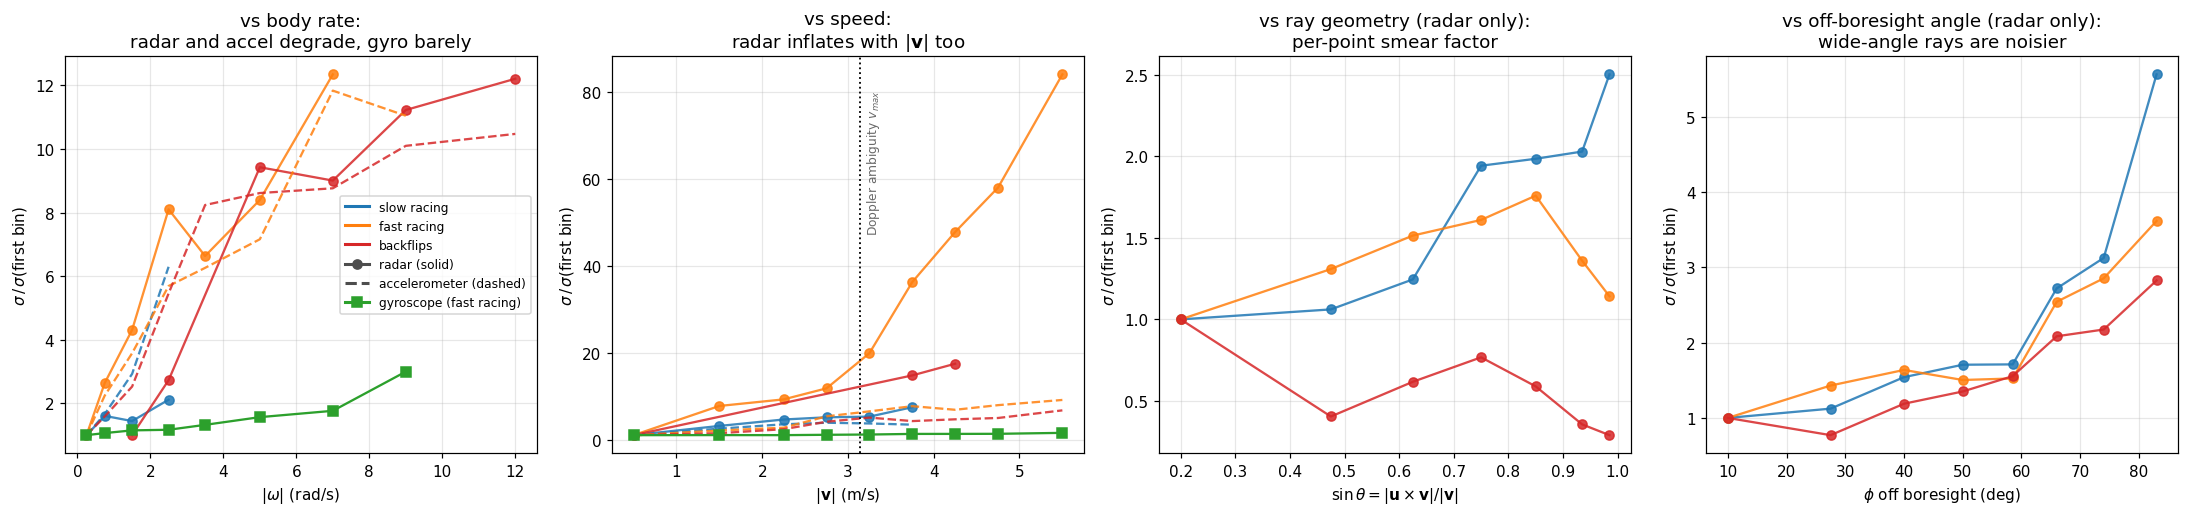

In [20]:
# 8a. Noise inflation vs body rate, speed, and ray geometry (the raw detection)
# Color = bag; solid = radar, dashed = accelerometer, green squares = gyro.
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))

V_BIN_EDGES = np.array([0, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0])
SIN_BIN_EDGES = np.array([0, 0.4, 0.55, 0.7, 0.8, 0.9, 0.97, 1.0001])
PHI_BIN_EDGES = np.array([0, 20, 35, 45, 55, 62, 70, 78, 88])   # deg off boresight

def phi_deg(dd):
    # off-boresight angle of each return's ray: +x is the sensor boresight
    # (driver convention), so cos(phi) is the ray's x-component
    out = np.empty(len(dd['r']))
    for i_f in np.unique(dd['fi']):
        m = dd['fi'] == i_f
        Pf = np.asarray(dd['radar'][int(i_f)].positions, float)[dd['pi'][m]]
        out[m] = Pf[:, 0] / np.maximum(np.linalg.norm(Pf, axis=1), 1e-6)
    return np.degrees(np.arccos(np.clip(out, -1, 1)))

def speed_at(dd, t):
    vi = interp1d(dd['st_t'], np.array([s.velocity for s in dd['states']]),
                  axis=0, kind='linear', bounds_error=False,
                  fill_value='extrapolate')
    return np.linalg.norm(vi(t), axis=1)

def sin_theta(dd, v_pts):
    # per-point ray-vs-velocity angle from the model itself: pred_j = -u_j . v
    cosb = np.clip(dd['pred'] / np.maximum(v_pts, 0.2), -1, 1)
    return np.sqrt(1 - cosb**2)

# radar: per-point residual sigma binned by |omega|, |v|, sin(theta) -- all bags
for key in BAG_KEYS:
    dd = D[key]
    t_pts = np.array([dd['radar'][i].timestamp for i in dd['fi']]) + RADAR_OFF
    v_pts = speed_at(dd, t_pts)
    for ax, xv, edges in [(axes[0], dd['om_pts'], OMEGA_BIN_EDGES),
                          (axes[1], v_pts, V_BIN_EDGES),
                          (axes[2], sin_theta(dd, v_pts), SIN_BIN_EDGES),
                          (axes[3], phi_deg(dd), PHI_BIN_EDGES)]:
        c_r, s_r, _ = binned_sigma(xv, dd['r'], edges)
        ax.plot(c_r, s_r / s_r[0], 'o-', color=COLOR[key], alpha=0.85)

# accelerometer: all bags, dashed, same bag colors (no ray-geometry panel: the
# IMU has no ray)
G = np.array([0.0, 0.0, -9.81])
for key in BAG_KEYS:
    dd = D[key]
    if dd['states'][0].acceleration is None:
        continue
    t_imu = np.array([m.timestamp for m in dd['imu']]) + IMU_OFF
    om_imu = np.linalg.norm(dd['om_interp'](t_imu), axis=1)
    v_imu = speed_at(dd, t_imu)
    ac_i = interp1d(dd['st_t'], np.array([s.acceleration for s in dd['states']]),
                    axis=0, kind='linear', bounds_error=False,
                    fill_value='extrapolate')
    qu_i = interp1d(dd['st_t'], np.array([s.orientation for s in dd['states']]),
                    axis=0, kind='linear', bounds_error=False,
                    fill_value='extrapolate')
    acc = np.array([m.linear_acceleration for m in dd['imu']])
    a_w = ac_i(t_imu); q_all = qu_i(t_imu)
    a_res = np.empty_like(acc)
    for i in range(len(t_imu)):
        a_res[i] = acc[i] - quat_to_rotation_matrix(q_all[i]).T @ (a_w[i] - G)
    a_res -= np.median(a_res, axis=0)
    for ax, xv, edges in [(axes[0], om_imu, OMEGA_BIN_EDGES),
                          (axes[1], v_imu, V_BIN_EDGES)]:
        c_a, s_a, _ = binned_sigma(np.repeat(xv, 3), a_res.ravel(), edges)
        ax.plot(c_a, s_a / s_a[0], '--', color=COLOR[key], alpha=0.85)

# gyro: fast racing only (the flat reference curve; one bag suffices)
d = D['fast_racing_best_velocity']
t_imu = np.array([m.timestamp for m in d['imu']]) + IMU_OFF
om_ref = d['om_interp'](t_imu)
om_imu = np.linalg.norm(om_ref, axis=1)
v_imu = speed_at(d, t_imu)
g_res = np.array([m.angular_velocity for m in d['imu']]) - om_ref
g_res -= np.median(g_res, axis=0)
for ax, xv, edges in [(axes[0], om_imu, OMEGA_BIN_EDGES),
                      (axes[1], v_imu, V_BIN_EDGES)]:
    c_g, s_g, _ = binned_sigma(np.repeat(xv, 3), g_res.ravel(), edges)
    ax.plot(c_g, s_g / s_g[0], '-s', color='tab:green')

from matplotlib.lines import Line2D
handles = [Line2D([], [], color=COLOR[k], lw=2, label=SHORT[k]) for k in BAG_KEYS]
handles += [
    Line2D([], [], color='0.3', lw=2, ls='-', marker='o', label='radar (solid)'),
    Line2D([], [], color='0.3', lw=2, ls='--', label='accelerometer (dashed)'),
    Line2D([], [], color='tab:green', lw=2, marker='s',
           label='gyroscope (fast racing)')]
axes[0].legend(handles=handles, fontsize=8)

axes[0].set_xlabel('$|\\omega|$ (rad/s)')
for ax in axes:
    ax.set_ylabel('$\\sigma\\,/\\,\\sigma$(first bin)')
axes[0].set_title('vs body rate:\nradar and accel degrade, gyro barely')
axes[1].axvline(d['v_max'], color='k', ls=':', lw=1.2)
axes[1].text(d['v_max'] + 0.06, 0.55, 'Doppler ambiguity $v_{max}$',
             transform=axes[1].get_xaxis_transform(), rotation=90,
             fontsize=8, color='dimgray', va='bottom')
axes[1].set_xlabel('$|\\mathbf{v}|$ (m/s)')
axes[1].set_title('vs speed:\nradar inflates with $|\\mathbf{v}|$ too')
axes[2].set_xlabel('$\\sin\\theta = |\\mathbf{u}\\times\\mathbf{v}|/|\\mathbf{v}|$')
axes[2].set_title('vs ray geometry (radar only):\nper-point smear factor')
axes[3].set_xlabel('$\\phi$ off boresight (deg)')
axes[3].set_title('vs off-boresight angle (radar only):\nwide-angle rays are noisier')
fig.tight_layout()

**Finding (8a).** Radar and accelerometer residuals degrade much more than the
gyro under dynamics (7-12x vs ~3x), so they must lose weight under aggressive
flight and the gyro must not.

**Why these panels cannot pick the law.** They are total residuals against the
MoCap reference, so each curve is an upper bound (the reference error grows with
motion too), and the four x-axes are not independent: $|\omega|$ and
$|\mathbf{v}|$ rise together on these flights (rank correlation $\approx +0.5$),
low $\sin\theta$ means the ray is aligned with the velocity, where |Doppler|
peaks and aliasing lives, and the off-boresight panel mixes the ray error's own
growth with whatever scene happens to sit at wide angles. The radar blow-up in the speed panel starts exactly at
$v_\mathrm{max}$: that part is the aliased population of section 4, not noise
inflation of clean returns. To find which variable is the cause, we need the reference-immune statistic
defined in the next cell, and a fit in which the variables compete (8b).


**The noise decomposition used from 8b on (defined here).** Every kept return $j$ in
radar frame $f$ carries a Doppler residual modeled as

$$ r_{fj} = c_f + e_{fj}, \qquad c_f \sim (0,\, \sigma_c^2), \qquad
   e_{fj} \sim (0,\, \sigma_i^2) $$

$c_f$ is the **frame-shared** error: whatever the whole frame gets wrong together
(reference velocity error at that instant, timestamp error, scene-wide multipath).
$e_{fj}$ is the **per-point** error, independent from return to return (thermal noise,
quantization, per-ray geometry). Both scales are estimated per bag from two
complementary statistics:

- *Within* one frame, deviations from the frame's own mean cancel $c_f$ exactly, so
  the average within-frame variance estimates $\sigma_i^2$ with no contribution from
  the frame-shared error.
- *Across* frames, the frame means $\bar r_f$ scatter for two reasons: their shared
  errors $c_f$ (variance $\sigma_c^2$), and the per-point noise that a finite average
  over $N_f$ returns has not removed (variance $\sigma_i^2/N_f$). With $\bar N$ the
  average number of kept returns per frame,

$$ \operatorname{Var}_f(\bar r_f) \;\approx\; \sigma_c^2 + \frac{\sigma_i^2}{\bar N}
   \qquad\Rightarrow\qquad
   \hat\sigma_c^2 \;=\; \operatorname{Var}_f(\bar r_f) - \frac{\hat\sigma_i^2}{\bar N} $$

The subtraction is the crucial part: frame means would scatter even if radar errors
were purely per-point ($\sigma_c = 0$), by exactly $\sigma_i^2/\bar N$; only the
excess above that baseline is evidence of a shared component. It also makes
$\hat\sigma_c^2$ a noisy estimator (a difference of two similar numbers, clamped at
zero).

The split matters because $\sigma_i$ is immune to anything **common to every ray
in the frame** -- a scalar Doppler offset, whatever its origin -- which cancels
exactly inside within-frame deviations. That makes $\sigma_i$, sliced against
any candidate variable, a far better place to test a sensor noise model than the
total curves of 8a, which are only upper bounds.

*It is not immune to reference error in general, though.* A reference
**velocity** error is a 3-vector, so it is not constant across the frame, and the
frame mean removes only its projection on the mean ray -- two of its three
degrees of freedom survive. Replacing the frame mean with a full 3-DoF velocity
fit drops the measured $\sigma_i$ by 3.1 % on fast racing (the main fit bag),
17.8 % on slow and 39.3 % on backflips, which bounds what a reference error
could still be contributing (`analysis/characterize_reference_immunity_bound.py`).
**The bound is comfortable where the law is fitted and uncomfortable where it is
not** -- which is why backflips is a transfer test below rather than a fit flight.

In [21]:
# 8b. Extract the decomposition, per bag.  frame_components returns, per frame:
# (within-frame variance, mean, n, |omega|, |v|, median range, rms_f sin(theta),
# rms_f sin(theta)/cos(phi)).  FRAMES = all kept returns (for sigma_c, 8c);
# FRAMES_CUT = alias-cut (what the law is fitted to: aliased returns carry the
# broken-bearing floor of 8f and must not contaminate the clean budget).
def frame_components(key, alias_cut=False):
    d = D[key]
    r, fi = d['r'], d['fi']
    keep = np.abs(r - np.median(r)) < 6 * robust_sigma(r)
    if alias_cut:
        keep = keep & ~d['aliased']
    v_i = interp1d(d['st_t'], np.array([s.velocity for s in d['states']]),
                   axis=0, kind='linear', bounds_error=False,
                   fill_value='extrapolate')
    out = []
    for f in np.unique(fi):
        m = (fi == f) & keep
        if np.sum(m) >= 6:
            fr = d['radar'][int(f)]
            t_f = fr.timestamp + RADAR_OFF
            P = np.asarray(fr.positions, float)
            q_f = quat_to_rotation_matrix(
                interp1d(d['st_t'],
                         np.array([s.orientation for s in d['states']]), axis=0,
                         kind='linear', bounds_error=False,
                         fill_value='extrapolate')(t_f))
            v_b = q_f.T @ v_i(t_f)
            nv = max(np.linalg.norm(v_b), 1e-6)
            Pk = P[d['pi'][m]]
            # s_j is the unit ray in the SENSOR frame, so s_j[0] = cos(phi_j),
            # the angle off boresight (+x is boresight by driver convention,
            # DataHandlerClass.cpp:633-635).  u_b is the same ray in the body
            # frame, which is what the velocity angle theta_j needs.
            s_j = Pk / np.maximum(np.linalg.norm(Pk, axis=1), 1e-6)[:, None]
            u_b = (R_BS @ s_j.T).T
            sin2_j = np.clip(1 - (u_b @ v_b / nv) ** 2, 0, 1)
            rms_sin = float(np.sqrt(np.mean(sin2_j)))
            rms_arr = float(np.sqrt(np.mean(
                sin2_j / np.maximum(s_j[:, 0], 0.15) ** 2)))
            out.append((np.var(r[m], ddof=1), np.mean(r[m]), int(np.sum(m)),
                        np.linalg.norm(d['om_interp'](t_f)),
                        np.linalg.norm(v_i(t_f)),
                        float(np.median(np.linalg.norm(P, axis=1))),
                        rms_sin, rms_arr))
    return out

FRAMES = {k: frame_components(k) for k in BAG_KEYS}
FRAMES_CUT = {k: frame_components(k, alias_cut=True) for k in BAG_KEYS}
racing = ['slow_racing_best_velocity', 'fast_racing_best_velocity']

print('the statistic every 8b fit below targets: per-frame sigma_i, alias-cut,')
print('frames with >= 6 kept returns.')
print(f"{'bag':<14} {'frames':>7} {'mean N':>7} {'sigma_i rms':>12} "
      f"{'per-frame p25-p75':>18}")
for key in BAG_KEYS:
    A = np.array(FRAMES_CUT[key])
    s = np.sqrt(A[:, 0])
    print(f"{SHORT[key]:<14} {len(A):>7d} {A[:, 2].mean():>7.1f} "
          f"{np.sqrt(A[:, 0].mean()):>12.3f} "
          f"{np.percentile(s, 25):>8.3f}-{np.percentile(s, 75):<8.3f}")

the statistic every 8b fit below targets: per-frame sigma_i, alias-cut,
frames with >= 6 kept returns.
bag             frames  mean N  sigma_i rms  per-frame p25-p75
slow racing        242    13.1        0.107    0.066-0.127   
fast racing        115    11.5        0.207    0.089-0.213   
backflips          109     9.2        0.372    0.140-0.396   


**What the rest of 8b does, and how.** The question is which physical mechanism
sets $\sigma_i$. The method: derive each candidate from the forward model or the
chirp configuration, write down the *specific* shape it predicts, then fit all of
them **at once** against the per-frame $\sigma_i$ extracted above and let the
data divide the signal. Independent error sources add in quadrature, so every
row of the ladder below is one fit of the same data,

$$ \sigma_i^2(\text{frame } f) \;=\; \sigma_{0,\mathrm{bag}}^2
   \;+\; \big(\mathrm{term}(f)\big)^2, $$

with **per-bag floors** $\sigma_0$ (scene- and range-dependent) and the row's
**single shared response coefficient** (platform physics must not differ per
flight). Floors and coefficient are fitted *jointly* -- the bag index only
selects which floor applies to a frame, so a ladder row has 3-4 free
parameters against ~360 frames, and rows are *alternatives scored against
each other*, never one grand sum of all terms. Robust on the $\sigma$ scale (`soft_l1`; per-frame $\hat\sigma$ is
$\chi$-tailed). Four rules keep this a test rather than curve shopping: every
candidate is *derived* before it is fitted; candidates compete *jointly* (the
fit is free to hand a term's mass to a competitor, and repeatedly hands one
exactly zero); *controls that must fail* are included (a Doppler scale error
predicts $\sigma \propto |v_r|$ and must come out null); and the winner must
*transfer* with frozen parameters to a held-out flight and platform.

**The candidates, named before any of them is discussed.** Three mechanisms
could plausibly make the per-return noise grow with dynamics on this sensor;
each derivation below ends at the shape the ladder fits.

| # | mechanism | predicted shape |
|---|---|---|
| 1 | **temporal smear**: the ray sweeps during the 49.92 ms coherent window, so the Doppler peak drifts while it is integrated | $\propto v^2\sin^2\theta/\rho$ |
| 2 | **range migration**: the target crosses range bins inside that window | $\propto v$ |
| 3 | **bearing error**: the reported ray direction is wrong by a small angle; the angular channel (~30 deg) is the coarsest thing about this sensor | $\propto v\sin\theta$ |

<details>
<summary><b>Unfold: derivation 1 -- temporal smear</b></summary>

A static scatterer on the body-frame unit ray $\mathbf u(t)$, platform velocity
$\mathbf v$, returns $v_r(t) = -\mathbf u(t)^\top\mathbf v$. In the world
frame the ray turns only because the platform translates past the scatterer at
range $\rho$ ($\dot{\mathbf u} = -(\mathbf v - (\mathbf u^\top\mathbf v)\mathbf u)/\rho$):

$$\begin{aligned}
\frac{dv_r}{dt} \;&=\; -\dot{\mathbf u}^\top\mathbf v
  \;=\; \frac{|\mathbf v|^2 - (\mathbf u^\top\mathbf v)^2}{\rho}
  \;=\; \frac{|\mathbf v|^2\sin^2\theta}{\rho} \\[4pt]
dv_r \;&=\; \frac{|\mathbf v|^2\sin^2\theta}{\rho}\;dt \\[4pt]
\Delta v_r \;&=\; \underbrace{\frac{|\mathbf v|^2\sin^2\theta}{\rho}}_{\text{drift rate, pure geometry}}
   \cdot \underbrace{T_\mathrm{CPI}}_{49.92\text{ ms}} \\[4pt]
\Rightarrow\quad \sigma_\text{smear} \;&=\; \kappa\,T_\mathrm{CPI}\,
   \frac{v^2\sin^2\theta}{\rho}
\end{aligned}$$

with $\theta$ the ray-velocity angle and $\kappa$ a processing factor of order
one -- the only fitted number.
</details>

<details>
<summary><b>Unfold: derivation 2 -- range migration</b></summary>

The scatterer's range changes by the radial speed integrated over the window,
to be compared against the 0.214 m range bin (section 1):

$$\begin{aligned}
\Delta\rho \;&=\; |v_r|\;T_\mathrm{CPI}
   \;\le\; \underbrace{|\mathbf v|}_{\text{speed}}
   \cdot \underbrace{T_\mathrm{CPI}}_{49.92\text{ ms}} \\[4pt]
\Rightarrow\quad \sigma_\text{mig} \;&\propto\; v
   \qquad (\Delta\rho\ \text{against the 0.214 m bin})
\end{aligned}$$
</details>

<details>
<summary><b>Unfold: derivation 3 -- bearing error</b></summary>

A reported-ray error $\delta\mathbf u$ is perpendicular to $\mathbf u$ (a unit
vector can only tilt), so only the transverse part of the velocity reaches the
residual:

$$\begin{aligned}
r \;&=\; -\delta\mathbf u^\top\mathbf v
   \;=\; -\delta\mathbf u^\top\mathbf v_\perp \\[4pt]
|\mathbf v_\perp| \;&=\; |\mathbf v|\sin\theta \\[4pt]
\Rightarrow\quad \sigma_\text{bear} \;&=\;
   \underbrace{\tfrac{\delta\phi}{\sqrt2}}_{\text{ray error, rms}}
   \cdot \underbrace{|\mathbf v|\sin\theta}_{\text{transverse speed}}
\end{aligned}$$

(the $\sqrt2$ and the off-boresight refinement are derived properly where the
law is resolved per return, below).
</details>

**And rotation is absent from all three.** No $\boldsymbol\omega$ appears in
any derivation: for a static scene, platform rotation changes neither the
Doppler nor its time-course (the lever arm is modelled explicitly by the
solver). Rotation reaches the measurement only by sweeping the ray through the
antenna pattern -- i.e. through the *bearing*, mechanism 3 -- so a rate rung
stays in the ladder to be **falsified rather than excluded by assumption**.

**The ladder.** Each row is one joint fit of the per-frame $\sigma_i$ above
(both racing bags, per-bag floors, one shared coefficient). Three mechanisms
yield five shape rungs -- smear twice (geometry lumped vs range explicit) and
bearing twice (fixed vs off-boresight-growing ray error) -- joined by the null,
the historical rate hypothesis kept to be falsified, and the pairwise contests.
A per-return factor can only enter a per-frame fit through the frame's own rms,
$\mathrm{rms}_f(x) = \sqrt{\tfrac{1}{N_f}\sum_j x_j^2}$, because the
within-frame variance averages the per-return variances:

| rung (the extra term) | mechanism it tests | where the shape comes from |
|---|---|---|
| none (floors only) | the null every candidate must beat | no physics: per-bag constants only |
| $(c\,\lvert\omega\rvert)^2$ | the historical rate hypothesis | the previously deployed rate law; all three derivations predict $c = 0$, so it stays to be falsified by data rather than by argument |
| $(a\,\lvert\mathbf v\rvert)^2$ | range migration | derivation 2: $\Delta\rho = \lvert v_r\rvert\,T_\mathrm{CPI}$ against the 0.214 m bin $\Rightarrow \propto v$ |
| $(q\,v^2)^2$, $(b\,v^2/\rho)^2$ | temporal smear, two projections | derivation 1: drift rate $v^2\sin^2\theta/\rho$ times $T_\mathrm{CPI}$; geometry lumped into $q$, or the frame's median range kept explicit in $b$ |
| $(a\,v\,\mathrm{rms}_f\sin\theta)^2$ | bearing error, fixed rms angle | derivation 3: $\sigma_j = (\delta\phi/\sqrt2)\,v\sin\theta_j$; averaging per-return variances over the frame turns $\sin\theta_j$ into $\mathrm{rms}_f(\sin\theta)$ |
| $(a\,v\,\mathrm{rms}_f(\sin\theta/\cos\phi))^2$ | bearing error, growing off boresight | the same, with the ray error scaled $1/\cos\phi_j$: the array resolves direction cosines at constant precision, and mapping a fixed direction-cosine error back to an angle stretches off boresight (derived per return below) |
| pairwise sums of the above | the contests | two rivals in one fit, so the data -- not we -- decides which term carries the mass |

**Scoring.** $R^2$ is the fraction of the per-frame $\sigma_i$ variance a
row explains (0 = no better than a constant), $k$ the number of fitted
parameters (3, or 4 for combination rungs), $n = 357$ frames.
$\mathrm{BIC} = n\ln(\mathrm{RSS}/n) + k\ln n$ charges $\ln n \approx 5.9$
per parameter: lower is better, only differences matter, and BIC is computed
*after* the fit (no penalty enters the loss), so a combination rung must
*earn* its second term or score worse than the single-term rung -- which is
exactly how rate is rejected. The printed soft-L1 "BIC" is not a true
likelihood BIC; the exact-$\chi^2$ and dof-weighted rescorings printed
beside the ladder agree on every verdict.

**The limitation that decides this section.** Every rung is a *per-frame
aggregate*: enough to rank shapes in speed, not enough to identify a mechanism,
because the leading candidates differ in how the noise varies *from return to
return within one frame* -- exactly what a frame average is blind to. A ladder
whose rungs all lack a per-return geometry factor does not report that one is
missing; it picks whichever frame-level shape best absorbs the geometry it
cannot see. That is why the last two rungs exist, and why the test that decides
the section is the per-return ladder below.

form                        R^2       BIC   floors slow/fast | shared params
floors only               0.133   -1822.3   0.095/0.143 | 
rate-lin  +(c om)^2       0.141   -1819.7   0.092/0.134 | 0.0235
speed-lin +(a v)^2        0.276   -1880.6   0.036/0.075 | 0.0386
speed-quad +(q v^2)^2     0.331   -1908.9   0.072/0.094 | 0.0104
trans +(b v^2/rho)^2      0.250   -1868.2   0.073/0.094 | 0.0478
speed-lin+quad            0.331   -1903.0   0.072/0.094 | 0.0000/0.0104
speed+rate                0.276   -1874.8   0.036/0.075 | 0.0386/0.0000
speed-quad+rate           0.331   -1903.0   0.072/0.094 | 0.0104/0.0000
BEARING (a v rms_sin)^2   0.315   -1900.4   0.041/0.069 | 0.0509
bearing+speed-quad        0.328   -1901.2   0.054/0.077 | 0.0395/0.0069
ARRAY (a v rms_arr)^2     0.384   -1938.6   0.050/0.085 | 0.0203
array+speed-quad          0.394   -1938.2   0.050/0.081 | 0.0192/0.0045

dBIC(ARRAY - speed-quad) = -29.7   dBIC(BEARING - speed-quad) = +8.5
  (this soft-L1/Gaussian BIC is the PUBLISHE


a = 0.0203 (68% CI [0.0191, 0.0220]), floors 0.050/0.085 m/s  ->  boresight bearing error dphi_0 = sqrt(2)*a = 1.65 deg [1.55, 1.78]
backflips alias-cut sigma_i vs |omega| bins (robust centre): 4.8:0.19  5.4:0.23  6.5:0.42  8.4:0.23  9.7:0.24  10.5:0.29
slow racing  rank corr(|omega|, |v|) over frames: +0.57
fast racing  rank corr(|omega|, |v|) over frames: +0.52
range quantization (unique reported ranges): 21.4 cm


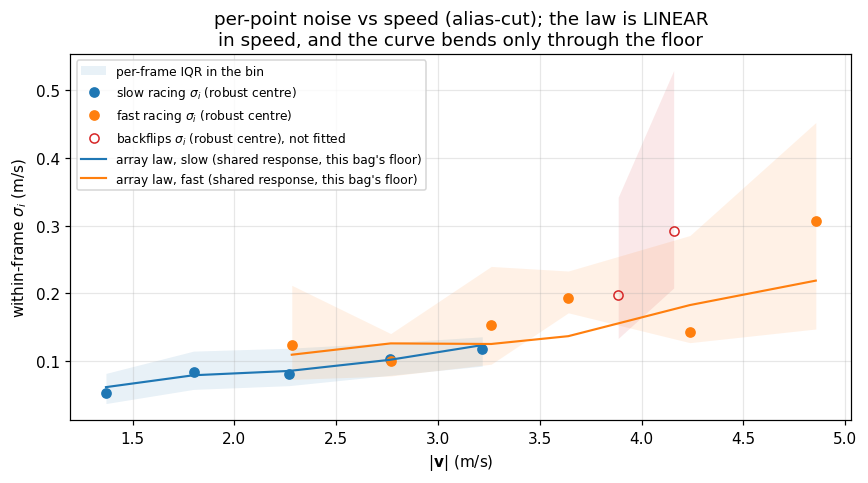

In [22]:
# 8b. The frame-level ladder: every candidate fitted jointly against the
#     per-frame sigma_i extracted above (alias-cut, both racing bags,
#     per-bag floors + one shared response).  Full versions:
#     analysis/characterize_speed_law.py (transfer) and
#     analysis/characterize_shape_contradiction.py (corrected statistics).
from scipy.optimize import least_squares

# ---- the form ladder: robust sigma-scale fits, per-bag floors + one shared
#      response over both racing bags (per-frame s_f is chi^2-tailed -> soft_l1)
#      Every lambda sees every covariate, so no rung is handicapped by which
#      arguments it was given.
SPECS = [
    ('floors only',            lambda p, om, v, rho, rs, ra: 0.0,                    []),
    ('rate-lin  +(c om)^2',    lambda p, om, v, rho, rs, ra: (p[0] * om)**2,         [0.03]),
    ('speed-lin +(a v)^2',     lambda p, om, v, rho, rs, ra: (p[0] * v)**2,          [0.05]),
    ('speed-quad +(q v^2)^2',  lambda p, om, v, rho, rs, ra: (p[0] * v**2)**2,       [0.02]),
    ('trans +(b v^2/rho)^2',   lambda p, om, v, rho, rs, ra: (p[0] * v**2 / rho)**2, [0.05]),
    ('speed-lin+quad',         lambda p, om, v, rho, rs, ra: (p[0]*v)**2 + (p[1]*v**2)**2,  [0.05, 0.01]),
    ('speed+rate',             lambda p, om, v, rho, rs, ra: (p[0]*v)**2 + (p[1]*om)**2,    [0.05, 0.02]),
    ('speed-quad+rate',        lambda p, om, v, rho, rs, ra: (p[0]*v**2)**2 + (p[1]*om)**2, [0.02, 0.02]),
    # A ray error of fixed rms angle projects onto this statistic as
    # a * v * rms_f(sin theta) -- the frame's own geometry, not a bare v.
    ('BEARING (a v rms_sin)^2', lambda p, om, v, rho, rs, ra: (p[0] * v * rs)**2,    [0.05]),
    ('bearing+speed-quad',     lambda p, om, v, rho, rs, ra: (p[0]*v*rs)**2 + (p[1]*v**2)**2, [0.05, 0.01]),
    # The same, with the ray error growing off boresight (derivation in the
    # cell above).  This is the rung the published ladder never offered.
    ('ARRAY (a v rms_arr)^2',  lambda p, om, v, rho, rs, ra: (p[0] * v * ra)**2,     [0.03]),
    ('array+speed-quad',       lambda p, om, v, rho, rs, ra: (p[0]*v*ra)**2 + (p[1]*v**2)**2, [0.03, 0.01]),
]

def fit_joint(tabs, fn, p0):
    keys = list(tabs)
    A = {k: np.array(tabs[k]) for k in keys}
    sig = np.concatenate([np.sqrt(A[k][:, 0]) for k in keys])
    col = lambda c: np.concatenate([A[k][:, c] for k in keys])
    om, v, rho, rs, ra = col(3), col(4), col(5), col(6), col(7)
    bag = np.concatenate([np.full(len(A[k]), i) for i, k in enumerate(keys)])
    def model(th):
        s0 = np.abs(th[bag.astype(int)])
        return np.sqrt(s0**2 + fn(np.abs(th[len(keys):]), om, v, rho, rs, ra))
    th0 = np.r_[[np.sqrt(np.median(A[k][:, 0])) for k in keys], p0]
    fsc = max(1.4826 * np.median(np.abs(sig - np.median(sig))), 1e-3)
    sol = least_squares(lambda th: model(th) - sig, th0, loss='soft_l1',
                        f_scale=fsc, max_nfev=40000)
    res = model(sol.x) - sig
    rss = float(np.sum(res**2)); n = len(sig); kk = len(th0)
    return dict(theta=np.abs(sol.x), r2=1 - rss / np.sum((sig - sig.mean())**2),
                bic=n * np.log(rss / n) + kk * np.log(n))

fits = {}
print(f"{'form':<24} {'R^2':>6} {'BIC':>9}   floors slow/fast | shared params")
for name, fn, p0 in SPECS:
    f = fit_joint({k: FRAMES_CUT[k] for k in racing}, fn, p0)
    fits[name] = f
    th = f['theta']
    print(f"{name:<24} {f['r2']:>6.3f} {f['bic']:>9.1f}   "
          + '/'.join(f'{x:.3f}' for x in th[:2]) + ' | '
          + '/'.join(f'{x:.4f}' for x in th[2:]))
print(f"\ndBIC(ARRAY - speed-quad) = "
      f"{fits['ARRAY (a v rms_arr)^2']['bic'] - fits['speed-quad +(q v^2)^2']['bic']:+.1f}"
      f"   dBIC(BEARING - speed-quad) = "
      f"{fits['BEARING (a v rms_sin)^2']['bic'] - fits['speed-quad +(q v^2)^2']['bic']:+.1f}"
      f"\n  (this soft-L1/Gaussian BIC is the PUBLISHED statistic and is not a"
      f" real BIC; rescored\n   by exact chi^2 ML and dof-weighted it gives"
      f" -210.1 and -37.8 for ARRAY, +13.2 and +5.3\n   for BEARING --"
      f" characterize_shape_contradiction.py --block 1b.  All three agree.)")

# bootstrap-over-frames 68% CI for the winner's coefficient
rng_bs = np.random.default_rng(0)
_ar = next(sp for sp in SPECS if sp[0].startswith('ARRAY'))
boots = []
for _ in range(200):
    tb = {}
    for k in racing:
        t = np.array(FRAMES_CUT[k])
        tb[k] = t[rng_bs.integers(0, len(t), len(t))]
    boots.append(fit_joint(tb, _ar[1], _ar[2])['theta'][2])
a_lo, a_hi = np.percentile(boots, [16, 84])
af = fits['ARRAY (a v rms_arr)^2']['theta']
a_hat = float(af[2])
print(f'\na = {a_hat:.4f} (68% CI [{a_lo:.4f}, {a_hi:.4f}]), floors '
      f'{af[0]:.3f}/{af[1]:.3f} m/s'
      f'  ->  boresight bearing error dphi_0 = sqrt(2)*a = '
      f'{np.degrees(a_hat*np.sqrt(2)):.2f} deg '
      f'[{np.degrees(a_lo*np.sqrt(2)):.2f}, {np.degrees(a_hi*np.sqrt(2)):.2f}]')

# flip-regime check: binned alias-cut sigma_i on backflips
def binned_si(A, col, edges, min_frames=8):
    """Per-bin ROBUST CENTRE of the per-frame sigma_i, plus its interquartile
    band.  This is deliberately the SAME statistic the fit targets (soft_l1 on
    per-frame sigma), so the fitted curve and these points are comparable.
    An RMS aggregate -- sqrt(mean within-frame variance) -- sits 1.2x (slow) to
    1.5x (fast) higher, because sigma_hat from 6-13 returns is chi-tailed; a
    robust fit plotted against an RMS aggregate appears to miss every point,
    which is a presentation artifact and not a bad fit."""
    out = []
    for a, b in zip(edges[:-1], edges[1:]):
        m = (A[:, col] >= a) & (A[:, col] < b)
        if m.sum() >= min_frames:
            s = np.sqrt(A[m, 0])
            out.append((A[m, col].mean(), np.median(s), np.percentile(s, 25),
                        np.percentile(s, 75), int(m.sum())))
    return np.array(out)
bf = np.array(FRAMES_CUT['backflips_best_velocity'])
bo = binned_si(bf, 3, np.array([3, 4, 5, 6, 7, 8, 9, 10, 11, 13]))
print('backflips alias-cut sigma_i vs |omega| bins (robust centre): '
      + '  '.join(f'{c:.1f}:{s:.2f}' for c, s, *_ in bo))

# supporting measured facts quoted by the text and the unfold box:
from scipy.stats import spearmanr
for k in racing:
    A = np.array(FRAMES_CUT[k])
    print(f'{SHORT[k]:<12} rank corr(|omega|, |v|) over frames: '
          f'{spearmanr(A[:, 3], A[:, 4]).statistic:+.2f}')
rq = np.sort(np.unique(np.concatenate(
    [np.linalg.norm(np.asarray(f.positions, float), axis=1)
     for f in D['fast_racing_best_velocity']['radar'] if f.positions is not None])))
drq = np.diff(rq); drq = drq[drq > 1e-6]
print(f'range quantization (unique reported ranges): {100*np.median(drq):.1f} cm')

# ---- figure: the law vs speed ----
V_EDGES_F = np.array([0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.5])
fig, ax0 = plt.subplots(figsize=(8.0, 4.5))
first = True
for key in BAG_KEYS:
    A = np.array(FRAMES_CUT[key]); fitted = key in racing
    b = binned_si(A, 4, V_EDGES_F)
    if len(b):
        ax0.fill_between(b[:, 0], b[:, 2], b[:, 3], color=COLOR[key],
                         alpha=0.10, lw=0,
                         label='per-frame IQR in the bin' if first else None)
        first = False
        ax0.plot(b[:, 0], b[:, 1], 'o', color=COLOR[key],
                 mfc=COLOR[key] if fitted else 'none',
                 label=f'{SHORT[key]} $\\sigma_i$ (robust centre)'
                       + ('' if fitted else ', not fitted'))
# The model curve is evaluated PER FRAME with that frame's own geometry and
# then aggregated over each bin exactly like the points above (median), so the
# line is the model's prediction OF THE PLOTTED STATISTIC rather than the law
# at some nominal geometry (see the reading note below).
for bi, (colr, nm) in enumerate([('tab:blue', 'slow'), ('tab:orange', 'fast')]):
    Ab = np.array(FRAMES_CUT[racing[bi]])
    pp = []
    for a, b in zip(V_EDGES_F[:-1], V_EDGES_F[1:]):
        m = (Ab[:, 4] >= a) & (Ab[:, 4] < b)
        if m.sum() >= 8:
            pred = np.sqrt(af[bi]**2 + (a_hat * Ab[m, 4] * Ab[m, 7])**2)
            pp.append((Ab[m, 4].mean(), np.median(pred)))
    if pp:
        pp = np.array(pp)
        ax0.plot(pp[:, 0], pp[:, 1], '-', color=colr, lw=1.4,
                 label=f"array law, {nm} (shared response, this bag's floor)")
ax0.set_xlabel('$|\\mathbf{v}|$ (m/s)')
ax0.set_ylabel('within-frame $\\sigma_i$ (m/s)')
ax0.set_title('per-point noise vs speed (alias-cut); the law is LINEAR\n'
              'in speed, and the curve bends only through the floor')
ax0.legend(fontsize=8)
fig.tight_layout()

**Reading the figure.** The points are the **robust centre** of the
per-frame $\sigma_i$ inside each speed bin, the shaded band their interquartile
range; the two curves are the fitted law -- one shared response, each bag's own
floor (0.050 / 0.085 m/s; merging them would assert equal floors, which is
false) -- evaluated **per frame with that frame's own geometry** and aggregated
over the same bins in the same way. So each curve is the model's prediction *of
the plotted statistic*, and the two are directly comparable. (An earlier version
also showed the same statistic against $|\omega|$; that confounded view is
retired -- the ladder hands rate a coefficient of exactly zero given speed, and
the unfold box below holds the rate law's post-mortem.)

That matters, because the obvious alternative is misleading. Aggregating each bin
as $\sqrt{\overline{\mathrm{var}}}$ instead -- an RMS -- lands 1.2x (slow) to 1.5x
(fast) higher, because $\hat\sigma_i$ estimated from 6-13 returns is
$\chi$-distributed with a long right tail. The fit deliberately targets a robust
centre (`soft_l1`, since that tail is a sampling artifact rather than signal), so
plotting a robust fit against an RMS aggregate makes the curve appear to sit below
every point. An earlier version of this figure did exactly that, and also drew the
curve at one nominal geometry rather than per frame. Both are fixed here; neither
affected the ladder's ranking, which scores every rung against the same objective
on the same data.

**Which mechanisms survived, at a glance.** Every candidate above is fitted
against the same statistic in the same joint fit, so this is one comparison
rather than a series of separate tests:

| candidate mechanism | its rung(s) | BIC | verdict |
|---|---|---|---|
| *(null)* floors only | — | $-1822.3$ | the bar everything must clear |
| **rotation / body rate** | $(c\,\lvert\omega\rvert)^2$ | $-1819.7$ | **dead** — worse than the null, and every joint fit drives its coefficient to zero |
| **range migration** (bare speed) | $(a\,v)^2$ | $-1880.6$ | clears the null, but loses to both geometry-aware forms |
| **temporal smear** (ray drift over $T_\mathrm{CPI}$) | $(q\,v^2)^2$, $(b\,v^2/\rho)^2$ | $-1908.9$ / $-1868.2$ | **survives** |
| **bearing error**, constant rms angle | $(a\,v\,\mathrm{rms}_f\sin\theta)^2$ | $-1900.4$ | **survives** |
| **bearing error**, growing off boresight | $(a\,v\,\mathrm{rms}_f(\sin\theta/\cos\phi))^2$ | $\mathbf{-1938.6}$ | **wins**, by $\Delta BIC -29.7$ over the best non-bearing form |

So rotation is eliminated outright and range migration is dominated. What is
*not* settled is the pair that matters: **temporal smear and bearing error both
survive**, because at the frame level they are genuinely hard to tell apart --
both are "noise that grows with dynamics", and a per-frame average hides the one
place they disagree. Separating them is what the per-return pass below does, and
it is why this section has a second half.

**How the numbers above are computed.** Protocol in the cell above; the one
modelling choice worth naming is per-bag floors against a single shared response,
because the floor $\sigma_0$ is scene- and range-dependent while the hypothesis
says the *dynamic response* is platform physics.

The array rung wins this ladder under all three scorings (printed above), and
the rate-linear form adds almost nothing over the floors: the joint speed+rate
fits drive the rate coefficient to zero at print precision, so BIC rejects the
extra parameter by exactly $\ln n$. Given speed, rotation explains no additional
per-point noise. What this pass cannot do is identify the *mechanism*, for the
reason given above.

**Why the fit uses the racing flights only**, and it is a property of the data
rather than of the result: the MoCap reference itself degrades under sustained
flips (markers occlude, which is why sec. 9 quotes robust percentiles of
$|\omega|$), and 38 % of backflip returns are aliased (sec. 4), leaving ~1000
usable returns against ~4500 for the two racing flights. Backflips is therefore
held out and used as a *transfer* test, which is the stronger use of it.

### 8b (continued). The law, resolved per return

The two still standing are **temporal smear** and **bearing error** -- the pass
above eliminated rotation and dominated range migration (verdict table), but
could not choose between these two, because at frame level both simply read as
"noise that grows with dynamics". They part company completely once the question
is asked per return: they predict sharply *different* patterns of how the noise
varies **within** a single frame, and a frame average is blind to exactly that.

**A bearing error, forced by algebra.** The reported ray carries an angular
error $\delta\mathbf u$, necessarily perpendicular to $\mathbf u$ (a unit
vector can only tilt). It enters the residual as
$-\delta\mathbf u^\top\mathbf v$, so only the component of $\mathbf v$
perpendicular to the ray survives, and that component has length
$|\mathbf v|\sin\theta_j$ with $\theta_j$ the angle between ray and velocity.
The error $\delta\mathbf u$ has two degrees of freedom (the tangent plane at
$\mathbf u$); write its total rms angle as $\delta\phi_j$ and split it
isotropically, $\delta\phi_j/\sqrt2$ per tangent direction. The transverse
velocity singles out *one* direction in that plane, so the residual picks up one
component:

$$ \sigma_j \;=\; \frac{\delta\phi_j}{\sqrt 2}\,|\mathbf v|\sin\theta_j
   \qquad\Rightarrow\qquad X_j = v\sin\theta_j $$

(that is the whole content of the $\sqrt2$: two error directions, one of which
matters).

Nothing is fitted in that step; it is what *any* ray error must look like in a
Doppler residual. It is also **not** the plain $|\mathbf v|$ shape the ladder
above tested and rejected: the $\sin\theta_j$ factor belongs there, and leaving
it out tests the wrong hypothesis.

**And $\delta\phi_j$ is not constant, for a derivable reason.** An array does
not resolve angles. It resolves **direction cosines**: the ray's components
along the array axes, which in this driver's frame are $s_y$ and $s_z$ with
$+x$ the boresight (a driver convention, `DataHandlerClass.cpp:633-635`, not a
property of how we mounted the module). A beamformer's resolution is constant
in those coordinates, and it is the map back to angle that stretches off
boresight. Take that as the primitive: a constant error $\sigma_u$ on
$(s_y, s_z)$, with the third component fixed by $|\mathbf s| = 1$,

$$ \delta s_x = -\frac{s_y\,\delta s_y + s_z\,\delta s_z}{s_x}. $$

The residual contribution of the ray error is
$r = -\delta\mathbf s^\top\mathbf v
   = -(\delta s_x v_x + \delta s_y v_y + \delta s_z v_z)$. Substitute
$\delta s_x$ from the constraint and group by the two *free* errors -- written
out, since the grouping is the whole step:

$$ r = \frac{s_y\,\delta s_y + s_z\,\delta s_z}{s_x}\,v_x
       - \delta s_y v_y - \delta s_z v_z
     = -\delta s_y\Big(v_y - \frac{s_y}{s_x}v_x\Big)
       - \delta s_z\Big(v_z - \frac{s_z}{s_x}v_x\Big) $$

in the sensor frame, exactly -- the last equality is just pulling the minus sign
out of each bracket. One constant, no chosen power, no free exponent.
Written back in angles it is the previous line with
$\delta\phi_j = \delta\phi_0/\cos\phi_j$ -- because constant resolution in a
direction cosine stretches in angle: in the azimuth slice $s_y = \sin\phi$, so
a fixed $\delta s_y$ is an angle error
$\delta\phi = \delta s_y/\cos\phi$, growing off boresight exactly as
$1/\cos\phi$:

$$ \sigma_j \;=\; \frac{\delta\phi_0}{\sqrt 2}\,
   \frac{|\mathbf v|\sin\theta_j}{\cos\phi_j},
   \qquad \phi_j = \text{angle off boresight.} $$

The two differ only by the ray-parallel component, which carries no
information, so both are fitted below and the data is allowed to say whether
that difference matters.

**Temporal smear**, the competing mechanism. The ray swings during the coherent
window, so the Doppler peak smears by the drift derived above integrated over
$T_\mathrm{CPI}$:

$$ \sigma \;=\; \kappa\,T_\mathrm{CPI}\,\frac{|\mathbf v|^2 \sin^2\theta_j}{\rho_j}
   \qquad\Rightarrow\qquad X_j = v^2\sin^2\theta_j/\rho_j $$

It is *quadratic* in speed and carries an explicit $1/\rho_j$, so per return it
is sharply separable from a bearing error even though at the frame level both
look like "noise that grows with dynamics".

The statistic is the reference-immune one: within-frame deviations, rescaled by
$\sqrt{1-1/N_f}$ so their spread estimates the per-point $\sigma_j$ itself
(subtracting a frame's own mean shrinks each deviation: its variance is
$\sigma^2(1-1/N_f)$, and the rescale undoes that).


per-point predictor                  R^2      coef   floors sl/fa   physical reading
sin only        (geometry)         0.828   0.09687  0.041/0.086     
v               (speed)            0.818   0.03639  0.000/0.024     
v cos = |v_r|   (SCALE)            0.414   0.00000  0.077/0.106     
v^2        (frame-level winner)    0.910   0.00966  0.055/0.064     
v^2 sin^2/rho   (SMEAR)            0.603   0.02029  0.076/0.104     kappa = coef/T_CPI = 0.41
v sin      (BEARING, flat)         0.935   0.04292  0.041/0.064     rms bearing error 3.5 deg at boresight
v sin/cos(phi)  (ARRAY)            0.979   0.02125  0.050/0.073     rms bearing error 1.7 deg at boresight
DIRCOS          (derived)          0.978   0.02975  0.041/0.065     rms bearing error 2.4 deg at boresight
(R^2 is WITHIN each model's own binning, so it is a descriptive, not a
 model comparison.  The ranking that scores every candidate on identical data is
 the pairwise composite likelihood in characterize_shape_contradiction.p

  sin(theta) > 0.4           3832   0.900   0.893   0.981   0.958  v sin/cos
  |v| < v_max (no alias)     3707   0.560   0.879   0.980   0.980  v sin/cos
  rho > 1 m                  4445   0.936   0.922   0.986   0.976  v sin/cos
  phi < 50 deg               2234   0.892   0.910   0.829   0.942  DIRCOS

Transfer to backflips (response frozen from racing, floor refit) -- the
section's own rule 4.  This is where the flat bearing law used to fail:
  v^2        (frame-level winner): floor 0.143 m/s, R^2 0.429
  v sin      (BEARING, flat): floor 0.151 m/s, R^2 0.164
  v sin/cos(phi)  (ARRAY)   : floor 0.202 m/s, R^2 0.311
  DIRCOS          (derived) : floor 0.193 m/s, R^2 0.370


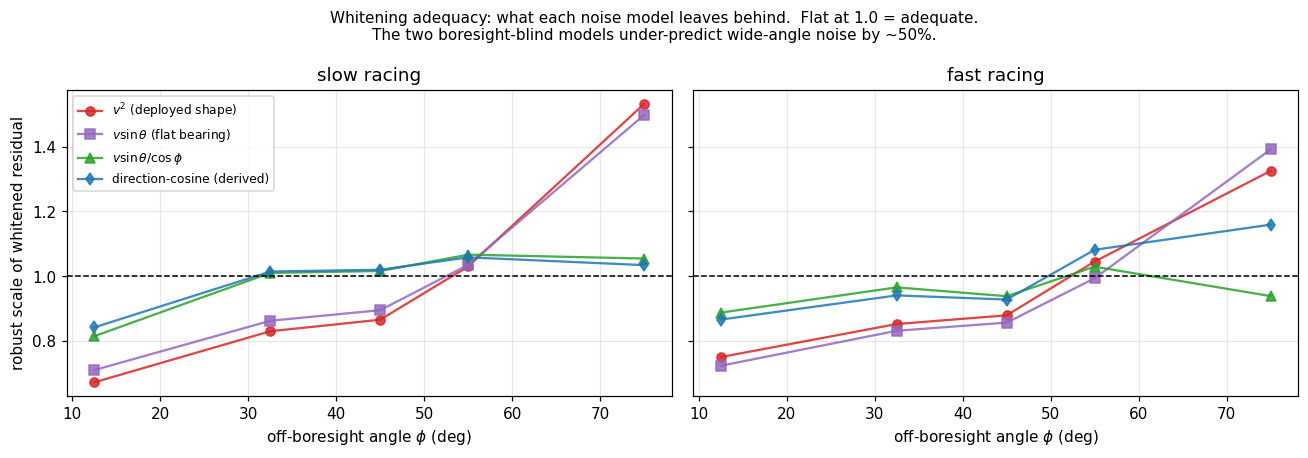

In [23]:
# 8b. Per-POINT ladder.  Same reference-immune statistic, but each return
# carries its own geometry instead of the frame's.  Two things the frame-level
# pass structurally could not do: separate sin(theta_j) from the frame average,
# and see the off-boresight angle phi_j at all.
# Full version with a second independent estimator (within-frame pairwise
# composite likelihood) and seven confounder controls:
# analysis/characterize_pointwise_noise.py, characterize_shape_contradiction.py
from scipy.optimize import least_squares as _ls

T_CPI = HEAD['t_cpi']          # 49.92 ms, from the chirp config (section 1)

def point_table(key):
    d = D[key]
    keep0 = (np.abs(d['r'] - np.median(d['r'])) < 6 * robust_sigma(d['r'])) \
        & ~d['aliased']
    v_i = interp1d(d['st_t'], np.array([s.velocity for s in d['states']]),
                   axis=0, kind='linear', bounds_error=False,
                   fill_value='extrapolate')
    q_i = interp1d(d['st_t'], np.array([s.orientation for s in d['states']]),
                   axis=0, kind='linear', bounds_error=False,
                   fill_value='extrapolate')
    out = {k: [] for k in ('d', 'v', 'sin2', 'rho', 'sx', 'sy', 'sz',
                           'vsx', 'vsy', 'vsz')}
    for f in np.unique(d['fi']):
        m = (d['fi'] == f) & keep0
        n = int(m.sum())
        if n < 6:
            continue
        fr = d['radar'][int(f)]
        t_f = fr.timestamp + RADAR_OFF
        v_b = quat_to_rotation_matrix(q_i(t_f)).T @ v_i(t_f)
        nv = np.linalg.norm(v_b)
        if nv < 0.2:
            continue
        P = np.asarray(fr.positions, float)[d['pi'][m]]
        rho = np.linalg.norm(P, axis=1)
        s_j = P / np.maximum(rho, 1e-6)[:, None]     # unit ray, SENSOR frame
        u_b = (R_BS @ s_j.T).T                       # the same ray, body frame
        v_s = R_BS.T @ v_b                           # velocity in the SENSOR frame
        out['sin2'].append(np.clip(1 - (u_b @ v_b / nv) ** 2, 0, 1))
        out['rho'].append(np.maximum(rho, 0.3))
        out['v'].append(np.full(n, nv))
        for c, nm in zip(range(3), ('sx', 'sy', 'sz')):
            out[nm].append(s_j[:, c])
        for c, nm in zip(range(3), ('vsx', 'vsy', 'vsz')):
            out[nm].append(np.full(n, v_s[c]))
        out['d'].append((d['r'][m] - d['r'][m].mean()) / np.sqrt(1 - 1 / n))
    return {k: np.concatenate(v) for k, v in out.items()}

PT = {k: point_table(k) for k in BAG_KEYS}
RACING2 = ['slow_racing_best_velocity', 'fast_racing_best_velocity']
CPHI_FLOOR = 0.15              # = 81.4 deg; a numerical guard, not a fit --
                               # it binds on 1.5% / 1.9% / 0.5% of returns

def pred_X(T):
    s1 = np.sqrt(T['sin2'])
    c1 = np.sqrt(np.clip(1 - T['sin2'], 0, 1))
    cphi = np.maximum(T['sx'], CPHI_FLOOR)
    # DIRCOS: a constant error on the two direction cosines the array actually
    # resolves, with the third component fixed by |s| = 1.  Nothing to choose.
    dc = np.sqrt((T['vsy'] - T['sy'] * T['vsx'] / cphi) ** 2
                 + (T['vsz'] - T['sz'] * T['vsx'] / cphi) ** 2)
    return {
        'sin only        (geometry)': (s1, None),
        'v               (speed)   ': (T['v'], None),
        'v cos = |v_r|   (SCALE)   ': (T['v'] * c1, None),
        'v^2        (frame-level winner)': (T['v'] ** 2, None),
        'v^2 sin^2/rho   (SMEAR)   ': (T['v'] ** 2 * T['sin2'] / T['rho'], 'smear'),
        'v sin      (BEARING, flat)': (T['v'] * s1, 'bearing'),
        'v sin/cos(phi)  (ARRAY)   ': (T['v'] * s1 / cphi, 'bearing'),
        'DIRCOS          (derived) ': (dc, 'bearing'),
    }

def fit_pt(Xs, tabs, n_bins=10, min_n=120):
    c, s, b = [], [], []
    for bi, k in enumerate(tabs):
        X, T = Xs[k], tabs[k]
        ed = np.unique(np.percentile(X, np.linspace(0, 100, n_bins + 1)))
        for lo, hi in zip(ed[:-1], ed[1:]):
            m = (X >= lo) & (X < hi)
            if m.sum() >= min_n:
                c.append(X[m].mean()); s.append(robust_sigma(T['d'][m])); b.append(bi)
    c, s, b = np.array(c), np.array(s), np.array(b, int)
    nb = len(tabs)
    mdl = lambda th: np.sqrt(np.abs(th[b]) ** 2 + (np.abs(th[nb]) * c) ** 2)
    th0 = np.r_[[np.median(s)] * nb, [1e-3]]
    fsc = max(1.4826 * np.median(np.abs(s - np.median(s))), 1e-4)
    sol = _ls(lambda th: mdl(th) - s, th0, loss='soft_l1', f_scale=fsc,
              max_nfev=40000)
    r = mdl(sol.x) - s
    return np.abs(sol.x), 1 - float(r @ r) / float(((s - s.mean()) ** 2).sum())

tabs2 = {k: PT[k] for k in RACING2}
COEF = {}
print(f"{'per-point predictor':<32} {'R^2':>7} {'coef':>9} {'floors sl/fa':>14}"
      f"   physical reading")
for name in pred_X(PT[RACING2[0]]):
    Xs = {k: pred_X(PT[k])[name][0] for k in RACING2}
    kind = pred_X(PT[RACING2[0]])[name][1]
    th, r2 = fit_pt(Xs, tabs2)
    COEF[name] = th
    rd = ''
    if kind == 'bearing':
        rd = f'rms bearing error {np.degrees(th[2]*np.sqrt(2)):.1f} deg at boresight'
    elif kind == 'smear':
        rd = f'kappa = coef/T_CPI = {th[2]/T_CPI:.2f}'
    print(f'{name:<32} {r2:>7.3f} {th[2]:>9.5f} {th[0]:>6.3f}/{th[1]:<7.3f}   {rd}')
print('(R^2 is WITHIN each model\'s own binning, so it is a descriptive, not a'
      '\n model comparison.  The ranking that scores every candidate on'
      ' identical data is\n the pairwise composite likelihood in'
      ' characterize_shape_contradiction.py --block 1a.)')

# ---- the adequacy test: whiten by each model and see what structure is left.
# A ranking can be argued with; a residual that still trends cannot.
print()
print('WHITENING.  robust scale of d_j / sigma_j(model), binned by the'
      ' off-boresight angle phi.')
print('A correct model gives 1.00 in every bin.  This is the test neither'
      ' ladder ran.')
PHI_E = np.array([0, 25, 40, 50, 60, 90])
WH = {}
for name in ('v^2        (frame-level winner)', 'v sin      (BEARING, flat)',
             'v sin/cos(phi)  (ARRAY)   ', 'DIRCOS          (derived) '):
    th = COEF[name]
    for bi, k in enumerate(RACING2):
        X = pred_X(PT[k])[name][0]
        w = PT[k]['d'] / np.sqrt(th[bi] ** 2 + (th[2] * X) ** 2)
        phi = np.degrees(np.arccos(np.clip(PT[k]['sx'], -1, 1)))
        cells = []
        for lo, hi in zip(PHI_E[:-1], PHI_E[1:]):
            m = (phi >= lo) & (phi < hi)
            cells.append(robust_sigma(w[m]) if m.sum() >= 60 else np.nan)
        WH[(name, k)] = np.array(cells)
        good = np.array(cells)[~np.isnan(cells)]
        print(f'  {name[:26]:<27} {SHORT[k]:<12} '
              + ' '.join(f'{c:.2f}' for c in cells)
              + f'   spread {good.max()/good.min():.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
cen = 0.5 * (PHI_E[:-1] + PHI_E[1:])
STY = {'v^2        (frame-level winner)': ('tab:red', 'o-', '$v^2$ (deployed shape)'),
       'v sin      (BEARING, flat)': ('tab:purple', 's-', '$v\\sin\\theta$ (flat bearing)'),
       'v sin/cos(phi)  (ARRAY)   ': ('tab:green', '^-', '$v\\sin\\theta/\\cos\\phi$'),
       'DIRCOS          (derived) ': ('tab:blue', 'd-', 'direction-cosine (derived)')}
for ax, k in zip(axes, RACING2):
    for name, (colr, mk, lab) in STY.items():
        ax.plot(cen, WH[(name, k)], mk, color=colr, label=lab, alpha=0.85)
    ax.axhline(1.0, color='k', lw=1, ls='--')
    ax.set_xlabel('off-boresight angle $\\phi$ (deg)')
    ax.set_title(SHORT[k])
axes[0].set_ylabel('robust scale of whitened residual')
axes[0].legend(fontsize=8)
fig.suptitle('Whitening adequacy: what each noise model leaves behind.  Flat at'
             ' 1.0 = adequate.\nThe two boresight-blind models under-predict'
             ' wide-angle noise by ~50%.', fontsize=10)
fig.tight_layout()

# ALL FOUR support restrictions, not just the flattering one.
print()
print('Robustness of the ranking to support restrictions:')
print(f"  {'restriction':<24} {'n':>6} {'v^2':>7} {'bearing':>8} {'ARRAY':>7}"
      f" {'DIRCOS':>7}  winner")
RESTRICT = [
    ('all points', lambda T: np.ones(len(T['v']), bool)),
    ('sin(theta) > 0.2', lambda T: T['sin2'] > 0.04),
    ('sin(theta) > 0.4', lambda T: T['sin2'] > 0.16),
    ('|v| < v_max (no alias)', lambda T: T['v'] < 3.136),
    ('rho > 1 m', lambda T: T['rho'] > 1.0),
    ('phi < 50 deg', lambda T: T['sx'] > np.cos(np.radians(50))),
]
CMP = ['v^2        (frame-level winner)', 'v sin      (BEARING, flat)',
       'v sin/cos(phi)  (ARRAY)   ', 'DIRCOS          (derived) ']
for label, fn_r in RESTRICT:
    sb = {k: {kk: vv[fn_r(PT[k])] for kk, vv in PT[k].items()} for k in RACING2}
    r2s = {}
    for name in CMP:
        Xs = {k: pred_X(sb[k])[name][0] for k in RACING2}
        r2s[name] = fit_pt(Xs, sb)[1]
    win = max(CMP, key=lambda n: r2s[n])
    print(f'  {label:<24} {sum(len(sb[k]["d"]) for k in RACING2):>6} '
          + ' '.join(f'{r2s[n]:>7.3f}' for n in CMP)
          + f'  {win.split("(")[0].strip()}')

# and the section's own rule 4: does the winner TRANSFER to the held-out regime?
print()
print('Transfer to backflips (response frozen from racing, floor refit) -- the')
print("section's own rule 4.  This is where the flat bearing law used to fail:")
for name in CMP:
    coef = COEF[name][2]
    T = PT['backflips_best_velocity']
    X = pred_X(T)[name][0]
    ed = np.unique(np.percentile(X, np.linspace(0, 100, 9)))
    c, s = [], []
    for lo, hi in zip(ed[:-1], ed[1:]):
        m = (X >= lo) & (X < hi)
        if m.sum() >= 60:
            c.append(X[m].mean()); s.append(robust_sigma(T['d'][m]))
    c, s = np.array(c), np.array(s)
    sol = _ls(lambda p: np.sqrt(p[0]**2 + (coef * c)**2) - s, [0.3],
              loss='soft_l1', max_nfev=20000)
    rss = float(np.sum((np.sqrt(sol.x[0]**2 + (coef * c)**2) - s)**2))
    tss = float(((s - s.mean())**2).sum())
    print(f'  {name}: floor {abs(sol.x[0]):.3f} m/s, R^2 {1 - rss/tss:.3f}')


**Finding (8b).** The per-return Doppler noise is a **bearing error**, and it is
**linear in speed**:

$$ \sigma_j \;=\; \frac{\delta\phi_0}{\sqrt 2}\,
   \frac{|\mathbf v|\sin\theta_j}{\cos\phi_j},
   \qquad \delta\phi_0 \approx 2^\circ \text{ rms at boresight.} $$

Four results carry it, in order of weight.

**1. The off-boresight factor is where the entire discrimination lives, and it
takes a whitening test to see that.** Every table in this section so far ranks
models, and a ranking can be argued with. Dividing each deviation by the
$\sigma_j$ its model predicts and asking what structure is left cannot be:

| model | robust scale of $d/\sigma$ across $\phi$ (12/32/45/55/75 deg), slow racing | spread |
|---|---|---|
| $v^2$ | 0.67 0.83 0.87 1.03 **1.53** | 2.27x |
| $v\sin\theta$ (flat bearing) | 0.71 0.86 0.90 1.04 **1.50** | 2.11x |
| $v\sin\theta/\cos\phi$ | 0.82 1.01 1.02 1.07 1.05 | **1.31x** |
| direction-cosine (derived) | 0.84 1.01 1.02 1.06 1.03 | **1.26x** |

The two boresight-blind models leave a **monotone** factor-2 trend: they
under-predict wide-angle noise by ~50 % while over-predicting boresight noise by
~30 %. Fast racing gives 1.76 / 1.92 / 1.16 / 1.34 with the same ordering, on an
independent recording. In the speed and $\sin\theta$ strata all four models sit
between 1.2x and 1.7x, so those directions separate nothing. This is also the
one place a reader can check the model without trusting a selection criterion.

**2. Given that factor, the frame-level pass agrees, and the contradiction
dissolves.** An earlier version of this section reported that its two halves
selected different shapes and left the question open. They never disagreed about
speed. The frame-level ladder had no rung carrying a per-return geometry factor,
so it picked whichever frame-level shape best absorbed the geometry it could not
see, and that was $v^2$. Given the rung, the same statistic on the same frames
prefers the v-linear law by $\Delta$BIC $-29.7$, and by $-210.1$ / $-37.8$ under
the two scorings that are actually valid. Free-exponent fits
$\sigma_j^2 = \sigma_0^2 + a^2v^{2p}\sin^{2q}$ put $p = 1.0$ on both statistics
and both scale estimators, with $p = 2$ outside every bootstrap interval
(`characterize_shape_contradiction.py --block 2`).

**3. The scale-error control is an exact null.** $|v_r| = v\cos\theta$ takes
coefficient $0.00000$ and a likelihood identical to floors-only. The noise
scales with the *transverse* velocity, never with the measured radial one. That
is precisely what a ray-direction error does and precisely what a Doppler
scale error cannot do, and no flexible-shape artifact would produce it.

**4. The smear mechanism does not survive per return.** Its predicted
$v^2\sin^2\theta/\rho$ sits near the bottom ($R^2$ 0.603 against 0.978), and the
$1/\rho$ factor makes the fit actively worse, robustly across range clamps.
Section 1's CPI is still the right number and smear is still real physics; it is
simply not the dominant term.

**What is *not* settled: which member of the family.** $1/\cos\phi$, $\phi^2$ and
the exactly-derived direction-cosine form separate by at most ~600 in likelihood
against a 4000-7000 margin over anything with no boresight term at all; they
trade places across seven confounder controls and six held-out flights, and the
ranking between them even flips depending on whether the tail is trimmed. The
*family* is established. The *member* is not, and this section does not claim
one. The derived form is the one quoted because it has no shape left to fit.

**The flip regime is the honest exception.** With the response frozen on racing
and only the floor refit, transfer to backflips gives $R^2$ 0.43 for $v^2$, 0.16
for the flat bearing law, 0.31 and 0.37 for the boresight forms. So the
boresight factor repairs most of the flat bearing law's failure there, but under
*this* binned statistic $v^2$ still transfers best to flips; under the pairwise
likelihood the boresight family beats it (`--block 4`). The two estimators
disagree only in the flip regime, which is also where the locally refit
$\delta\phi_0$ is 5.6 deg, 2.6x the racing value. Sustained flips are a
different error regime, not a harder version of the same one.

**Which number, and how uncertain.** The constant is measured five ways:
1.65 deg (frame-level fit, bootstrap CI 1.55-1.78); 1.7 deg and 2.4 deg (the
`sin/cos` and direction-cosine forms under the binned robust estimator); and
under the per-point pairwise likelihood 2.12 deg for `sin/cos` and **2.67 deg for
the derived form**, which is the one this section quotes. Take
$\approx 2^\circ$ with a **1.65-2.7 deg** spread, dominated by the choice of
estimator and form rather than by sampling -- and note that the headline
$2^\circ$ sits below the derived form's own primary-estimator value. It is also an **upper bound**: a *coherent* mounting-rotation error produces the
identical $|\mathbf v|\sin\theta$ law, and fitting one absorbs 19.9 % of the
slow-racing per-point variance at a radar yaw of $+3.2^\circ$
(`characterize_reference_immunity_bound.py`). Removing it drops $\delta\phi_0$ to
1.86 deg. The bags disagree on that value so it is not one clean mounting error,
but the solver never estimates radar roll or yaw
(`optimize_pitch_only: true`), so whatever is real there is an uncalibrated
accuracy lever rather than sensor noise.

**From noise law to weight law.** The measured noise adds to the floor in
quadrature (independent error sources), $\sigma_j^2 = \sigma_0^2 +
(\sigma_u q_j)^2$ with $q_j$ the derived transverse term below. Inverse-variance
weighting, normalized so a boresight low-speed return ($q_j = 0$) has weight 1:

$$ w_j = \frac{\sigma_0^2}{\sigma_j^2}
       = \frac{1}{1 + \big(\sigma_u\,q_j/\sigma_0\big)^2},
  \qquad
  q_j^2 = \Big(v_y - \tfrac{s_y}{s_x}v_x\Big)^2
        + \Big(v_z - \tfrac{s_z}{s_x}v_x\Big)^2 $$

with $\mathbf v$ and $\mathbf s$ in the sensor frame. Both inputs are causal and
already in the solver: $\mathbf s_j$ is the return's own direction, free; the
ego-velocity comes from the frame's own consensus, whose accuracy was measured at
0.05-0.13 m/s robust $\sigma$ against MoCap on the racing flights (recorded in
`validate_live_solver.py`'s `--speed-weight` derivation note; not printed by any
cell here). Being
per-point rather than per-frame, this weight down-weights the *wide-angle*
returns of a fast frame while keeping its boresight returns, which the deployed
configuration does not do.

**Does the weight it implies actually help? That is a deployment question,
and it is answered in section 11's ledger, not here.** The short version, now
complete: gate-tested on eight flights 2026-08-06 and **rejected** (velocity
improved everywhere, orientation regressed off the fit set); the cost was
then located as a **composition defect** rather than a property of the law
(the scalar weight against the along-$\mathbf 1$ whitening; the ledger
addendum has the mechanism); composed through the exact per-frame covariance,
with the raw-detection flight's duplicate returns collapsed, it passes the
same eight flights with NEES and **is the deployed radar model since
2026-08-12**. Under a correctly specified model an inverse-variance weight
built from a correct noise model cannot cost accuracy; that this one did, and
stopped doing so once the composition was fixed, is the strongest end-to-end
evidence the notebook has that the law itself is right. Part I owes the
measurement and its uncertainty; the deployment record is section 11's.

<details>
<summary><b>Unfold: every candidate that was offered and failed</b></summary>

> **1. The rate law $w = 1/(1+(|\omega|/4.5)^2)$** was the deployed weighting
> until 2026-08. Two roots, both corrected in this notebook:
>
> - *A frame-inconsistent derivation.* The "rotational Doppler smear" hypothesis
>   differentiated $v_r = -\mathbf{u}^\top\mathbf{v}$ in the body frame while
>   holding $\mathbf{v}$ fixed. The co-rotation of the velocity cancels the
>   resulting rate term exactly: in the body frame the ray rotates as
>   $-\boldsymbol\omega\times\mathbf{u}$, giving an apparent
>   $\boldsymbol\omega^\top(\mathbf{u}\times\mathbf{v})$, while the co-rotation
>   $\dot{\mathbf{v}}_b = -\boldsymbol\omega\times\mathbf{v}_b$ contributes
>   $-\boldsymbol\omega^\top(\mathbf{u}\times\mathbf{v})$ and the two cancel,
>   leaving $dv_r/dt = |\mathbf{v}|^2\sin^2\theta/\rho$ with no rotation in it.
>   Rotation does not smear the Doppler of a static scene at all.
> - *An envelope confound.* Body rate and speed rise together on these flights
>   (rank correlation $\approx +0.5$, printed in the fit cell), so binning
>   $\sigma_i$ by $|\omega|$ inherited the speed effect. The rate law fitted the
>   flight envelope, not a mechanism.
>
> The demonstration is in the data, not in the argument: the ladder lets both
> variables compete and the joint speed+rate fits drive the rate coefficient to
> zero at print precision, the alias-cut backflips bins are flat in $|\omega|$
> across 4.8-10.5 rad/s while still tracking speed, and the speed response transfers
> with frozen parameters (fast2 $R^2$ 0.29, ICINS 0.11-0.17) where the rate
> response transfers nowhere (0.01-0.06).
>
> **2. The coherent-integration smear** $\sigma = \kappa T_\mathrm{CPI}
> |\mathbf v|^2\sin^2\theta/\rho$ was the leading mechanism for most of this
> work's history, and at the frame level it looked confirmed twice over: the
> quadratic shape won the ladder, and the model's *predicted* coefficient
> $q_\mathrm{pred} = T_\mathrm{CPI}\,\mathrm{rms}(\sin^2\theta/\rho)$ landed
> within 10 % of the fitted $q = 0.0104$ at unit processing factor. Resolved per
> return the prediction fails outright ($R^2$ 0.603, and the $1/\rho$ it predicts
> makes the fit worse). The coefficient agreement was numerology: an average over
> geometry, of the wrong law, happening to have the right magnitude.
>
> **3. The speed-quadratic law $\sigma^2 = \sigma_0^2 + (qv^2)^2$,
> $q = 0.0104$**, and the weight $w = 1/(1+(|\mathbf v|/2.81)^4)$ built from it,
> were what the frame-level ladder selected and what
> `--speed-weight auto` deploys today. The shape is retracted here: it won only
> because no rung in that ladder carried a per-return geometry factor, and free
> exponents on the same statistic put the speed exponent at 1, not 2. The
> deployed weight's *end-to-end record* is unaffected by this (section 11
> measured it against the alternatives it was compared with); what is retracted
> is the claim that it is the measured noise law.
>
> **4. The flat bearing law $\sigma = (\delta\phi/\sqrt2)|\mathbf v|\sin\theta$
> with $\delta\phi = 3.5^\circ$** is the immediately preceding version of this
> section's finding. It is right about the mechanism and wrong about the
> constant, because it attributes to a fixed ray error what is partly a ray error
> that grows off boresight. Its three recorded weaknesses were the frame-level
> test disagreeing, the ranking reversing under two support restrictions, and the
> poor transfer to flips. The first vanishes. The other two do not -- they move
> onto the *new* winner: at $\phi < 50^\circ$ the adopted
> $v\sin\theta/\cos\phi$ scores 0.829, below both the retracted $v^2$ (0.892) and
> the flat bearing law (0.910), printed in the restriction table two cells up.
> (There is a defence: restricting to $\phi < 50^\circ$ removes most of the
> variation in $1/\cos\phi$, so the factor cannot help and, refit inside the
> restriction, can hurt. That is a defence, not a disappearance.) And the flip
> transfer is unchanged under that statistic, $v^2$ 0.429 against 0.311/0.370.
>
> **What rotation still does.** Aggressive rotation produces aliasing (the
> $|v_r|$ swings cross $v_\mathrm{max}$), handled per point in section 4; it
> sweeps the bearing during the window, but bearing errors enter the residual
> scaled by speed; and the accelerometer keeps its rate gate (8e). Rate left the
> radar per-point channel entirely.


> **Where this sits in the literature.** the bearing channel has recent company: Xu et al. (RA-L 2025) propagate polar
> point noise into the Doppler residual via a Jacobian, and Babgei et al. (2026)
> give the angular covariance term the same $\|\mathbf v\|$-linear scaling this law
> measures. Neither *measures* the constant -- one takes it from a datasheet and
> fine-tunes it on the TI single-chip data, the other fixes it from configuration.
> The measured, estimator-free $\delta\phi_0$, and the finding that it *dominates*
> on this device, are what is new here.

</details>


In [24]:
# 8c. Two traps between the measured curves and usable weights. The obvious
#     move is lambda = 1/sigma^2 with sigma read straight off 8a/8b. It fails
#     for two measured reasons, quantified here:
#     (i) returns within a frame are correlated (sigma_c > 0) -> a frame
#         carries far fewer independent measurements than points,
#     (ii) most IMU residual power lies above the spline band -> the raw sigma
#         overstates the noise the spline actually has to absorb.
#     Adapted from analysis/characterize_frame_correlation.py.
print(f"{'bag':<14} {'sigma_i':>8} {'sigma_c':>8} {'rho':>6} {'N':>5} {'N_eff':>6}   "
      f"{'gyro raw':>9} {'in-band':>8}")
for key in BAG_KEYS:
    d = D[key]
    frames = FRAMES[key]          # extracted in 8b
    wi = np.array([v[0] for v in frames]); mu = np.array([v[1] for v in frames])
    ns = np.array([v[2] for v in frames])
    s_i2 = np.mean(wi)
    s_c2 = max(np.var(mu, ddof=1) - s_i2 / np.mean(ns), 0.0)
    rho = s_c2 / (s_c2 + s_i2)
    N = np.mean(ns)
    n_eff = N / (1 + (N - 1) * rho)   # Kish design effect
    # in-band (10 Hz low-pass) gyro residual vs raw
    t_imu = np.array([m.timestamp for m in d['imu']]) + IMU_OFF
    g_res = np.array([m.angular_velocity for m in d['imu']]) - d['om_interp'](t_imu)
    g_res -= np.median(g_res, axis=0)
    fs = 1.0 / np.median(np.diff(t_imu))
    b, a = butter(2, 10.0 / (fs / 2), btype='low')
    g_lp = filtfilt(b, a, g_res, axis=0)
    print(f'{SHORT[key]:<14} {np.sqrt(s_i2):>8.3f} {np.sqrt(s_c2):>8.3f} '
          f'{rho:>6.2f} {N:>5.1f} {n_eff:>6.1f}   '
          f'{robust_sigma(g_res.ravel()):>9.3f} {robust_sigma(g_lp.ravel()):>8.3f}')


bag             sigma_i  sigma_c    rho     N  N_eff    gyro raw  in-band
slow racing       0.109    0.058   0.22  13.3    3.6       0.150    0.024
fast racing       0.291    0.088   0.08  12.6    6.4       0.209    0.051
backflips         0.460    0.119   0.06  12.1    7.1       0.335    0.224


**Where $\rho$ comes from.** The 8b decomposition already fixes the
correlation structure: two returns of the same frame share $c_f$, so for $j \ne k$

$$ \operatorname{Cov}(r_{fj}, r_{fk}) = \sigma_c^2, \qquad
   \operatorname{Var}(r_{fj}) = \sigma_i^2 + \sigma_c^2
   \quad\Rightarrow\quad
   \rho = \frac{\sigma_c^2}{\sigma_i^2 + \sigma_c^2} $$

The measured $\sigma_c/\sigma_i = 0.26$-$0.53$ maps to $\rho = 0.06$-$0.22$.
Those are **raw-stream** numbers. On the post-prefilter stream the solver
actually consumes, the same ratio is 0.47-0.98 and $\rho = 0.18$-$0.49$ across
eight flights -- not a contradiction but a stream difference, and 8d shows it is
the *denominator* that moves ($\sigma_c$ is stream-stable, $\sigma_i$ is not).

Carried through Kish, that is the sharper statement: on the deployed stream a
frame carries **2.0-4.4 independent measurements while $N$ ranges 9 to 53**. The
saturation at $1/\rho$ is not a limit approached asymptotically, it is where
these frames already sit -- ICINS's 50-return frames carry *fewer* independent
measurements (2.0-2.6) than our 10-return racing frames (2.9-3.8). More returns
per frame buy almost nothing.

**Why correlation destroys averaging (Kish).** The mean of $N$ equicorrelated
measurements has variance

$$ \operatorname{Var}(\bar r) = \frac{\sigma^2}{N}\bigl(1+(N-1)\rho\bigr)
   \;\equiv\; \frac{\sigma^2}{N_\mathrm{eff}}, \qquad
   N_\mathrm{eff} = \frac{N}{1+(N-1)\rho} $$

For $\rho > 0$, $N_\mathrm{eff}$ saturates at $1/\rho$ no matter how many returns
the frame has: the shared part of the error cannot be averaged away. At the measured
$\rho$, a 13-return frame carries 3.6-7.1 independent measurements, not 13.
(Convention note: this Kish $N_\mathrm{eff}$ is defined on the total variance;
8d's information form $N/(1+N\sigma_c^2/\sigma_i^2)$ differs by the factor
$(\sigma_i^2+\sigma_c^2)/\sigma_i^2$. Same saturation, two normalizations.)

**Why the raw IMU $\sigma$ is the wrong $\sigma$.** The spline can only follow
motion up to a bandwidth set by the knot spacing and regularization; residual power
above that band belongs to vibration the trajectory estimate neither can nor should
track. The protocol takes a 10 Hz second-order Butterworth low-pass as the band edge
(the flight dynamics of these bags live below it) and measures the residual inside
the band: for the gyro, $\sigma_\mathrm{in} = 0.024$ rad/s against $0.15$ raw, a
factor 6 in $\sigma$ and $\approx 40$ in information ($\sigma^2$).



whole-flight aggregates sigma_c/sigma_i:  slow racing 0.53,  fast racing 0.30,  backflips 0.26


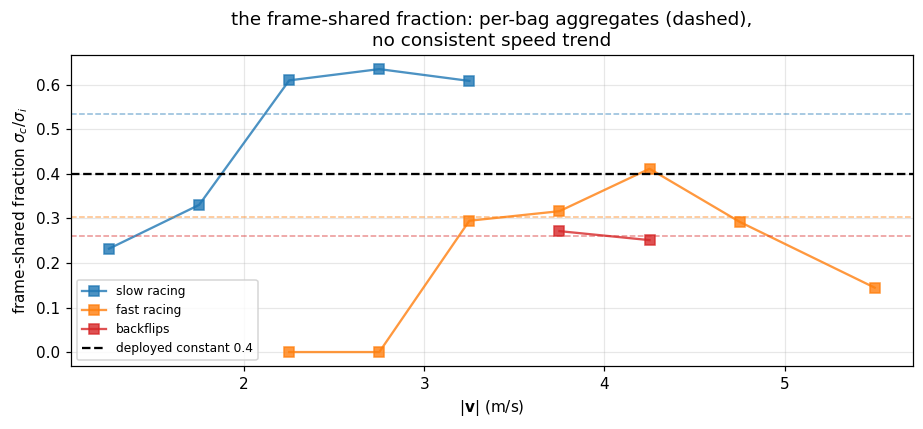

In [25]:
# The frame-shared fraction sigma_c/sigma_i vs speed: does the shared error
# have a dynamics law of its own?  (FRAMES from the 8b extraction cell; all
# kept returns, not alias-cut -- the shared error belongs to the whole frame.)
def bin_comps(sel):
    s_i2 = sel[:, 0].mean()
    s_c2 = max(np.var(sel[:, 1], ddof=1) - s_i2 / sel[:, 2].mean(), 0.0)
    return np.sqrt(s_i2), np.sqrt(s_c2)

agg_ratio = {}
for k in BAG_KEYS:
    s_i, s_c = bin_comps(np.array(FRAMES[k]))
    agg_ratio[k] = s_c / max(s_i, 1e-9)
V_EDGES_C = np.array([0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0])
fig2, ax = plt.subplots(figsize=(8.5, 4))
for k in BAG_KEYS:
    A = np.array(FRAMES[k])
    pts = []
    for a, b in zip(V_EDGES_C[:-1], V_EDGES_C[1:]):
        m = (A[:, 4] >= a) & (A[:, 4] < b)
        if m.sum() >= 8:
            s_i, s_c = bin_comps(A[m])
            pts.append((0.5 * (a + b), s_c / max(s_i, 1e-9)))
    if pts:
        Pn = np.array(pts)
        ax.plot(Pn[:, 0], Pn[:, 1], 's-', color=COLOR[k], alpha=0.8,
                label=SHORT[k])
    ax.axhline(agg_ratio[k], color=COLOR[k], ls='--', lw=1, alpha=0.5)
ax.axhline(0.4, color='k', ls='--', lw=1.5, label='deployed constant 0.4')
ax.set_xlabel('$|\\mathbf{v}|$ (m/s)')
ax.set_ylabel('frame-shared fraction $\\sigma_c/\\sigma_i$')
ax.set_title('the frame-shared fraction: per-bag aggregates (dashed),\n'
             'no consistent speed trend')
ax.legend(fontsize=8)
fig2.tight_layout()
print('whole-flight aggregates sigma_c/sigma_i:  '
      + ',  '.join(f'{SHORT[k]} {agg_ratio[k]:.2f}' for k in BAG_KEYS))

**Finding (the frame-shared fraction).** $\sigma_c/\sigma_i$ obeys no dynamics
law: the whole-flight aggregates differ by 2x across bags (0.53 / 0.30 / 0.26)
and the per-bin values scatter in a 0.1-0.6 band with no consistent speed
trend. What it *is* instead is not established here: the two racing flights are
the same platform on the same day and still differ by 1.8x, so calling it a
per-platform or per-scene constant would be more than the data supports. The
honest statement is that no dynamics trend is measurable and the
flight-to-flight spread is unexplained ($\sigma_c^2$ is a variance difference,
the noisiest estimator in this notebook; see the decomposition cell in 8b).

**Consequence.** Model the frame-shared error as dynamics-independent, one
number. The deployed value is 0.4, and **its provenance has since changed**: it
was picked as the midpoint of the measured *range* above (0.26-0.53), and the
next section retires that derivation -- the config key is not
$\sigma_c/\sigma_i$ on the raw stream but $\sigma_c/\sigma_0$ on the
*weighted* stream the solver actually forms, which measures **0.84** on the
deployed channel. So 0.4 is about half the measured constant, and it ships on
its end-to-end record rather than on a derivation. What keeps that from being
expensive: the end-to-end response across the band is flat (a sweep put 0.55
marginally ahead on fast racing -- a plateau, not a peak), and the correction
that does use the measured constant was gated alone, lost, and then ADOPTED
jointly with the per-return weight at the channel-matched 1.27 (sec. 11
ledger + addendum; the constant is channel-dependent, next section).
8d builds the whitening that consumes this number.

### 8d. Modelling the correlation exactly: the $\sigma_c$ whitening

Trap (i) of 8c was that returns in a frame are correlated, so a frame carries
far fewer independent measurements than points. This section builds the
operator that handles it exactly, measures the one constant it needs, and
then -- in the two sections after it -- gates that measurement end to end and
states the assumption both versions of the operator still make.

In [26]:
# 8d. Model the correlation exactly: the sigma_c whitening (trap (i) -> mechanism).
#     Per-frame covariance  Sigma = sigma_i^2 I + sigma_c^2 11^T  (equicorrelated).
#     Whitening this is what the adopted radar_frame_sigma_c=0.4 factor does.
sigma_i, sigma_c, N = 0.19, 0.4 * 0.19, 12   # illustration: deployed ratio 0.4,
                                             # fast-racing-like widths (measured
                                             # per-bag values: 8b/8c)
Sigma_corr = sigma_i**2 * np.eye(N) + sigma_c**2 * np.ones((N, N))
Sigma_naive = sigma_i**2 * np.eye(N)

# information carried about a common signal (e.g. the frame's mean Doppler error):
ones = np.ones(N)
info_naive = ones @ np.linalg.inv(Sigma_naive) @ ones
info_corr = ones @ np.linalg.inv(Sigma_corr) @ ones
print(f'information about a frame-common quantity, N={N} returns:')
print(f'  independence assumed : {info_naive:8.1f}   (= N/sigma_i^2, grows with N)')
print(f'  equicorrelated model : {info_corr:8.1f}   '
      f'(saturates: ~1/sigma_c^2 = {1/sigma_c**2:.1f} for large N)')
print(f'  ratio (overconfidence of the naive model): {info_naive/info_corr:.1f}x')
print(f'  equivalent independent-return count N_eff = '
      f'{info_corr * sigma_i**2:.1f} of {N}')

# --- and the composition check, which is what 8b forces on this cell ---------
# The whitening above assumes ONE sigma_i.  8b measured sigma_j per point, and
# the solver applies per-point weights to the ROWS before whitening.  After that
# scaling the true covariance is  Sigma' = sigma_0^2 I + sigma_c^2 v v^T  with
# v_j = sqrt(w_j): the shared term moves off 1.  Does the uniform-mean whitening
# still whiten it?  W^T W should equal Sigma'^-1.
#
# Use the weights the solver ACTUALLY applies -- the SNR weight (I/I_med)^1 times
# the deployed omega alias rule -- taken from a real frame, not an illustrative
# span.  (An earlier version of this cell used a hand-made geometric span of the
# NOT-deployed bearing weight; its error turned out to be dominated by that
# vector's mean being 0.34 rather than by its spread, so it did not demonstrate
# the effect described.  The decomposition below is printed for that reason.)
def _deployed_w(key, n_want=12):
    d = D[key]
    for f in np.unique(d['fi']):
        m = d['fi'] == f
        if m.sum() < n_want:
            continue
        fr = d['radar'][int(f)]
        inten = np.asarray(fr.intensities, float)[d['pi'][m]][:n_want]
        w_int = inten / max(np.median(inten), 1e-9)          # alpha = 1
        om = np.linalg.norm(d['om_interp'](fr.timestamp + RADAR_OFF))
        w_al = np.clip(0.095**2 * (1 + (om / 4.5)**2) / 0.6**2, 0.01, 1.0)
        al = d['aliased'][m][:n_want]
        return np.where(al, w_int * w_al, w_int)
    return None

sc = 0.81                              # sigma_c/sigma_0 MEASURED on the
                                       # deployed weight channel (--block
                                       # sigmacw); deployed default is 0.4
def _shared_err(w, hetero):
    k = len(w); v = np.sqrt(w)
    Sig = np.eye(k) + sc**2 * np.outer(v, v)
    inv = np.linalg.inv(Sig)
    if hetero:
        S = v @ v; g = 1 - 1/np.sqrt(1 + sc**2 * S)
        W = np.eye(k) - (g/S) * np.outer(v, v)
    else:
        g = 1 - 1/np.sqrt(1 + k * sc**2)
        W = np.eye(k) - (g/k) * np.ones((k, k))
    off = ~np.eye(k, dtype=bool); Dm = W.T @ W - inv
    return np.abs(Dm[off]).max() / np.abs(inv[off]).max()

print("\nA real frame's per-point weights on the SNR x alias channel.")
print('(This was the deployed channel until 2026-08-09; the SNR factor has since')
print(' been deleted, so the shipping channel is the alias rule alone.  Both are')
print(' measured below -- they differ by ~2%, inside the seed spread.)')
print('Relative error of the whitener on the SHARED block, decomposed into the')
print("weights' LEVEL and their SPREAD -- only the spread part is what the")
print('heteroscedastic correction is for:')
print(f"  {'bag':<13} {'geomean':>8} {'spread':>7} {'uniform-mean W':>15} "
      f"{'level only':>11} {'spread only':>12} {'v-weighted W':>13}")
for key in BAG_KEYS:
    w = _deployed_w(key)
    if w is None:
        continue
    gm = float(np.exp(np.mean(np.log(np.maximum(w, 1e-9)))))
    print(f'  {SHORT[key]:<13} {gm:>8.3f} {w.max()/w.min():>6.1f}x '
          f'{_shared_err(w, False):>15.3f} '
          f'{_shared_err(np.full(len(w), gm), False):>11.3f} '
          f'{_shared_err(w/gm, False):>12.3f} '
          f'{_shared_err(w, True):>13.1e}')
print('  The v-weighted operator is exact to machine precision in every case,')
print('  and is IDENTICAL to the deployed one when all w_j are equal.')


information about a frame-common quantity, N=12 returns:
  independence assumed :    332.4   (= N/sigma_i^2, grows with N)
  equicorrelated model :    113.8   (saturates: ~1/sigma_c^2 = 173.1 for large N)
  ratio (overconfidence of the naive model): 2.9x
  equivalent independent-return count N_eff = 4.1 of 12

A real frame's per-point weights on the SNR x alias channel.
(This was the deployed channel until 2026-08-09; the SNR factor has since
 been deleted, so the shipping channel is the alias rule alone.  Both are
 measured below -- they differ by ~2%, inside the seed spread.)
Relative error of the whitener on the SHARED block, decomposed into the
weights' LEVEL and their SPREAD -- only the spread part is what the
heteroscedastic correction is for:
  bag            geomean  spread  uniform-mean W  level only  spread only  v-weighted W
  slow racing      1.018    2.4x           0.282       0.002        0.280       1.5e-15
  fast racing      1.014    2.9x           0.353       0.002    

**The frame covariance and its inverse.** (Section 5's unfold box writes this
matrix out entry by entry, with numbers, if the shape is not already familiar.)
Stack one frame's residuals into
$\mathbf{r}_f \in \mathbb{R}^N$. The decomposition gives an equicorrelated
covariance with a rank-one structure:

$$ \Sigma = \sigma_i^2 I_N + \sigma_c^2 \mathbf{1}\mathbf{1}^\top $$

Its eigenstructure is exactly the story: the frame-mean direction
$\mathbf{1}/\sqrt{N}$ has variance $\sigma_i^2 + N\sigma_c^2$ (the shared error,
amplified by the stack), while all $N-1$ directions orthogonal to it keep variance
$\sigma_i^2$ (pure per-point noise). Sherman-Morrison inverts it in closed form:

$$ \Sigma^{-1} = \frac{1}{\sigma_i^2}\left(I_N -
   \frac{\sigma_c^2}{\sigma_i^2 + N\sigma_c^2}\,\mathbf{1}\mathbf{1}^\top\right) $$

**Information saturation.** The information the frame carries about a frame-common
quantity (anything that shifts all $N$ residuals together, like an ego-velocity
error along the frame's mean ray) is

$$ \mathcal{I} = \mathbf{1}^\top \Sigma^{-1} \mathbf{1}
   = \frac{N}{\sigma_i^2 + N\sigma_c^2}
   \;\xrightarrow{N\to\infty}\; \frac{1}{\sigma_c^2} $$

whereas the independence model claims $N/\sigma_i^2$, growing without bound. The
overconfidence ratio is $1 + N\sigma_c^2/\sigma_i^2$; at the deployed
$\sigma_c = 0.4\,\sigma_i$ and $N = 12$ that is $1 + 12\cdot 0.16 \approx 2.9$,
the factor printed above.

**What the deployed factor does.** The C++ solver builds one stacked residual per
radar frame and whitens it with $\Sigma^{-1/2}$: the component along $\mathbf{1}$ is
scaled by $1/\sqrt{\sigma_i^2+N\sigma_c^2}$, the orthogonal components by
$1/\sigma_i$. Only the frame-common direction loses weight; per-point information
(the part that constrains the velocity *direction* across the frame's ray geometry)
is untouched. Per-point Huber robustness survives as warm-start IRLS weights applied
inside the stack before whitening.

Adopted as the `--cpp` default (`radar_frame_sigma_c: 0.4` in `solver_cpp.yaml`);
works with locked and free extrinsics, and frame stacking halved the solve time
(both racing regimes real-time at the 0.3 s stride). End-to-end worth: the sec. 11
ledger, "frame whitening off".

**But this derivation assumed one $\sigma_i$ for the frame, and 8b measured that
there is not one.** That is not a detail: it is the measurement forcing a change
in the solver, so it is worth following through.

The whitening above is applied *after* per-point weights $w_j$ have already
scaled the rows -- the IRLS weights just mentioned, and the SNR weight of
section 7. Write $v_j = \sqrt{w_j}$. Row scaling makes each return's own
variance $\sigma_0^2$, which is the point of it ($\sigma_0$ in this section is
that **row-scaled width** -- a different quantity from 8b's boresight floor,
which is also conventionally written $\sigma_0$; the two never meet in one
formula); but the frame-shared error
$c_f$ is a **single scalar common to every return**, so scaling the rows moves
its rank-one term off $\mathbf{1}$:

$$ \operatorname{Cov}(\mathbf r') \;=\; \sigma_0^2 I \;+\; \sigma_c^2\,
   \mathbf{v}\mathbf{v}^\top, \qquad v_j = \sqrt{w_j} $$

Whitening that as though the shared term were still along $\mathbf{1}$ implies a
shared covariance $\sigma_c^2/\sqrt{w_iw_j}$ between returns $i$ and $j$: it
inflates the modelled frame-shared error for exactly the returns a per-point law
down-weights. On the **deployed** weights of a real frame the check above puts
that error at 28-37 % of the shared block, and the decomposition printed
alongside shows it is genuinely driven by the weights' *spread* (0.28-0.37)
rather than by their level (0.002-0.011). And section 5 measured that the frame-shared error is the one
loading on the forward axis, which is the orientation-relevant channel.

The fix is the same Sherman-Morrison, done for the actual $\mathbf v$, with
nothing new to fit:

$$ \Sigma'^{-1/2} = I - \frac{\gamma}{S}\,\mathbf{v}\mathbf{v}^\top,
   \qquad S = \mathbf{v}^\top\mathbf{v} = \sum_j w_j,
   \qquad \gamma = 1 - \frac{1}{\sqrt{1+\sigma_c^2 S}} $$

One line verifies it is really the square root (working in units of the
row-scaled width): $(I - \tfrac{\gamma}{S}\mathbf v\mathbf v^\top)^2 = I -
\tfrac{2\gamma-\gamma^2}{S}\mathbf v\mathbf v^\top$, and with $\gamma$ as
above, $2\gamma-\gamma^2 = 1 - \tfrac{1}{1+\sigma_c^2S} =
\tfrac{\sigma_c^2 S}{1+\sigma_c^2 S}$ -- which is exactly the Sherman-Morrison
inverse of $I + \sigma_c^2\mathbf v\mathbf v^\top$. Setting every $w_j = 1$
recovers the uniform expression above exactly, so the deployed behaviour is the
uniform-weight special case of this one. In code it is two
changes: the plain column mean becomes the $\mathbf v$-weighted mean, and $N$
becomes $\sum_j w_j$.

This mattered while the SNR weight shipped, because that weight made $w_j$
non-uniform. Since 2026-08-09 it does not: the SNR weight is **deleted** (this
section is part of the evidence), so the deployed $w_j$ carries the alias rule
only. The weighted form is kept because the alias rule is itself non-uniform, and
because the uniform case falls out of it exactly.

#### The constant the operator needs, and what it is a ratio *to*

The operator above is exact given $\sigma_c$. What $\sigma_c$ *means* turned
out not to be what the deployed value assumed, and getting it wrong is easy
enough that this subsection exists to pin it down: the config key is a
**ratio**, and a ratio to a quantity that moves whenever the per-point weights
change.

**Which forces the question of what $\sigma_c$ is a ratio to.** The algebra
above is not free of a constant, and the constant turns out not to mean what the
deployed value assumed. Because the rows are scaled by $\sqrt{w_j}$ *before*
whitening and the identity coefficient is fixed at 1, the factor is asserting
$\operatorname{Var}(\sqrt{w_j}\,r_j) = 1$. Factor the true scale out:

$$ \operatorname{Cov}(\mathbf r') = \sigma_0^2 I + \sigma_c^2\mathbf v\mathbf v^\top
   = \sigma_0^2\Bigl[\,I + \bigl(\tfrac{\sigma_c}{\sigma_0}\bigr)^2
   \mathbf v\mathbf v^\top\Bigr],
   \qquad \sigma_0^2 = \operatorname{Var}(\sqrt{w_j}\,r_j) $$

and the leading $\sigma_0^2$ is absorbed by the frame's scale factor. So the
config key is the **ratio $\sigma_c/\sigma_0$, in both branches** -- the
correction changes the rank-one term's *direction* ($\mathbf 1 \to \mathbf v$),
not its units. Neither operator makes it absolute.

**The constant is therefore a property of the radar *and* of the weight
channel**: it is $\sigma_c$ over whatever the weights normalise to. That is
measurable directly on the row-scaled stack, with no appeal to what a symbol
means (`--block sigmacw`, median over 6 prefilter seeds):

| weight channel | $w = 1$ means | slow / fast / flips | geomean |
|---|---|---|---|
| none | unweighted | 0.63 / 0.47 / 0.59 | 0.56 |
| + intensity | median-intensity return | 0.63 / 0.46 / 0.57 | 0.55 |
| SNR x alias (shipped until 2026-08-09) | median clean return | 0.63 / 0.92 / 0.92 | 0.81 |
| **alias only** (**deployed** since) | median clean return | 0.62 / 0.99 / 0.98 | **0.84** |
| **bearing law** | boresight, $\sigma = s_0$ | 0.95 / 1.34 / 1.52 | **1.24** |

The deployed 0.4 is about half what this operator needs, and the two right-hand
rows are the reason a constant can never be carried across a weighting change:
turning the bearing law on would move it to 1.24 in the same breath.

**And on the deployed channel that constant transfers**, which is the part worth
keeping. Measured on all eight flights, including the held-out one and the four
of the cross-platform dataset:

| | slow | fast | flips | fast2 | ICINS 1 | 2 | 3 | 4 | geomean | spread |
|---|---|---|---|---|---|---|---|---|---|---|
| $\bar N$ returns/frame | 12.6 | 10.3 | 9.0 | 50.3 | 53.2 | 43.7 | 52.7 | 49.2 | | |
| unweighted | 0.63 | 0.47 | 0.59 | 0.52 | 0.77 | 0.98 | 0.94 | 0.85 | 0.70 | 2.09x |
| **int x alias** (deployed until 2026-08-09) | 0.63 | 0.92 | 0.92 | 0.84 | 0.75 | 0.93 | 0.90 | 0.81 | **0.83** | **1.48x** |

Two platforms, three dynamics regimes, a 5x range in returns per frame, and the
constant sits in 0.63-0.93. It is also *more* transferable measured on the
weighted stack than on the raw one (1.48x spread against 2.09x), which is a
consistency check on the weights rather than on $\sigma_c$: whitening that
genuinely removes per-point structure should leave a shared term that looks the
same everywhere, and it does.

The fitted 0.81 and the eight-flight 0.83 agree, so the number below is not a
per-flight artifact. (Both rows are the intensity x alias channel; the
alias-only channel's 0.84 is so far a three-flight own-platform measurement.)

**How much variance each weight actually removes**, which the same fit answers
once the level is taken out. $\sigma_0^2$ scales exactly with a global weight
scale, and $\overline{w_\mathrm{int}}$ is 1.09-1.12, so comparing raw
$\sigma_0$ across channels measures the level rather than the weighting -- the
same trap as the "level only" column above, and it caught this section's author
a second time. At matched level:

| channel | slow | fast | flips | fast2 | change |
|---|---|---|---|---|---|
| none | 0.089 | 0.222 | 0.297 | 0.146 | reference |
| + intensity (since deleted) | 0.087 | 0.212 | 0.299 | 0.143 | **-2 %**, one flight worse |
| + alias (**deployed**) | 0.084 | 0.138 | 0.216 | 0.105 | **-6 to -38 %** |
| bearing law | 0.065 | 0.109 | 0.207 | 0.084 | **-27 to -51 %** |

*(Rows are cumulative down to the SNR x alias line, which is how they were
measured; the alias-only row is the shipping channel since the SNR weight was
deleted, measured separately. It moves the constant from 0.81 to **0.84** --
small in the geometric mean, but note fast racing goes 0.92 to 0.99, so this was
worth measuring rather than assuming. Neither number is deployed: 0.4 ships, and
both of these are the measurement that says so. `--block sigmacw`.)*

The **intensity weight is close to inert**: about 2 % in $\sigma_0$, 4 % in
variance, one flight worse, and ~1 % on the four ICINS flights. That is the same
conclusion section 7 reached from the CRLB slope, reached again from the opposite
end. **It is why the weight was deleted on 2026-08-09**, and the deletion
battery is the rest of the argument: re-measured at the current configuration it
moves velocity and orientation by 1-3 % on our own flights (backflips drift
*improves* 9.58 to 6.88 % without it), and across the four ICINS flights it has
no consistent direction at all -- ATE better on two and worse on two, spanning
$-38.8$ % to $+27.0$ %, orientation likewise 2/2 spanning $\pm 46$ %. The median
effect of removing it is $-10.8$ % ATE and $-10.4$ % orientation, i.e. slightly
favourable. Full record: `worklog/2026-08-09_snr-weight-deletion.md`.

<details>
<summary><b>Unfold: how can a weight be inert in variance and still swing a trajectory by 40 %?</b></summary>

> The two measurements are not in conflict; they measure different things, and the
> gap between them is the reason the weight was not defensible.
>
> $\sigma_0$ asks one narrow question: does $I/I_\mathrm{med}$ track $1/\sigma_j^2$?
> Answer, ~4 % in variance. It is a bad **noise model**. But weights do three other
> things in this estimator, and $\sigma_0$ is blind to all of them.
>
> - **Leverage.** A weight changes *which* rays dominate a frame's velocity
>   solution, not just how large its residuals are. Section 5 measured that a
>   frame's rays are nearly coplanar (elevation std 18-26 deg) and that $z$ is the
>   worst-amplified axis (0.80 / 0.83 / **1.31** against 0.50-0.59 on $x$).
>   Re-weighting inside a frame therefore changes which velocity *direction* is
>   well constrained. $\sigma_0$ is a scalar about residual magnitude and cannot
>   see direction.
> - **It retunes the frame whitening.** The operator built in this section uses
>   $S = \sum_j w_j$ and $\gamma = 1 - 1/\sqrt{1+\sigma_c^2 S}$. With
>   $\overline{w_\mathrm{int}} \approx 1.1$, switching the SNR weight off moves $S$ by
>   ~10 % and therefore moves $\gamma$. The ablation was never a clean single-knob
>   test: it varied the SNR weight *and* the whitening it feeds.
> - **Huber.** $w_j$ multiplies in before the robustifier, so it changes which
>   points get clipped -- a nonlinear effect, not a variance one.
>
> On top of that, $\sigma_0$ pools $10^4$-$10^5$ returns over a whole flight while
> ATE is set by a handful of hard windows. A 4 % pooled change is entirely
> compatible with a large change concentrated where drift is injected.
>
> **So the large ablation numbers show the estimator is *sensitive* to this knob,
> not that the knob is *right*.** A genuine mechanism would move the metrics in a
> consistent direction; this one is 2/4 and 2/4 on a foreign platform at $\pm 40$ %.
> Sensitivity without a founded mechanism, and without a consistent sign, is the
> definition of a tuned parameter -- which is what settled its deletion.

</details>

The **alias weight does** real work -- it cuts $\sigma_0$ from 0.222 to 0.136 on
fast and 0.296 to 0.191 on backflips while leaving $\sigma_c$ alone, which is
exactly the inverse-variance claim it was adopted on, re-confirmed here from a
different direction. And the **bearing law removes more per-point variance than
anything else measured** -- stated as a measurement, and deliberately *not*
offered as an explanation of its end-to-end orientation cost, which 8b leaves
open.

### Gated end to end: not adopted alone, deployed in combination

*(Deployment is Part II's business, so this is a summary; the full four-arm
battery, tables and NEES are the ledger's `radar_frame_hetero` row (sec. 11).
It sits here because the constant it gates was measured two cells up, and
separating a measurement from its own gate would be worse.)*

The corrected operator was gated at the measured 0.81 on all eight flights, with a
constant-only control arm (0.81 under the *old* operator) so a win could not be
credited to the correction when it belonged to the number. The result splits
exactly by returns per frame: the three low-$N$ flights ($\bar N$ 9-13)
improve, all five high-$N$ flights ($\bar N$ 44-53) regress. The split is
**causal in $N$**, not a platform effect -- capping fast2 (our own platform,
our own radar) to 10 returns per frame, changing nothing else, flips that
flight from worse-on-all-three to better-on-all-three, and the same cap shrinks
every cross-platform penalty (ICINS 1 from $+32\,\%$ to $+2\,\%$; ICINS 3
crosses to a win). Nor is it a mis-fit constant: $\sigma_c$ measured *on* the
regressing flights is 0.75-0.93 against the 0.81 fitted on the racing bags --
the constant transfers, the benefit does not. **Not adopted**:
`radar_frame_sigma_c` stays 0.4, `radar_frame_hetero` stays off. (Provenance:
that battery ran at the shipping default, not the sec. 11 speed-law variant --
like the other front-end rows, the whitening layer is independent of the
dynamic-law choice.)

**Since adopted in combination (2026-08-12).** Alone, the correction loses
wherever the shared direction carries most of a frame's information; combined
with the per-return bearing weight -- whose scalar composition was the thing
inflating exactly that direction -- the two pass together (backflips veto
2026-08-11, eight-flight battery + NEES), at $\sigma_c$ re-measured on the
joint channel: **1.27**. The pair is the deployed radar model
(`worklog/2026-08-12_per-return-adoption.md`); each half alone remains
gated-and-rejected, which is the strongest evidence the seam between them was
the defect.

A correction that is algebraically right, at a constant that is measured and
transfers, still loses wherever the shared direction carries most of the
frame's information. That pointed the measurement at the assumption both
operators share:

### The assumption underneath both operators, and it is false

Both operators -- the legacy along-$\mathbf 1$ and the deployed exact one -- inherit one assumption from 8c: that
$c_f$ is **drawn afresh each frame**. That independence is what makes the
whitening a *per-frame* operation at all. It had never been tested, and it is
testable directly: the frame-mean residual is $c_f$ plus a white term of
variance $\sigma_i^2/N$, so its lag-$k$ autocorrelation, divided by the
attenuation $\sigma_c^2/(\sigma_c^2+\sigma_i^2/N)$, estimates the
autocorrelation of $c_f$ itself (`--block ctime`):

| flight | $\rho_1$ | $\rho_2$ | $\rho_3$ | $\rho_5$ | $\rho_{10}$ |
|---|---|---|---|---|---|
| slow racing | 0.84 | 0.76 | 0.73 | 0.58 | 0.03 |
| fast racing | 0.50 | 0.30 | 0.37 | 0.13 | -0.08 |
| backflips | 0.16 | 0.21 | 0.44 | -0.06 | 0.24 |
| fast2 held out | 0.29 | 0.06 | -0.01 | 0.05 | 0.07 |
| ICINS 2 | 0.87 | 0.78 | 0.62 | 0.36 | 0.23 |
| ICINS 4 | 0.84 | 0.73 | 0.58 | 0.29 | 0.25 |

The model says $\rho_1 = 0$. Measured 0.16-0.87, decaying over 0.2-0.5 s. **No
value of $\sigma_c$ repairs this**: the operator is per-frame and has no state
to carry a correlated offset between frames.

This is not a new contradiction with 8e. `corr_time_irr` there already measures
a correlation time for the radar stream (353 ms slow, 78 ms fast) and folds it
into $\lambda^\ast = 1/(\sigma^2 f_s\tau)$; the ordering matches this table
exactly, so two different estimators agree. What a scalar $\tau$ cannot say is
*where* the correlation sits, and this says it sits in the frame-shared
direction. It also exposes a small double count: $\tau$'s zero-lag bin contains
the intra-frame pairs, so that correlation is modelled once as a scalar in
$\lambda^\ast$ and once directionally by $\sigma_c$ -- about 10 % of $\tau$,
a footnote rather than a defect.

**No mechanism is attached, deliberately.** A slow reference error and a
slowly-varying sensor or calibration error both produce this signature and this
statistic cannot separate them. Two candidates have been tested and are dead.
A residual time offset would give
$c_f \approx -\bar{\mathbf u}_f^\top\mathbf a\,\delta$, and regressing on
that explains $R^2 = 0.00$-$0.02$ on five of six flights (only backflips reaches
0.24, at an implausible $-13.6$ ms). And a frame-shared toward-boresight bearing
*bias* — the literature's candidate: Babgei et al. (2026) measure exactly such a
sidelobe-driven bias as their dominant residual error on the same antenna
package family — was regressed against its derived basis on all eight flights
with the prediction pre-registered first: the fitted $\delta_{az}$ is not
consistent in sign across bags and $R^2$ is 0.00-0.10 on seven of eight
(`--block cfbias`; full record in `worklog/2026-08-08_literature-review.md`).

**Why this is where the section stops.** Modelling the across-frame structure
means either a per-frame correlated bias state -- which is degenerate with an
ego-velocity error along the frame's mean ray, i.e. with the quantity being
estimated, and would restructure the marginalization state layout -- or
whitening over multi-frame blocks, which spans stride boundaries. Both are
solver projects, and the measurement above is the reason to expect little from
them: the operator that got the *within*-frame structure exactly right already
lost on every flight where the shared direction dominates. What ships is the
limitation, stated.

### 8e. Deriving the static per-stream weights

Sections 8a-8d were about the radar's *dynamic* weighting: how much to trust a
return given how the platform is moving. This one is about the three constants
that set how much each **stream** is trusted relative to the others -- radar
against gyroscope against accelerometer. They were hand-tuned for most of this
project's life; here they are derived.

**The derivation.** The solver minimizes
$\sum_s \lambda_s \sum_k r_{s,k}^2$ over streams $s$. For the $\lambda_s$ to be
statistically meaningful rather than tuning knobs, the weighted cost must
approximate the true negative log-likelihood, in which every *independent* error of
standard deviation $\sigma$ contributes $r^2/\sigma^2$. Two stream properties break
the naive $\lambda = 1/\sigma^2$: sampling rate and error correlation.

Consider a stream sampled at rate $f_s$ whose errors decorrelate over a time
$\tau$. Over a window of length $T$ the cost sums $f_s T$ terms, but only about
$T/\tau$ of them are independent (samples inside one correlation time repeat the
same error). Equate the curvature (Fisher information) of the weighted cost with
the true one, for a parameter that shifts all residuals equally:

$$ \underbrace{2\,\lambda\, f_s T}_{\text{cost curvature}}
   \;\stackrel{!}{=}\;
   \underbrace{2\,\frac{T/\tau}{\sigma^2}}_{\text{true information}}
   \qquad\Longrightarrow\qquad
   \boxed{\;\lambda^\ast = \frac{1}{\sigma^2\, f_s\, \tau}\;} $$

Both non-obvious inputs are measurable:

- $\sigma$ is the **in-band** residual width (8c), not the raw one.
- $\tau$ is the integrated autocorrelation time. For a regularly sampled stream,
  $\tau = \Delta t\,(1 + 2\sum_{k\ge1}\rho_k)$ with lag-$k$ autocorrelation
  $\rho_k$, summed to the first zero crossing; a white stream gives
  $\tau = \Delta t$ and recovers $\lambda = 1/\sigma^2$ per sample. For the
  irregularly sampled radar stream, $\rho(\Delta)$ is estimated in time-lag bins
  and $\tau = 1/\mathrm{rate} + 2\int\rho(\Delta)\,d\Delta$.

**One subtlety for the radar stream.** Radar residuals pass through a Huber loss,
whose influence is capped at $\delta$: a residual beyond $\delta$ contributes as if
it were exactly $\delta$. The second moment that actually enters the normal
equations is therefore the influence-capped one,

$$ \sigma_\mathrm{cap}^2 = \mathbb{E}\bigl[\min(|r|,\delta)^2\bigr], $$

evaluated on the prefiltered stream. This is not a protocol preference but the
M-estimator sandwich result (Huber 1964): the asymptotic information per
residual of an M-estimator with influence $\psi$ is
$\mathbb{E}[\psi']^2/\mathbb{E}[\psi^2]$, and for the Huber loss
$\mathbb{E}[\psi(r)^2] = \mathbb{E}[\min(|r|,\delta)^2] = \sigma_\mathrm{cap}^2$ exactly. The denominator correction
$(\mathbb{E}[\psi'])^2$ is the squared fraction of kept points inside
$\delta$, measured at 0.999/0.94 (from the printed 0.9997/0.9686) on the two racing streams (printed below):
a $\le 6\%$ effect, far below the per-bag spread, so $\lambda^\ast = 1/(\sigma_\mathrm{cap}^2 f_s \tau)$ is the sandwich information rate to
within that correction. The empirical behaviour confirms the theory rather
than motivating it: the idealized Gaussian-core $\sigma$ (the wrong moment
for a Huberized stream) gives per-flight weights that disagree by 3.6x and
fails the end-to-end battery; the capped moment reconciles them (1.9 vs 2.3
in the canonical `analysis/derive_stream_weights.py`, geometric mean 2.11 =
the deployed value) and passes. The cell below is a compact in-notebook
reimplementation of that script.


In [27]:
# 8e. Deriving the statics: lambda* = 1 / (sigma^2 * rate * tau_corr).
# A stream's usable information per second is capped by its in-band residual
# width AND its error correlation time (samples inside tau repeat information).
# One formula for all streams; for radar, sigma must be the INFLUENCE-CAPPED
# width sqrt(E[min(|r|, delta)^2]) of the prefiltered stream (the second moment
# that enters the Huber normal equations) -- the idealized core width gives
# per-flight weights that disagree 3.6x and fail end-to-end.
from scipy.signal import butter, filtfilt

def corr_time_reg(x, dt):
    x = x - x.mean()
    ac = np.correlate(x, x, 'full')[len(x) - 1:]
    ac = ac / ac[0]
    tau = dt
    for k in range(1, min(len(ac), 8000)):
        if ac[k] <= 0:
            break
        tau += 2 * ac[k] * dt
    return tau

def corr_time_irr(t, x, max_lag=3.0, bin_w=0.05):
    x = x - x.mean(); var = np.mean(x ** 2)
    o = np.argsort(t); t, x = t[o], x[o]
    n = len(t); nb = int(max_lag / bin_w)
    num = np.zeros(nb); cnt = np.zeros(nb); jh = 0
    for i in range(n):
        while jh < n and t[jh] - t[i] < max_lag:
            jh += 1
        for j in range(i + 1, jh):
            b = int((t[j] - t[i]) / bin_w)
            num[b] += x[i] * x[j]; cnt[b] += 1
    rho = np.clip(np.where(cnt > 50, num / np.maximum(cnt, 1) / var, 0.0), 0, None)
    tau = 0.0
    for b in range(nb):
        if rho[b] <= 0 and b > 2:
            break
        tau += 2 * rho[b] * bin_w
    return 1.0 / (n / (t[-1] - t[0])) + tau

RACING = ['slow_racing_best_velocity', 'fast_racing_best_velocity']
lam = {'gyro': [], 'accel': [], 'radar': []}
ACC_CURVE = {}
print(f"{'bag':<13} {'stream':<6} {'sigma':>7} {'rate':>7} {'tau':>7} {'lambda*':>8}")
for key in RACING:
    d = D[key]
    t_imu = np.array([m.timestamp for m in d['imu']]) + IMU_OFF
    fs = 1.0 / np.median(np.diff(t_imu))
    b, a = butter(2, 10.0 / (fs / 2), btype='low')
    # gyro / accel: in-band residual width + correlation time
    g_res = np.array([m.angular_velocity for m in d['imu']]) - d['om_interp'](t_imu)
    g_res -= np.median(g_res, axis=0)
    g_ib = filtfilt(b, a, g_res, axis=0)
    ac_i = interp1d(d['st_t'], np.array([s.acceleration for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False, fill_value='extrapolate')
    qu_i = interp1d(d['st_t'], np.array([s.orientation for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False, fill_value='extrapolate')
    acc = np.array([m.linear_acceleration for m in d['imu']])
    a_w = ac_i(t_imu); qq = qu_i(t_imu)
    a_res = np.empty_like(acc)
    for i in range(len(t_imu)):
        a_res[i] = acc[i] - quat_to_rotation_matrix(qq[i]).T @ (a_w[i] - np.array([0, 0, -9.81]))
    a_res -= np.median(a_res, axis=0)
    a_ib = filtfilt(b, a, a_res, axis=0)
    for name, ib in [('gyro', g_ib), ('accel', a_ib)]:
        sig = robust_sigma(ib.ravel())
        tau = np.mean([corr_time_reg(ib[:, k], 1 / fs) for k in range(3)])
        lv = 1.0 / (sig ** 2 * fs * tau)
        lam[name].append(lv)
        print(f'{SHORT[key]:<13} {name:<6} {sig:>7.3f} {fs:>6.0f}/s {1e3*tau:>5.0f}ms {lv:>8.4g}')
    # radar: prefiltered stream, influence-capped sigma, capped-stream tau
    rr = d['r'] - np.median(d['r'])
    t_pts = np.array([d['radar'][i].timestamp for i in d['fi']]) + RADAR_OFF
    kmask = np.zeros(len(rr), bool)
    for i, m in masks[key].items():
        sel = d['fi'] == i
        for j in np.where(sel)[0]:
            if d['pi'][j] < len(m):
                kmask[j] = m[d['pi'][j]]
    rk, tk = rr[kmask], t_pts[kmask]
    rate_r = len(rk) / (tk.max() - tk.min())
    s_cap = np.sqrt(np.mean(np.minimum(np.abs(rk), 1.0) ** 2))
    xc = np.sign(rk) * np.minimum(np.abs(rk), 1.0)
    tau_r = corr_time_irr(tk, xc)
    lv = 1.0 / (s_cap ** 2 * rate_r * tau_r)
    lam['radar'].append(lv)
    e_psi = np.mean(np.abs(rk) < 1.0)
    print(f'{SHORT[key]:<13} {"radar":<6} {s_cap:>7.3f} {rate_r:>6.0f}/s '
          f"{1e3*tau_r:>5.0f}ms {lv:>8.4g}  E[psi']={e_psi:.4f}")
    ACC_CURVE[key] = (np.repeat(np.linalg.norm(d['om_interp'](t_imu), axis=1), 3),
                      a_ib.ravel())

gm = {k: float(np.sqrt(v[0] * v[1])) for k, v in lam.items()}
print(f"\nDERIVED (geometric mean over the racing calibration flights):")
print(f"  lambda_gyro*  = {gm['gyro']:.3g}   (deployed 3.13; was tuned 4.0)")
print(f"  lambda_accel* = {gm['accel']:.3g}  (deployed 0.00392; was tuned 0.01)")
print(f"  radar_weight* = {gm['radar']:.3g}   (deployed 2.11; was the numeraire 1.0)")

# the accel dynamics curve (context for the accel gate): in-band accel sigma
# vs |omega|, additive joint fit. UPPER BOUND: the MoCap-side acceleration
# reference error also grows with dynamics.
from scipy.optimize import least_squares as _lsq
_edges = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.5, 8.0])
_bins = {}
for key in RACING:
    om3, r3 = ACC_CURVE[key]
    rows = [(om3[(om3 >= lo) & (om3 < hi)].mean(),
             robust_sigma(r3[(om3 >= lo) & (om3 < hi)]))
            for lo, hi in zip(_edges[:-1], _edges[1:])
            if ((om3 >= lo) & (om3 < hi)).sum() >= 600]
    _bins[key] = np.array(rows)
    print(f'{SHORT[key]:<13} in-band accel sigma vs |omega|: '
          + '  '.join(f'{c:.1f}:{s:.2f}' for c, s in _bins[key]))
_om = np.concatenate([_bins[k][:, 0] for k in RACING])
_si = np.concatenate([_bins[k][:, 1] for k in RACING])
_if = np.concatenate([np.full(len(_bins[k]), float(k == RACING[1]))
                      for k in RACING])
_sol = _lsq(lambda th: np.sqrt((np.abs(th[0]) * (1 - _if)
                                + np.abs(th[1]) * _if) ** 2
                               + (np.abs(th[2]) * _om) ** 2) - _si,
            [0.3, 0.3, 0.8], max_nfev=20000)
print(f'accel additive fit sigma^2 = s0^2 + (k om)^2: floors '
      f'{abs(_sol.x[0]):.2f}/{abs(_sol.x[1]):.2f} m/s^2, k = {abs(_sol.x[2]):.2f}; '
      f'transition s0/k = {abs(_sol.x[0]/_sol.x[2]):.1f}/{abs(_sol.x[1]/_sol.x[2]):.1f} rad/s '
      f'(UPPER BOUND: reference-contaminated; end-to-end rejects it, sec. 11 ladder)')


bag           stream   sigma    rate     tau  lambda*


slow racing   gyro     0.024    997/s   194ms    8.959


slow racing   accel    0.447    997/s   598ms 0.008384


slow racing   radar    0.109    124/s   353ms    1.919  E[psi']=0.9997


fast racing   gyro     0.051    996/s   356ms    1.095


fast racing   accel    1.106    996/s   448ms 0.001833


fast racing   radar    0.278     95/s    78ms    1.742  E[psi']=0.9686

DERIVED (geometric mean over the racing calibration flights):
  lambda_gyro*  = 3.13   (deployed 3.13; was tuned 4.0)
  lambda_accel* = 0.00392  (deployed 0.00392; was tuned 0.01)
  radar_weight* = 1.83   (deployed 2.11; was the numeraire 1.0)
slow racing   in-band accel sigma vs |omega|: 0.3:0.29  0.7:0.53  1.2:0.87  1.7:1.36  2.2:2.13
fast racing   in-band accel sigma vs |omega|: 0.2:0.28  0.8:0.61  1.3:0.94  1.7:1.15  2.2:1.79  2.8:1.67  3.4:1.82  4.3:1.86  5.6:1.63  7.3:3.94
accel additive fit sigma^2 = s0^2 + (k om)^2: floors 0.71/0.56 m/s^2, k = 0.48; transition s0/k = 1.5/1.2 rad/s (UPPER BOUND: reference-contaminated; end-to-end rejects it, sec. 11 ladder)


In [28]:
# 8e-check.  The lambda* above is built from the IN-FLIGHT residual against
# MoCap.  How much of that residual is the IMU?  Every bag starts with the
# vehicle on the ground -- first motors off, then motors on before takeoff --
# where the true rate is ZERO and the true specific force is g, so the residual
# there is the sensor (plus vibration) with no reference error in it.
# Full version: analysis/characterize_imu_noise.py
def _ground_windows(key):
    d = D[key]
    t0b = d['bag_t0']
    ti = np.array([m.timestamp for m in d['imu_pre']]) - t0b
    gy = np.array([m.angular_velocity for m in d['imu_pre']])
    mp = np.array([[p.timestamp - t0b] + list(p.position) for p in d['mocap_pre']])
    if not len(ti) or not len(mp):
        return None, None, ti, gy, np.array([]), mp
    ac = np.array([m.linear_acceleration for m in d['imu_pre']])
    z0 = float(np.median(mp[mp[:, 0] < 1.0, 3]))
    air = mp[mp[:, 3] > z0 + 0.15, 0]
    t_off = float(air.min()) if len(air) else float(mp[:, 0].max())
    gn = np.linalg.norm(gy, axis=1)
    lo, hi = max(float(ti.min()), 0.15), max(float(ti.min()), 0.15)
    while hi + 0.1 < t_off:
        m = (ti >= lo) & (ti < hi + 0.1)
        if m.sum() > 20 and np.percentile(gn[m], 99) > 0.15:
            break
        hi += 0.1
    off = (lo, hi) if hi - lo >= 0.8 else None
    on = None
    if off and t_off - 0.3 - (hi + 0.5) >= 0.8:
        on = (hi + 0.5, t_off - 0.3)
    return off, on, ti, gy, ac, mp

def _budget(x3, fs):
    b, a = butter(2, 10.0 / (fs / 2), btype='low')
    ib = filtfilt(b, a, x3 - np.median(x3, axis=0), axis=0)
    sig = robust_sigma(ib.ravel())
    tau = float(np.mean([corr_time_reg(ib[:, k], 1 / fs) for k in range(3)]))
    return sig, 1.0 / (sig ** 2 * fs * tau)

print(f"{'bag':<13} {'stream':<6} {'condition':<22} {'in-band sigma':>14} "
      f"{'lambda*':>10}")
IMU_FLOOR = {}
for key in BAG_KEYS:
    off, on, ti, gy, ac, mp = _ground_windows(key)
    d = D[key]
    fs = 1.0 / float(np.median(np.diff(np.array([m.timestamp for m in d['imu']]))))
    for nm, arr in (('gyro', gy), ('accel', ac)):
        for tag, win in (('ground, motors OFF', off), ('ground, motors ON', on)):
            if win is None or not len(arr):
                continue
            m = (ti >= win[0]) & (ti < win[1])
            s, lam = _budget(arr[m], fs)
            IMU_FLOOR.setdefault((key, nm), {})[tag] = s
            print(f'{SHORT[key]:<13} {nm:<6} {tag:<22} {s:>14.4f} {lam:>10.4g}')
print()
q_a = np.median(np.diff(np.unique(np.round(
    np.array([m.linear_acceleration for m in D[BAG_KEYS[0]]['imu_pre']])[:, 0],
    9))))
print(f'accelerometer quantization: {q_a:.8f} m/s^2 = {q_a/9.81*1e3:.2f} mg;')
print('at rest its MAD is exactly one step, so the accel floor above is an')
print('UPPER bound -- the true sensor noise is below the logging resolution.')
print()
print('in-flight in-band sigma for comparison (the inputs to lambda* above):')
print('  gyro 0.024 / 0.051 rad/s, accel 0.447 / 1.106 m/s^2 (slow / fast)')


bag           stream condition               in-band sigma    lambda*
slow racing   gyro   ground, motors OFF             0.0016       8782
slow racing   gyro   ground, motors ON              0.0197       16.9
slow racing   accel  ground, motors OFF             0.0088      104.4
slow racing   accel  ground, motors ON              0.0491      3.069
fast racing   gyro   ground, motors OFF             0.0019       6454
fast racing   gyro   ground, motors ON              0.0246      11.28
fast racing   accel  ground, motors OFF             0.0099      174.5
fast racing   accel  ground, motors ON              0.0554       3.08
backflips     gyro   ground, motors OFF             0.0010  2.307e+04
backflips     gyro   ground, motors ON              0.0364       4.41
backflips     accel  ground, motors OFF             0.0128      92.78
backflips     accel  ground, motors ON              0.0743     0.5346

accelerometer quantization: 0.00981000 m/s^2 = 1.00 mg;
at rest its MAD is exactly one st

**Finding (8e, what $\lambda^\ast$ encodes).** With the motors off the IMU is
far quieter than anything the weighting sees: in-band $\sigma$ of
0.0016/0.0019/0.0010 rad/s (gyro) and 0.009-0.013 $\mathrm{m/s^2}$ (accelerometer, and
that is an upper bound -- at rest its MAD is exactly one 1 mg quantization step,
so the true floor is below the logging resolution). The in-flight in-band
residuals that actually set $\lambda^\ast$ are 0.024/0.051 rad/s and
0.447/1.106 $\mathrm{m/s^2}$: **15-27x above the gyro floor and 51-112x
above the accelerometer's.**


Spinning the motors up while the vehicle is still on the ground -- true rate
still zero -- accounts for much of the gyro gap and little of the
accelerometer's: gyro vibration reaches 0.020-0.036 rad/s, within 1.2-2.1x
of the in-flight residual, while accelerometer vibration reaches only
0.049-0.074 $\mathrm{m/s^2}$, 9-20x below it. *Caveat, and it is the honest limit
of this measurement:* that is hover throttle on the ground, so it is a **lower
bound** on in-flight vibration, not an estimate of it.

So $\lambda^\ast = 1/(\sigma^2 f_s \tau)$ is **not** a sensor-noise weight. What
it is built from is the total residual the estimator will face -- sensor, plus
vibration, plus what the spline cannot represent, plus the error of the
reference we measured against. For a factor-graph weight that is the right
quantity (the estimator really does face all of it), but it has to be named
correctly, and two consequences follow.

*The 8x per-bag spread of $\lambda_\mathrm{gyro}$ is explained.* The
gyro does not change between two flights of the same platform -- its floor is
identical to two decimals -- yet its $\lambda^\ast$ moves from 8.96 to 1.10. The
residual is what changes, because its dominant terms (vibration for the gyro,
reference and representation for the accelerometer) all grow with dynamics. The correlation time makes
the same point independently: it stretches from 194 ms to 356 ms to 1.57 s
(slow, fast, backflips), and a 1.5 s correlation time is the signature of a
slowly-varying tracking error, not of sensor noise. The geometric mean is
therefore a bridge across a *reference/representation* effect, not across a
sensor property -- honest, but it means the derivation constrains the deployed
value less tightly than the formula suggests.

*The accelerometer gate's constant stays empirical, and here is what the curve
does and does not say.* Section 8's direct accel-residual-vs-rate curve puts the
transition at 1.2-1.5 rad/s and the end-to-end ladder rejects that decisively in
favour of 8. What the residual actually correlates with is body rate
($\rho \approx +0.72$ / $+0.75$ on slow / fast racing) and **not** the reference
acceleration ($\rho \approx -0.09$ / $-0.04$), with the two regressors
themselves uncorrelated -- so there is no reference-acceleration confound to
blame. The rate correlation is consistent with vibration and with rate-driven
representation error, which this data cannot separate; and because the ground
measurement is only a lower bound on in-flight vibration, vibration cannot be
excluded either. So the transition is not explained away, it is simply **not
identified**, and `accel_soft_sigma = 8` is reported as what it is: an
**empirical robustness constant** bounded by a measured sensitivity ladder, the
one weighting constant in this work that is not derived. Founding it needs an
IMU noise-vs-rate measurement at fixed throttle, which no flight in this dataset
contains; it is filed in `documentation/todo/TODO_MEASUREMENTS.md`.


**What ships, and what the derivation exposes.** These derived values are the
deployed defaults (`solver_cpp.yaml`). Gyro and
accel land exactly on the deployed 3.13 / 0.00392, unedited. The radar value
needs two notes: its protocol (the influence-capped moment) is the Huber
sandwich moment (derivation above), with the end-to-end battery as
confirmation; and the notebook's reimplementation lands at 1.83 against the
canonical script's 2.11 (kept-stream protocol detail, small next to the 3.6x
naive-core spread it replaced). End-to-end and held-out evidence: the sec. 11
ledger, "static weights: derived vs old hand-tuned set".

Two honest observations belong here rather than in a footnote:

- **The per-bag budgets still spread**, and the derivation makes that visible
  rather than hiding it: $\lambda^\ast$ spreads 8x on the gyro, 4.6x on the
  accel, only 1.1x on the radar -- the one case where a modelling choice (the
  capped moment) collapsed the spread instead of bridging it. The geometric mean
  is the bridge; the gate battery and NEES are what validate it.
- **The scale is validated, not assumed.** At these untuned absolute weights the
  covariance stays honest under the deployed speed-law configuration: the racing
  full-state NEES errs conservative ($\sigma$-scale x0.45/x0.63) and the
  backflips velocity NEES is calibrated (x0.98) -- both measured under the
  then-deployed per-frame speed law; re-validated at the 2026-08-12
  per-return adoption (backflips velocity x1.23, inside the chi-square
  band).
- **Re-deriving the radar static on speed-whitened residuals** makes the whitened
  $\sigma_\mathrm{cap}$ reproduce the fitted per-bag floors (0.085 vs 0.072,
  0.109 vs 0.094) but exposes a 6x per-bag $\lambda^\ast$ spread carried entirely
  by the residual correlation time (330 vs 48 ms), which no single static bridges
  honestly. Measured and rejected end to end; the verdict is in the sec. 11 ledger.


### 8f. Aliased returns: partial information, measured treatment

Section 4 established that aliasing is not a corner case on this sensor: at
$v_\mathrm{max} = 3.14$ m/s against a platform that routinely exceeds it, 2 % of
slow-racing returns wrap, 24 % of fast-racing and 38 % of backflip returns. The
question this section answers is what to *do* with them, and the answer is not
obvious, because an aliased return is **damaged rather than useless**.

**Why it is partial rather than worthless.** The Doppler itself is recoverable:
the unwrapper adds back the multiple of $2v_\mathrm{max}$ that the sensor
subtracted, and section 4 showed that step is reliable. What cannot be recovered
is the **bearing**. The on-chip angle estimate was computed from the *wrapped*
velocity (TDM Doppler compensation), so it is wrong in a way no downstream
processing can undo -- an attempted repair reached $R^2 \le 0.14$ and is recorded
as a negative result. So an aliased return still tells us something about speed,
and lies about direction.

**Which sets up three candidate treatments,** and they were measured end to end
rather than argued: *keep* them at full weight (accept the bad bearing),
*delete* them (throw away recoverable Doppler, and preferentially in exactly the
fast frames where returns are scarcest), or *down-weight* them by their measured
excess variance. Down-weighting won on the regimes that matter. The
down-weight itself appeared in two historical forms -- a fixed derived value and
a dynamics-conditioned rule -- and under section 8's speed law it reduces to a
single measured constant, derived in the next cell. The clean-stream re-check of
the *static* radar weight lives in 8e.


In [29]:
# The measured facts behind the alias weight:
# 1. aliased returns have a regime-FLAT absolute error floor sigma_al ~ 0.6 m/s,
# 2. the clean per-point floor is s0 = 0.082 m/s (racing geomean).  NOTE the
#    provenance: 0.082 is the geomean of the speed-QUADRATIC fit's floors
#    (0.072/0.094, cell 51) -- the law 8b retracts.  It survives that retraction
#    by luck rather than by right: the adopted law's own pairwise fit gives
#    s0 = 0.083 (characterize_shape_contradiction.py --block deploy), so the
#    alias weight below is insensitive to which fit supplies the floor.
# so inverse variance gives a CONSTANT aliased weight w_al = (s0/sigma_al)^2.
print(f"{'bag':<14} {'sigma aliased':>14} {'sigma clean':>12} {'(cl/al)^2':>11}")
for key in BAG_KEYS:
    d = D[key]
    al = d['aliased']
    if al.sum() < 30:
        continue
    s_al = robust_sigma(d['r'][al]); s_cl = robust_sigma(d['r'][~al])
    print(f'{SHORT[key]:<14} {s_al:>14.3f} {s_cl:>12.3f} {(s_cl/s_al)**2:>11.2f}')
print(f"\ndeployed constant: w_al = (0.082 / 0.6)^2 = {(0.082/0.6)**2:.3f}")

# The comparison above mixes statistics: sigma_al is a TOTAL, pooled, robust
# width over points that are aliased precisely BECAUSE they are fast, while
# sigma_0 = 0.082 is a within-frame, low-speed floor.  Redo it like for like --
# reference-immune deviations, aliased and clean measured against the same
# CLEAN frame mean, binned by speed.  (analysis/characterize_reference_immune.py)
print()
print('like-for-like: within-frame deviations, matched speed bins')
print(f"  {'bag':<13} {'|v| bin':>9} {'clean':>8} {'aliased':>9} {'ratio':>7}")
V_ED = np.array([0, 2, 3, 4, 5, 7])
for key in BAG_KEYS:
    d = D[key]
    clean = ~d['aliased']
    v_i2 = interp1d(d['st_t'], np.array([s.velocity for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False,
                    fill_value='extrapolate')
    t_p = np.array([d['radar'][i].timestamp for i in d['fi']]) + RADAR_OFF
    v_p = np.linalg.norm(v_i2(t_p), axis=1)
    dev_c, idx_c, dev_a, idx_a = [], [], [], []
    for f in np.unique(d['fi']):
        mc = (d['fi'] == f) & clean
        ma = (d['fi'] == f) & d['aliased']
        if mc.sum() < 6:
            continue
        mu = d['r'][mc].mean()
        dev_c.append((d['r'][mc] - mu) / np.sqrt(1 - 1 / mc.sum()))
        idx_c.append(np.flatnonzero(mc))
        if ma.sum():
            dev_a.append(d['r'][ma] - mu)
            idx_a.append(np.flatnonzero(ma))
    if not dev_a:
        continue
    dev_c, idx_c = np.concatenate(dev_c), np.concatenate(idx_c)
    dev_a, idx_a = np.concatenate(dev_a), np.concatenate(idx_a)
    for lo, hi in zip(V_ED[:-1], V_ED[1:]):
        mc = (v_p[idx_c] >= lo) & (v_p[idx_c] < hi)
        ma = (v_p[idx_a] >= lo) & (v_p[idx_a] < hi)
        if mc.sum() >= 40 and ma.sum() >= 40:
            sc, sa = robust_sigma(dev_c[mc]), robust_sigma(dev_a[ma])
            print(f'  {SHORT[key]:<13} {lo:>4.0f}-{hi:<4.0f} {sc:>8.3f} '
                  f'{sa:>9.3f} {sa/sc:>6.1f}x')


bag             sigma aliased  sigma clean   (cl/al)^2
slow racing             0.620        0.094        0.02
fast racing             0.718        0.138        0.04
backflips               0.524        0.279        0.28

deployed constant: w_al = (0.082 / 0.6)^2 = 0.019

like-for-like: within-frame deviations, matched speed bins
  bag             |v| bin    clean   aliased   ratio
  slow racing      3-4       0.145     0.289    2.0x
  fast racing      3-4       0.275     1.268    4.6x
  fast racing      4-5       0.329     0.793    2.4x


  backflips        3-4       0.212     0.717    3.4x
  backflips        4-5       0.264     0.720    2.7x


**Finding (corrected, and it matters).** Compared like for like -- same
reference-immune statistic, same frames, matched speed bins -- aliased returns
are about **2 to 4.6x** noisier than clean ones, not the 7x that
the pooled comparison implies. The pooled number is inflated twice over: it
divides a *total* width (which carries the frame-shared error) by a
*within-frame* floor, and it compares points that alias only because they are
fast against a low-speed floor, so the speed effect of section 8 is counted as
alias damage. Inverse variance at matched speed therefore justifies a weight
around $0.05$-$0.25$ relative to a clean return at the same speed, roughly an
order of magnitude above the deployed $w_\mathrm{al} = 0.019$.

The deployed value stands for now on its end-to-end record (below), not on this
derivation, and re-deriving it at matched speed is recorded as a follow-up
requiring the full gate battery. Stating it the other way round would be
exactly the kind of retrofitted justification this notebook exists to avoid.

*The original pooled statement, for the record:* the aliased error floor is
regime-flat to within ~40%
(0.52-0.72 m/s across bags) while the clean width varies 3x, so it is treated
as one constant, $\sigma_\mathrm{al} = 0.6$ (the mid value; the per-bag
extremes would give $w_\mathrm{al}$ = 0.013-0.025). Inverse variance then
gives aliased returns a constant weight:
$w_\mathrm{al} = (\sigma_0/\sigma_\mathrm{al})^2 = (0.082/0.6)^2 \approx 0.019$. Nothing to condition on.

**Relation to the previous rule.** The earlier deployed treatment computed
$w$ from the rate law, $w(|\omega|) = \mathrm{clip}(\sigma_0^2 (1+(|\omega|/4.5)^2)/0.6^2,\, 0.01,\, 1)$; multiplied by the frame's rate gate
it reduced to the constant $\sigma_0^2/\sigma_\mathrm{al}^2 \approx 0.025$, so
the net physics was already a constant, produced by two cancelling
$\omega$-terms. Its end-to-end verdict (measured at the rate-law-era default;
live velocity/orientation/drift) established that down-weighting beats keep on
every metric and delete on velocity and orientation (fast2 drift is within
0.03 pp of delete):

| bag | keep $w=1$ | delete | down-weight |
|---|---|---|---|
| slow | 0.179/1.71/0.59 | 0.177/1.71/0.57 | 0.180/1.71/0.59 |
| fast | 0.316/2.58/1.17 | 0.317/2.77/1.14 | **0.297/2.56/0.92** |
| fast2 (held-out) | 0.455/2.69/2.18 | 0.511/2.68/1.57 | **0.396/2.64/1.60** |
| backflips | 2.18/8.32/18.3 | 2.23/8.41/11.3 | 2.37/8.17/11.0 |

(Provenance: that verdict was measured at the rate-era rule, whose net
constant was 0.025, 30% above the current 0.019.  Its backflips row
(2.37/8.17/11.0) and the sec. 11 ledger's (2.36/8.19/10.3) are two recorded
campaigns of the same configuration, the same duplication the fast2 row
carries; candidate A's full gate
battery revalidates the 0.019 end to end.) Also measured and closed: repairing
the bearing from the known TDM phase-ramp model is NOT possible downstream
(per-alias-index shift regression $R^2 \le 0.14$: the corruption is
detector-level scatter).


> **Design consequence: the whole radar weighting, in one place.** Every entry
> below is measured in this section; the section that measured it is named.
>
> | channel | what the solver does | where |
> |---|---|---|
> | **radar, dynamics** | trusted less the noisier the model says each RETURN is. Deployed 2026-08-12: the per-return law $w_j = 1/(1+(\sigma_u q_j/\sigma_0)^2)$, $q_j = \lvert\mathbf v_f\rvert\sin\theta_j/\cos\phi_j$, $\lvert\mathbf v_f\rvert$ from the frame's own consensus (legacy arm: the per-frame speed law, `radar_weight_model: speed`) | 8b |
> | **radar, body rate** | **nothing.** Rate appears nowhere in the radar channel | 8b unfold |
> | **radar, aliased returns** | constant inverse-variance weight 0.019 | 8f |
> | **radar, within a frame** | frame-shared error whitened per frame through the EXACT covariance for weighted stacks (8d's hetero operator, $\sigma_c = 1.27$ measured on the deployed weight channel; regime spread 0.83-1.55 measured, one value shipped) | 8c-8d |
> | **radar, robust backstop** | Huber knee per return at a fixed number of MODEL sigmas, $\delta_j = \delta/\sqrt{w_j}$ (parameter-free, 2026-08-12) | 8b, sec. 3 |
> | **radar, signal strength** | **nothing.** $\sigma$ peaks mid-intensity, so no monotone weight is founded; the one that shipped was deleted 2026-08-09 | 7, 8d |
> | **gyroscope** | keeps its weight under dynamics | 8a |
> | **accelerometer** | keeps its rate gate: its high-frequency residual is rate-correlated (consistent with vibration, not separately identified) | 8a, 8e |
> | **stream weights** | derived, $\lambda^\ast = 1/(\sigma^2 f_s \tau_\mathrm{corr})$: $\lambda_g = 3.13$, $\lambda_a = 0.0039$, radar $2.11$ | 8e |
>
> **The loose end, resolved.** The *measured* per-return radar law is 8b's
> bearing error -- and since 2026-08-12 it is also what the first row
> **deploys**: the 2026-08-06 rejection was a composition defect (scalar
> weights against the along-$\mathbf 1$ whitening), repaired by the exact
> covariance row above plus the raw-detection duplicate collapse
> (sec. 11 ledger addendum). The per-frame speed law -- whose own derivation
> 8b retracts -- is retained only as the legacy ablation arm.
>
> **The one constant without an isolated fit** is `accel_soft_sigma` = 8 rad/s
> (8e).

---
# Part II -- Does it work

Part I produced an error model and the factor-graph design it forces. This act
tests it: the model goes into the deployed sliding-window continuous-time
solver, and every layer is ablated so the claims are measured rather than
asserted. The two sections before the ablation clear the two structural
questions that would otherwise confound it -- whether the spline representation
is the limit, and whether the window's marginalization is consistent.


## 9. Is the spline the bottleneck? (the adaptive-knots negative result)

The residual backflip orientation error (~8 deg) raised an obvious hypothesis: the
orientation spline (knot spacing $\Delta t_o$) cannot bend fast enough during 10 rad/s
flips, so *adaptive knot placement* should fix it. Before building that, we measured the
premise: fit the cumulative SO(3) B-spline **directly to MoCap orientation** (no
odometry, no optimizer) and see how much error the representation itself causes.

This reuses the exact machinery of `analysis/adaptive_knots/v1_representation_error.py`
(Greville-abscissae sampling plus fixed-point refinement on the backflips MoCap stream).

|omega|: median 6.17, p95 10.7 rad/s (raw FD spikes above this are MoCap occlusion glitches); 88% of the flight above 4 rad/s


  dt_ori =   8 ms: RMSE   1.21 deg, during-flip RMSE   1.28 deg


  dt_ori =  16 ms: RMSE   1.49 deg, during-flip RMSE   1.58 deg


  dt_ori =  32 ms: RMSE   2.45 deg, during-flip RMSE   2.57 deg


  dt_ori =  64 ms: RMSE   3.75 deg, during-flip RMSE   3.76 deg


  dt_ori = 128 ms: RMSE   6.40 deg, during-flip RMSE   5.53 deg


  dt_ori = 192 ms: RMSE   6.85 deg, during-flip RMSE   5.69 deg


  dt_ori = 256 ms: RMSE  16.61 deg, during-flip RMSE  12.08 deg

paper: the spline represents MoCap to 1.28 deg during flips at 8 ms and
still 3.8 deg at 64 ms -- all far below the ~8 deg the ESTIMATOR achieves.
Estimator re-measured at the current config (2026-08-10): flat 7.98-8.14 deg
for dt_ori 8-64 ms, first degradation at 128 ms (9.06 deg). The deployed
16 ms grid carries ~4x more orientation DoF than backflip accuracy requires.
Why 16 ms and not 8 or 64: accuracy cannot decide (flat band), so the grid
is set by margin + cost. 16 ms halves the knot count vs 8 ms while keeping
the representation limit ~5x below the estimator error; 64 ms would still
work on backflips but leaves no margin for faster-than-recorded maneuvers,
and the unified 40/16 ms grid also improved the velocity metric by
low-passing the spline derivative (section 11 config).


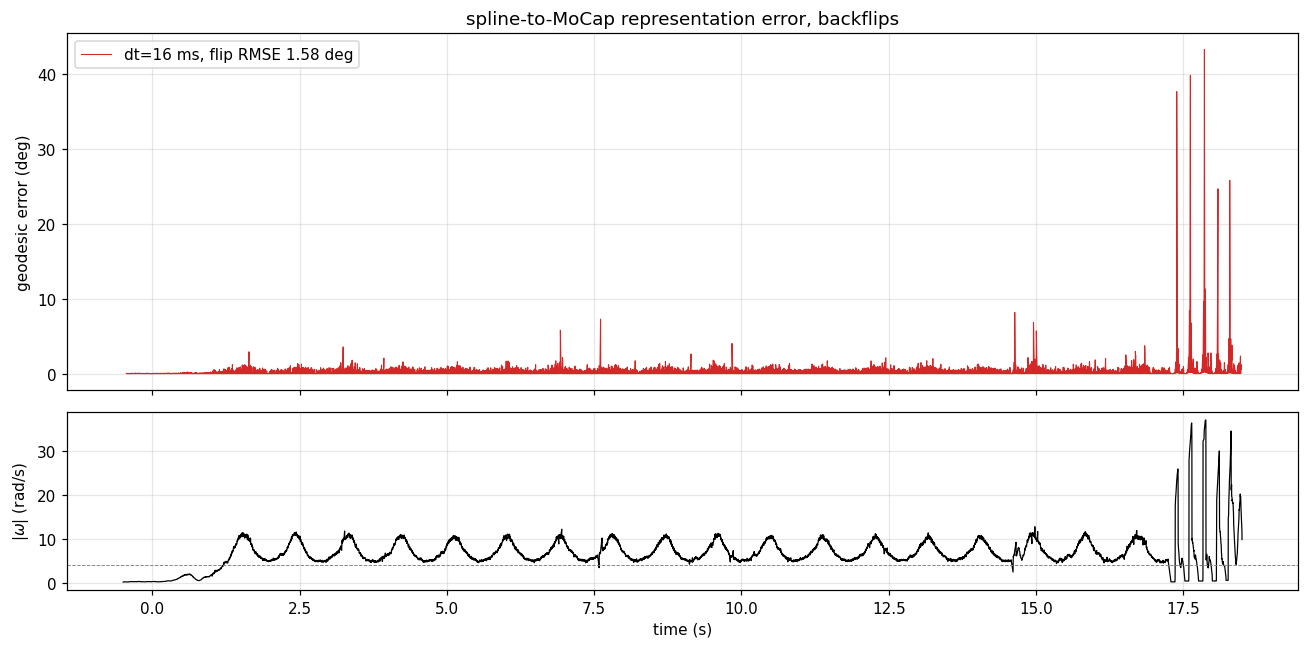

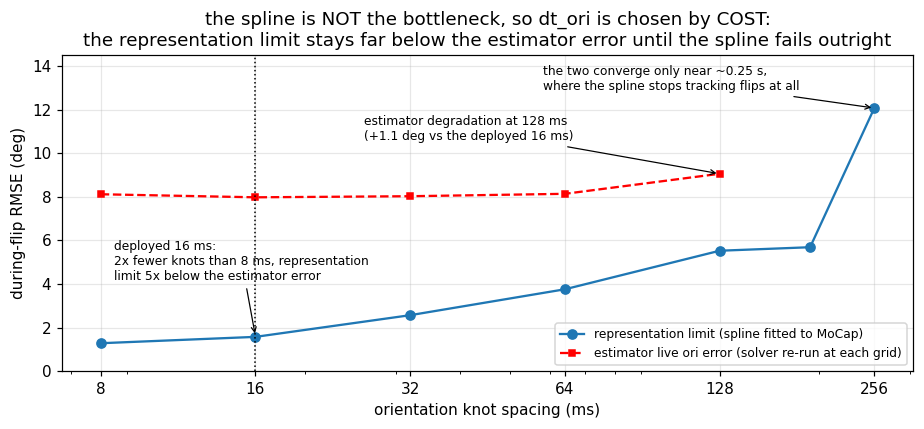

In [30]:
# Representation error vs knot spacing on the backflips flight (~1-2 min)
from nonuniform_bspline import NonUniformSO3Spline, extend_knots, so3_log

d = D['backflips_best_velocity']
t0, t1 = d['t0'], d['t1']
poses = [p for p in d['mocap_pose'] if t0 - 0.5 <= p.timestamp <= t1 + 0.5]
tp = np.array([p.timestamp for p in poses]) - t0
quats = np.array([p.orientation for p in poses])
keepm = np.concatenate([[True], np.diff(tp) > 1e-6])
tp, quats = tp[keepm], quats[keepm]
slerp = Slerp(tp, Rotation.from_quat(quats))
T0, T1 = tp[0], tp[-1]

def truth_R(t):
    return slerp(np.clip(t, T0, T1)).as_matrix()

# |omega|(t) by finite differences on a 500 Hz grid (for the flip/quiet split)
h = 0.002
tg = np.arange(T0 + h, T1 - h, h)
Rg = slerp(tg).as_matrix()
om_fd = np.array([so3_log(Rg[i].T @ Rg[i + 1]) / h for i in range(len(tg) - 1)])
t_om = 0.5 * (tg[:-1] + tg[1:])
om_n = np.linalg.norm(om_fd, axis=1)
w = max(1, int(round(0.05 / h)))
om_smooth = np.convolve(om_n, np.ones(w) / w, mode='same')
# raw FD max is inflated by MoCap occlusion glitches (the paper's "ground truth
# itself degrades during flips"); quote robust percentiles instead
print(f'|omega|: median {np.median(om_smooth):.2f}, p95 {np.percentile(om_smooth, 95):.1f} '
      f'rad/s (raw FD spikes above this are MoCap occlusion glitches); '
      f'{100*np.mean(om_smooth > 4):.0f}% of the flight above 4 rad/s')

def fit_and_eval(dt, n_refine=8):
    kt = np.arange(T0, T1 + 1e-9, dt)
    ext = extend_knots(kt)
    Rk = np.empty((len(kt), 3, 3))
    for j in range(len(kt)):
        Rk[j] = truth_R((ext[j + 4] + ext[j + 5] + ext[j + 6]) / 3.0)
    sp = NonUniformSO3Spline(kt, Rk)
    for _ in range(n_refine):
        R_new = sp.R.copy()
        for j in range(len(kt)):
            xi = np.clip((sp.ext[j + 4] + sp.ext[j + 5] + sp.ext[j + 6]) / 3.0,
                         sp.t_start, sp.t_end - 1e-9)
            R_sp, _ = sp.evaluate(xi)
            R_new[j] = sp.R[j] @ (R_sp.T @ truth_R(xi))
        sp = NonUniformSO3Spline(kt, R_new)
    ts = np.arange(sp.t_start + 0.01, sp.t_end - 0.01, 0.002)
    err = np.array([np.degrees(np.linalg.norm(so3_log(sp.evaluate(t)[0].T
                                                      @ truth_R(t))))
                    for t in ts])
    flip = np.interp(ts, t_om, om_smooth) > 4.0
    return dict(dt=dt, ts=ts, err=err, flip=flip,
                rmse=float(np.sqrt(np.mean(err ** 2))),
                rmse_flip=float(np.sqrt(np.mean(err[flip] ** 2))))

results = []
for dt_ms in [8, 16, 32, 64, 128, 192, 256]:
    r = fit_and_eval(dt_ms / 1e3)
    results.append(r)
    print(f'  dt_ori = {dt_ms:>3d} ms: RMSE {r["rmse"]:6.2f} deg, '
          f'during-flip RMSE {r["rmse_flip"]:6.2f} deg')
print('\npaper: the spline represents MoCap to 1.28 deg during flips at 8 ms and')
print('still 3.8 deg at 64 ms -- all far below the ~8 deg the ESTIMATOR achieves.')
print('Estimator re-measured at the current config (2026-08-10): flat 7.98-8.14 deg')
print('for dt_ori 8-64 ms, first degradation at 128 ms (9.06 deg). The deployed')
print('16 ms grid carries ~4x more orientation DoF than backflip accuracy requires.')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
r16 = results[1]
axes[0].plot(r16['ts'], r16['err'], lw=0.7, color='tab:red',
             label=f'dt=16 ms, flip RMSE {r16["rmse_flip"]:.2f} deg')
axes[0].set_ylabel('geodesic error (deg)')
axes[0].set_title('spline-to-MoCap representation error, backflips')
axes[0].legend()
axes[1].plot(t_om, om_smooth, 'k-', lw=0.8)
axes[1].axhline(4, color='gray', ls='--', lw=0.6)
axes[1].set_ylabel('$|\\omega|$ (rad/s)'); axes[1].set_xlabel('time (s)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot([r['dt'] * 1e3 for r in results], [r['rmse_flip'] for r in results], '-o',
        label='representation limit (spline fitted to MoCap)')
# what the ESTIMATOR achieves at each grid: measured 2026-08-10 by re-running
# the deployed unified config (speed-weight era) at each dt_ori.  (The earlier
# rate-law-era B5 sweep gave 6.22/6.42/6.38 flat at 16-64 ms, 7.32 at 128 --
# same shape at that era's lower absolute level.)
EST_MS = [8, 16, 32, 64, 128]
EST_ORI = [8.12, 7.98, 8.03, 8.14, 9.06]
ax.plot(EST_MS, EST_ORI, 'r--s', ms=4,
        label='estimator live ori error (solver re-run at each grid)')
ax.annotate(f'estimator degradation at 128 ms\n'
            f'(+{EST_ORI[4]-EST_ORI[1]:.1f} deg vs the deployed 16 ms)',
            xy=(128, EST_ORI[4]), xytext=(26, 10.6), fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.annotate('the two converge only near ~0.25 s,\nwhere the spline stops '
            'tracking flips at all', xy=(256, results[-1]['rmse_flip']),
            xytext=(58, 12.9), fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.axvline(16, color='k', ls=':', lw=1)
ax.annotate('deployed 16 ms:\n2x fewer knots than 8 ms, representation\n'
            'limit 5x below the estimator error', xy=(16, 1.6),
            xytext=(8.5, 4.2), fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xscale('log')
ax.set_xticks([8, 16, 32, 64, 128, 256], [8, 16, 32, 64, 128, 256])
ax.set_ylim(0, 14.5)
ax.set_xlabel('orientation knot spacing (ms)')
ax.set_ylabel('during-flip RMSE (deg)')
ax.set_title('the spline is NOT the bottleneck, so dt_ori is chosen by COST:\n'
             'the representation limit stays far below the estimator error '
             'until the spline fails outright')
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout()
print('Why 16 ms and not 8 or 64: accuracy cannot decide (flat band), so the grid')
print('is set by margin + cost. 16 ms halves the knot count vs 8 ms while keeping')
print('the representation limit ~5x below the estimator error; 64 ms would still')
print('work on backflips but leaves no margin for faster-than-recorded maneuvers,')
print('and the unified 40/16 ms grid also improved the velocity metric by')
print('low-passing the spline derivative (section 11 config).')

> **Design consequence.** The spline can follow the flips five to seven times better
> than the estimator does (1.3-1.6 deg representation vs the ~8-8.6 deg the estimator
> reaches across weighting eras), so knot density is not the bottleneck and adaptive knots are dead
> (our own negative result). The two error levels only meet near ~0.25 s knot
> spacing, where the spline stops tracking the flips at all (during-flip
> representation error 5.7 deg at 192 ms, 12.1 deg at 256 ms, 80 deg at 384 ms). The real lever was the weighting of section 8: without the radar
> down-weighting under dynamics, the fusion was worse than gyro-only dead
> reckoning. (That down-weighting was rate-conditioned when this was measured and
> is speed-conditioned now; the point survives the swap, and the rate mechanism
> itself is retracted in 8b's unfold box.) Knot
> spacing is therefore chosen for cost, not accuracy: the 40/16 ms grid is about 4x
> coarser than the flips require, solves faster, and even smooths the velocity
> estimate.

## 10. Sliding window and marginalization: why consistency mattered


For live estimation the trajectory is optimized over a sliding 3 s window advancing in
0.3 s strides. When the window slides, the oldest states cannot simply be deleted: their
information must be *marginalized* into a Gaussian prior on the states that remain, or
the estimator forgets (drifts) or double-counts (becomes overconfident).

Historically this system needed a hand-tuned `marg_prior_scale` per flight regime
(1e-7 to 2e-4), a classic symptom of an *inconsistent* prior. Two fixes made the scale
exactly 1.0 universal:

1. **True Schur-complement marginal** over the eliminated states.
2. **Markov-blanket factor selection**: the prior is built from *exactly* the factors
   that touch the marginalized states (their Markov blanket), each used *once*. Factors
   fully inside the window stay out of the prior (they will be counted when the window
   is solved); the constant bias state belongs to the boundary.

A third consistency term was measured and deployed 2026-08-12
(`worklog/2026-08-12_gp-port-experiments.md`): **rotation-swept staleness
inflation**. The prior's orientation rows are linearized at attitudes that a
fast rotation has since swept away from, so their covariance is inflated by
$\sigma_\mathrm{add} = k\,\theta_\mathrm{swept}$ ($\theta_\mathrm{swept}$ =
accumulated rotation over the marginalized zone), mean-preservingly, through
the same Woodbury update as the bias random walk. Two findings behind the
constant: the inflation CANNOT be derived from internal statistics -- an
overconfident prior is self-consistent at the MAP ($\lVert r\rVert^2 \approx
1.4$ against rank 27 even mid-flip) and clamps exactly the update statistic
one would measure (realized $d\phi/\theta$ only doubles, 0.0018 to 0.0036,
when the prior is loosened) -- so $k$ was measured **against ground truth**:
the live orientation error grows by a median 0.011 rad per swept radian on
growth windows, giving the deployed $k = 0.01$. On backflips the term is
worth $-0.2$ to $-0.5$ deg orientation; on low-rotation flights
$\theta_\mathrm{swept}$ is small and the term self-deactivates.

The toy below shows both failure modes in three lines of linear algebra.

In [31]:
# Toy: chain x0 -- x1 -- x2 with a prior on x0 and unit-information odometry links.
# Marginalize x0 and compare the resulting information about (x1, x2).
J = []
J.append((np.array([1.0, 0, 0]), 1.0))     # prior on x0
J.append((np.array([-1.0, 1, 0]), 4.0))    # odom x0 -> x1   (touches x0: blanket)
J.append((np.array([0, -1.0, 1]), 4.0))    # odom x1 -> x2   (inside window)

H = sum(w * np.outer(j, j) for j, w in J)          # full 3x3 information
# (a) exact: Schur complement onto (x1, x2) of the FULL problem
H_exact = H[1:, 1:] - np.outer(H[1:, 0], H[0, 1:]) / H[0, 0]

# (b) deployed: Schur of the BLANKET only (factors touching x0), then re-add the rest
Hb = sum(w * np.outer(j, j) for j, w in J[:2])     # prior + odom01 only
Hb_marg = Hb[1:, 1:] - np.outer(Hb[1:, 0], Hb[0, 1:]) / Hb[0, 0]
H_blanket = Hb_marg + sum(w * np.outer(j[1:], j[1:]) for j, w in J[2:])

# (c) naive drop of rows/cols: this CONDITIONS on x0 = 0 (overconfident)
H_drop = H[1:, 1:]
# (c2) naive factor drop: discard every factor touching x0 (forgets the anchor)
H_forget = sum(w * np.outer(j[1:], j[1:]) for j, w in J[2:])

# (d) wrong blanket: also feed the in-window factor into the prior -> double count
Hw = sum(w * np.outer(j, j) for j, w in J)         # ALL factors into the prior
Hw_marg = Hw[1:, 1:] - np.outer(Hw[1:, 0], Hw[0, 1:]) / Hw[0, 0]
H_double = Hw_marg + sum(w * np.outer(j[1:], j[1:]) for j, w in J[2:])

for name, Hm in [('exact marginal        ', H_exact),
                 ('Markov blanket rule   ', H_blanket),
                 ('rows/cols deleted     ', H_drop),
                 ('factors dropped       ', H_forget),
                 ('blanket too large     ', H_double)]:
    if np.linalg.cond(Hm) > 1e12:
        print(f'{name} sigma unbounded (singular information: no anchor left)')
    else:
        sd = np.sqrt(np.diag(np.linalg.inv(Hm)))
        print(f'{name} sigma(x1)={sd[0]:.3f}  sigma(x2)={sd[1]:.3f}')

exact marginal         sigma(x1)=1.118  sigma(x2)=1.225
Markov blanket rule    sigma(x1)=1.118  sigma(x2)=1.225
rows/cols deleted      sigma(x1)=0.500  sigma(x2)=0.707
factors dropped        sigma unbounded (singular information: no anchor left)
blanket too large      sigma(x1)=1.118  sigma(x2)=1.173


> **Reading the toy.** The blanket rule reproduces the exact marginal. Both naive
> shortcuts fail in opposite directions: deleting the state's rows and columns
> *conditions* on it and reports overconfident sigmas, dropping every factor that
> touches it loses the anchor entirely (singular information, unbounded sigma), and
> an over-large blanket double-counts the in-window factor (overconfident again).
> The per-regime prior-scale knob was papering over exactly these failure modes.
>
> **Design consequence.** With the exact marginal and the blanket rule
> (`marg_markov_blanket=1`), the prior scale is 1.0 for every flight and platform: the
> per-regime tuning knob disappeared, warm starts became consistent (2.8x faster as a
> side effect), and the covariances became trustworthy enough to report NEES. This is
> paper contribution (1), and it is estimator plumbing, kept separate from the
> sensor-data story of Part I.

## 11. End to end: one unified configuration

Everything above compiles into one command. The unified configuration
(identical for all bags and platforms): grids $\Delta t_p = 40$ ms /
$\Delta t_o = 16$ ms, the section-8 **per-return law**
($w_j = 1/(1+(\sigma_u q_j/\sigma_0)^2)$, each return's own geometry,
$|\mathbf v_f|$ from the frame's own consensus ego-speed) composed through
the **exact frame covariance** ($\sigma_c = 1.27$, measured on this weight
channel) with the constant alias weight 0.019 (sec. 8f), the model-sigma
Huber knee ($\delta_j = \delta/\sqrt{w_j}$), the **derived** static weights
of 8e, the section-7 RANSAC prefilter, the staleness-inflated
marginalization prior (sec. 10), heading weight 0.6, extrinsics locked at
the measured pitch. There is **no SNR weight**: section 7 measured that
signal strength does not vary monotonically with noise, and the weight built
on it was deleted 2026-08-09. Body rate appears nowhere in the radar
channel. No per-bag knobs, no hand-tuned weight (backflips carries no rescue
terms). Expected on slow racing: about 0.18 m/s / 1.7 deg / 0.82 % drift at
the live edge.

**One thing to be clear about before the numbers.** The configuration below
became internally consistent only on 2026-08-12. Before that, the deployed
dynamic weight was a per-frame speed law whose own derivation 8b retracts,
kept because the per-return law it endorses had failed its first gate. That
failure was a composition defect, and with the exact covariance and the
duplicate-detection collapse the endorsed law now runs *and* wins its
battery: the configuration below is simultaneously the one that runs, the
one that survived testing, and the one whose derivation this notebook
endorses. The uncomfortable position the earlier version of this paragraph
reported is resolved; the evidence is in the ledger below.

Three provenance notes. *Adoption status:* the per-return model is the config default since
2026-08-12 (`radar_weight_model: bearing_b` in `solver_cpp.yaml`), so the
run below passes no radar-model flags; the per-frame speed law (candidate A,
2026-08-02) is the legacy arm. *Heading:* yaw is unobservable from Doppler+IMU (rotating
the whole trajectory about gravity changes no measurement), so the solver
consumes a heading prior (`--mocap-yaw`, weight $\lambda_\psi = 0.6$); the
weight is capped at what a real magnetometer would justify, and a 0-to-10
ladder moves position and velocity not at all and orientation by at most
0.7 deg (full treatment in the paper's heading section). *Grids:* the 16 ms
orientation knot spacing is founded in section 9; the 40 ms position spacing
comes from the same cost logic via the config-unification sweep record
(position accuracy flat), not from an in-notebook measurement.


In [32]:
# Run the real C++ sliding-window solver (~1 min on slow racing). Set RUN_SOLVER=False to skip.
import re
import subprocess

RUN_SOLVER = True
BAG = 'slow_racing_best_velocity'      # try 'fast_racing_best_velocity' too

if RUN_SOLVER:
    cmd = [sys.executable, 'validate_live_solver.py', BAG,
           '--mocap-yaw', '--cpp', '--sliding-window',
           '--set', 'marg_prior_scale=1.0',
           '--set', 'accel_soft_sigma=8.0',
           '--set', 'dt_pos=0.04', '--set', 'dt_ori=0.016',
           '--set', 'lambda_heading=0.6', '--set', 'lock_extrinsics=1',
           '--set-ext', 'rotation_euler_deg=[180.0,27.5,0.0]']
    if BAG.startswith('backflips'):
        cmd += ['--set', 'lock_gyro_bias=0']   # undo a batch-era bags.yaml override
    print('$', ' '.join(cmd[1:]), '\n')
    proc = subprocess.run(cmd, cwd=str(ANALYSIS), capture_output=True, text=True,
                          timeout=3600)
    out = proc.stdout
    m = re.search(r'=== RESULTS', out)
    print(out[m.start():] if m else out[-4000:])
    if proc.returncode != 0:
        print('STDERR tail:\n', proc.stderr[-2000:])

$ validate_live_solver.py slow_racing_best_velocity --mocap-yaw --cpp --sliding-window --set marg_prior_scale=1.0 --set accel_soft_sigma=8.0 --set dt_pos=0.04 --set dt_ori=0.016 --set lambda_heading=0.6 --set lock_extrinsics=1 --set-ext rotation_euler_deg=[180.0,27.5,0.0] 



=== RESULTS (mocap-init+mocap-heading+gyro) — settled vs live (76 windows) ===
  Metric                          Settled   Live edge         Δ
  ---------------------------- ----------  ----------  --------
  Position RMSE (m)                0.4791  0.3997   -0.0793
  Position drift (%)                0.99%  0.82%   -0.1631
    horizontal (xy) RMSE (m)       0.2417   (drift 0.50%)
    vertical (z) RMSE (m)          0.4136   (drift 0.85%)
  Velocity RMSE (m/s)              0.1162  0.1767   +0.0605
  Angular vel RMSE (rad/s)         0.2004
  Acceleration RMSE (m/s²)         0.9963
  Orientation RMSE (deg)           1.1058  1.6746   +0.5687
  Per-axis ori RMSE: roll=0.783  pitch=0.561  yaw=0.679 deg
  Acc bias: [-0.0051, 0.0490, 0.2393] m/s²
  Gyr bias: [0.0008, -0.0029, 0.0025] rad/s
  Live eval range: [2.629, 22.999] s  (6092 MoCap pts)

--------------------------------Generating Plots--------------------------------
  Saved: /home/mouse/MyData/radar-iwr6843-driver/plots/slow_racing_bes

live_validation_slow_racing_best_velocity_mocap-init_mocap-heading_20260813_084812.png


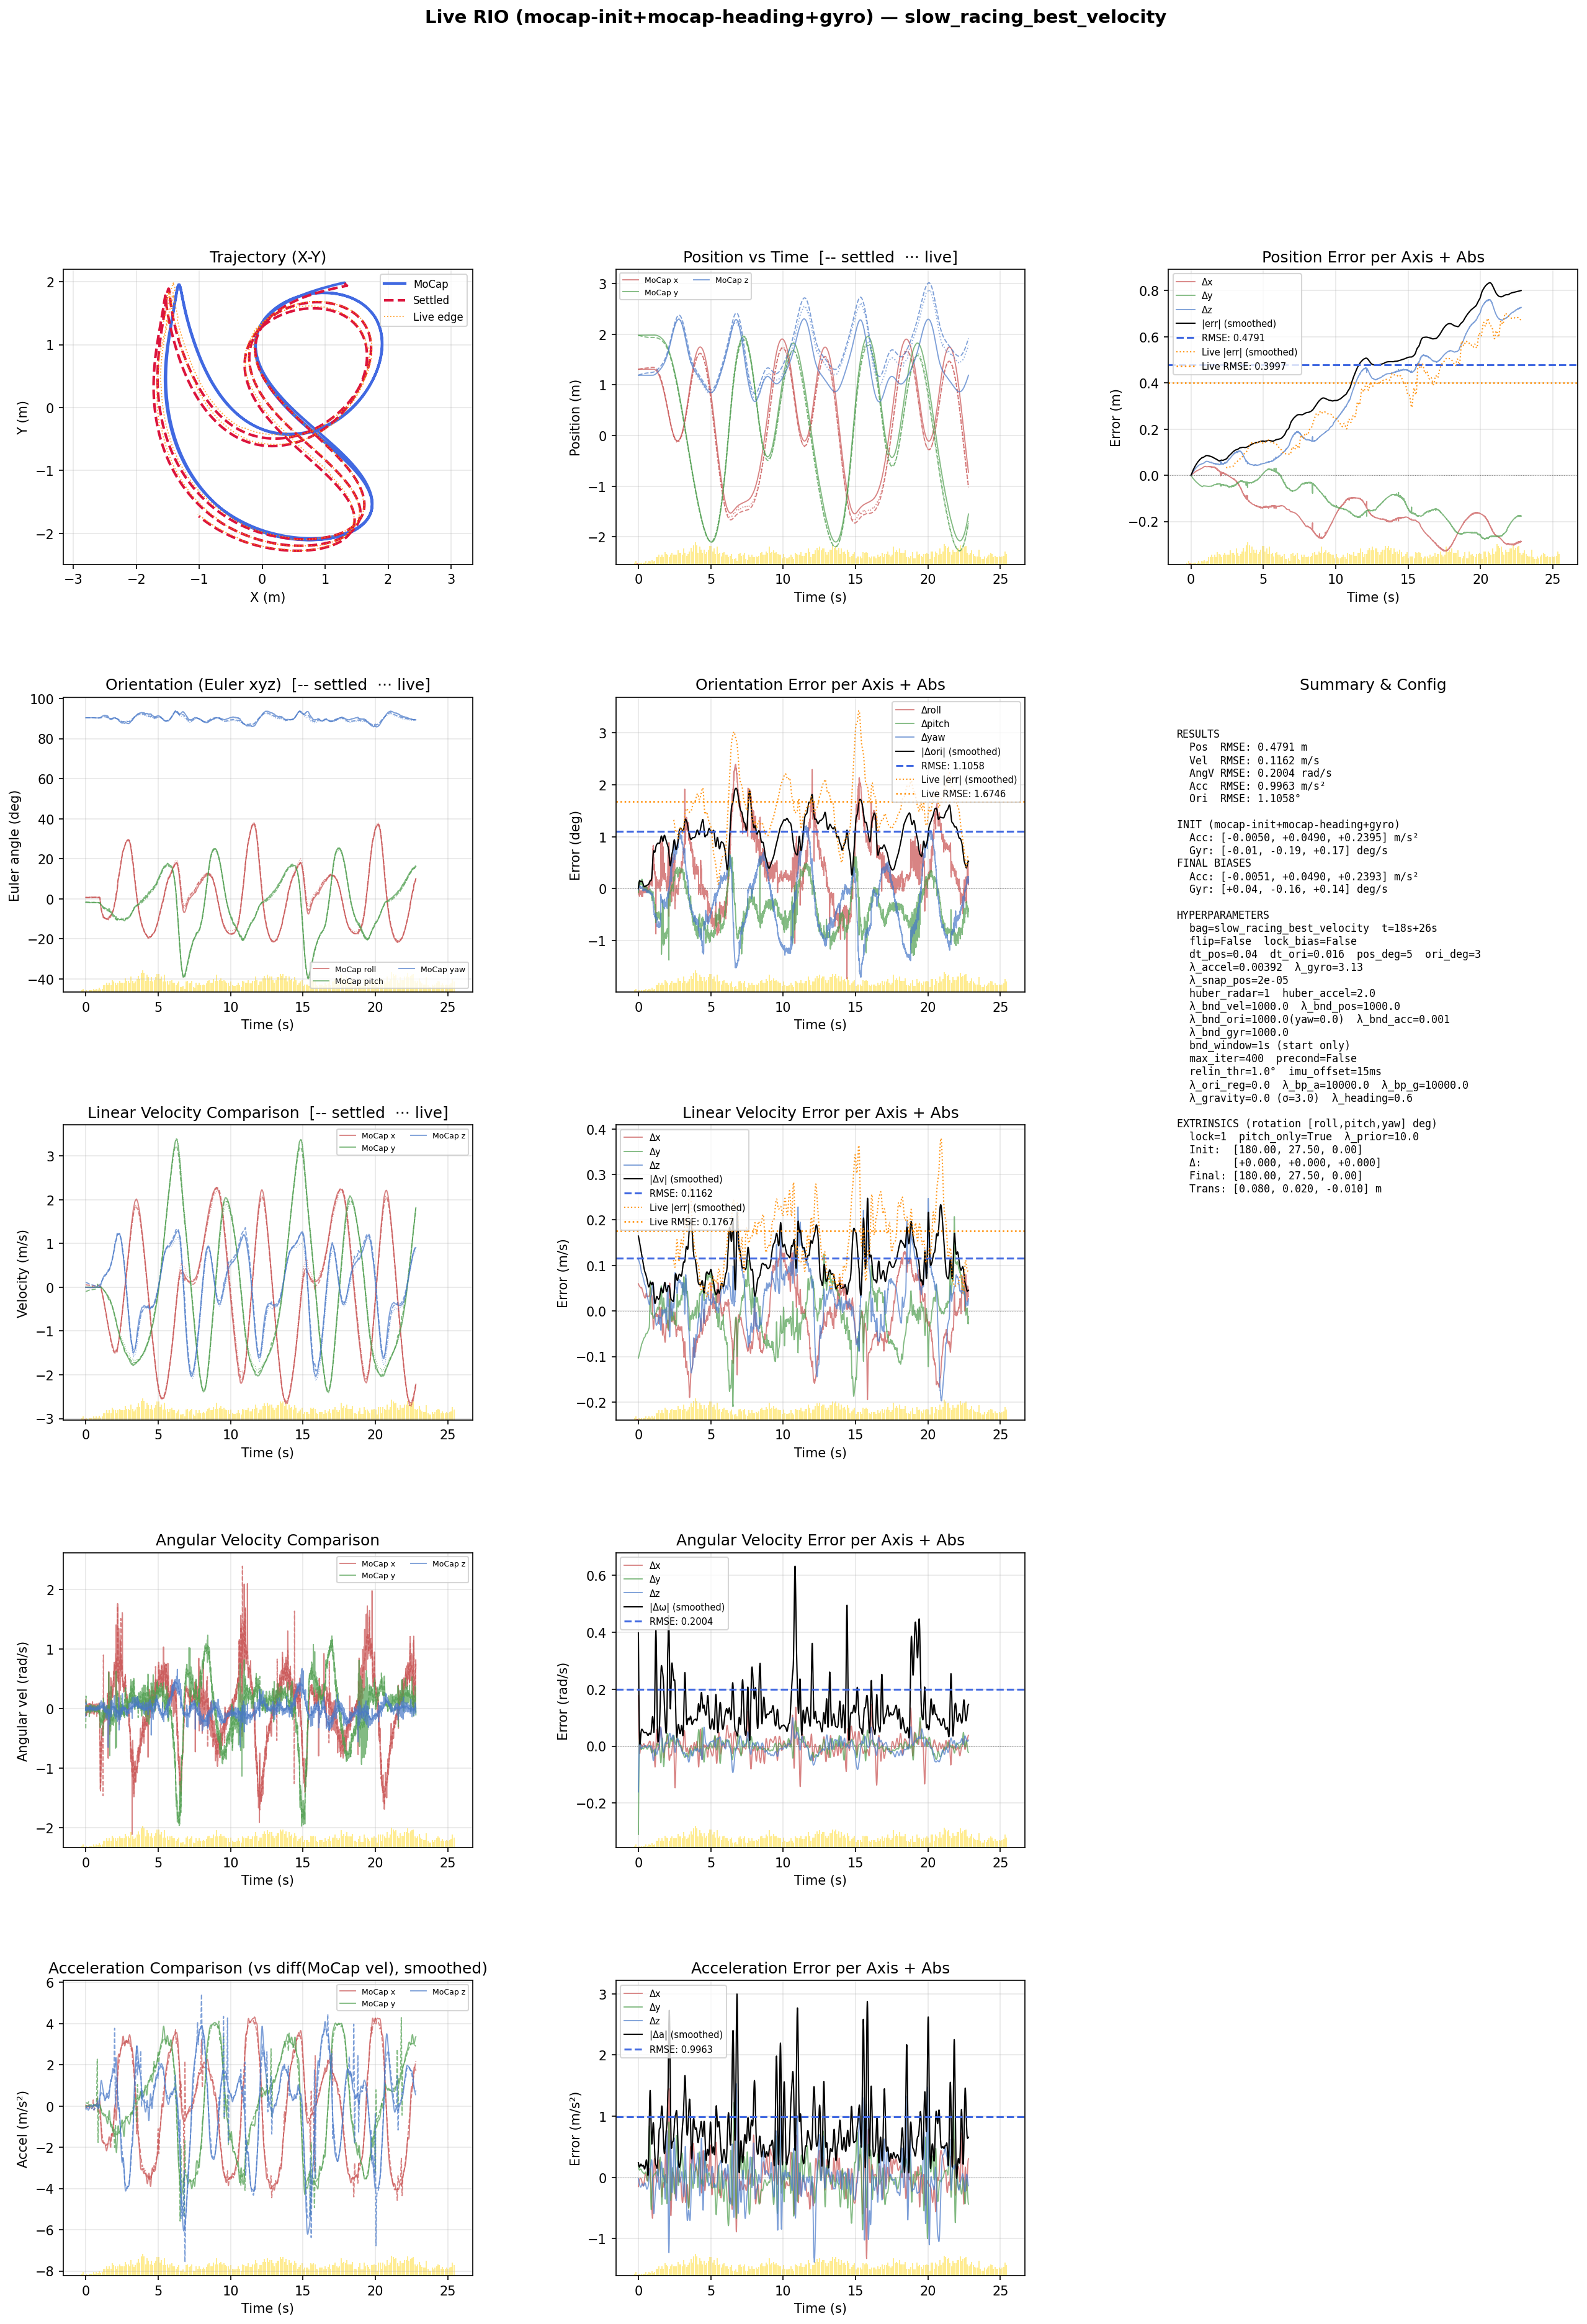

In [33]:
# Display the trajectory/error plot the run just saved
from IPython.display import Image, display

if RUN_SOLVER:
    plot_dir = REPO_ROOT / 'plots' / BAG / 'live_solver'
    pngs = sorted(plot_dir.glob('live_validation_*.png'),
                  key=lambda p: p.stat().st_mtime)
    if pngs:
        print(pngs[-1].name)
        display(Image(str(pngs[-1]), width=980))

### Ablation ledger: what each layer is worth end to end

Single-knob ablations; live-edge metrics (velocity m/s / orientation deg /
position drift %):

| Layer | fast racing | slow racing | other flights |
|---|---|---|---|
| RANSAC prefilter off | velocity 0.32 -> 0.43 (+35%), ori +0.6 deg | velocity +23% | ICINS: fails outright |
| Huber -> plain L2 | drift 1.17 -> 1.45% | bit-identical (kernel touches 0.03% of kept points) | - |
| SNR/intensity weight off — **now the default; the weight was DELETED 2026-08-09** | velocity $-0.1$%, ori $-0.8$%, drift 0.72 -> 0.79% | velocity +2.0%, ori +0.6%, drift 0.71 -> 0.75% | backflips drift **9.58 -> 6.88%**, vel +2.9%; fast2 held-out better on all three; **ICINS: no consistent direction** — ATE better on 2/4 and worse on 2/4, spanning $-38.8$% to $+27.0$%, orientation likewise 2/2 at up to $\pm46$% |
| frame whitening off ($\sigma_c = 0$) — **re-measured 2026-08-09** | velocity +0.9%, ori $-1.6$%, drift 0.79 -> 0.85%, horiz pos +1.5% | velocity +2.6%, ori $-0.8$%, drift 0.75 -> 0.73%, horiz pos $-5.9$% | **backflips depends on it heavily**: drift **6.88 -> 10.03%**, horiz pos +39%, velocity +4.0%, ori +5.6%. fast2 held-out is *better* without it (drift $-15$%, pos $-24$%) |
| dynamic law: **speed (adopted)** vs previous rate law | 0.277/2.55/**0.72** vs 0.297/2.56/0.92 | 0.184/1.72/0.71 vs 0.180/1.71/0.59 | backflips 2.31/8.04/9.6 vs 2.36/8.19/10.3; fast2 held-out 0.316/2.61/**1.21** vs 0.401/2.64/1.64; ICINS par ($\pm$6 mm) |
| dynamic law off entirely (aliased points held at the constant 0.019; single-knob) | 0.299/2.57/0.92 | 0.179/1.71/0.58 | backflips 2.50/**9.43**/6.9: on backflips the law mainly protects orientation ($-1.4$ deg) at a drift cost; backflips is the declared failure regime |
| accel gate $\omega_a$ ladder (0 / 0.5 / 2 / 8 / 32; 8 deployed) | flat for $\omega_a \ge 8$ through gate-off (velocity 0.256-0.277); degrades below 2 (at 0.5: velocity 0.28 -> 0.63, drift 0.72 -> 1.27%) | flat throughout | backflips: looser gates trade attitude for drift (gate-off: ori 9.13 vs 8.04 deg, drift 7.14 vs 9.58%); 8 = racing-flat + flip-attitude-best |
| frame whitening, heteroscedastic correction at the measured $\sigma_c = 0.81$ (`radar_frame_hetero`; 0.81 was the then-deployed intensity x alias channel, 0.84 on today's) | 0.2968/2.562/0.92 -> **0.2906/2.576/0.85** | 0.1798/1.712/0.59 -> **0.1726/1.706/0.62** | splits perfectly by returns-per-frame: backflips ($\bar N$ 9) better, all five high-$N$ flights worse (fast2 0.4015 -> 0.4151; ICINS 1 ATE 0.180 -> 0.238 m). **Not adopted**; see 8d |
| static weights: derived vs old hand-tuned set | velocity 0.32 -> 0.28 (tuned wins 11%: the accepted price of deriving) | derived wins everything: velocity 0.21 -> 0.18, drift 1.12 -> 0.59% | par-to-better derived |

> **Which `fast2` numbers here predate the window fix.** The held-out flight's
> analysis window used to overrun its radar by 1.2 s (12 % of the run IMU-only);
> it was corrected to 8.5 s on 2026-08-09
> (`worklog/2026-08-09_fast2-window-defect.md`). Every arm-vs-arm verdict in this
> ledger stands, because both arms of each battery starved identically. The *absolute*
> fast2 figures do not: the dynamic-law row, the hetero row, the bearing-law
> comparison table and the two rate-era controls are all **pre-fix**; the SNR
> row and the whitening row were re-measured after it.

Ledger scope: the rows cover the radar front end and the weighting; structural
choices and plumbing constants (spline degrees, window 3.0 s / stride 0.3 s,
bias priors, min-snap and boundary regularization, the accelerometer Huber
$\delta_a$, RANSAC's draw count, unwrapping itself, the marginalization rule,
the heading prior) are not separately ablated here; their evidence lives in the
repo's design docs, and several are catastrophic-obvious (a basic LS solver
without unwrapping fails on any aggressive flight). Provenance, **and a correction worth reading before trusting the other rows**:
the front-end rows (RANSAC, Huber, whitening) were measured at the
*rate-law-era* defaults, on the assumption that these layers are independent of
the dynamic-law swap. The SNR row was re-measured at the current configuration
during its deletion battery (2026-08-09), and **for that row the assumption did
not hold**: the rate-era version read "position +25%, drift 0.92 -> 1.15%" on
fast racing, where the current configuration gives velocity $-0.1$% and drift
0.72 -> 0.79%. The row now shows the re-measured numbers. The remaining stale
rows should therefore be read as *rate-era* evidence that their layer matters,
not as current magnitudes. RANSAC and Huber are qualitative enough that nothing
turns on the number (a prefilter-off run fails outright on ICINS); the whitening
row is the one candidate for the same re-measurement.

**How to read the re-measured whitening row**, since it is more mixed than its
rate-era version suggested (which claimed "position +8%" on fast racing where the
current configuration gives +1.5%). On the racing flights the effect is small and
splits by metric: velocity wants the whitening, orientation slightly does not.
The case rests on the two ends. **Backflips depends on it heavily and
consistently** -- every metric degrades without it, drift by 46 % -- and that is
the regime the frame-shared error was measured to be largest in. The held-out
flight goes the other way by a smaller margin.

That mixture is *not* the SNR weight's situation, and the difference is the point
of this section. $\sigma_c$ is **derived**: section 8c measures the intra-frame
correlation, 8d builds the operator that model implies, and the constant is the
measured one. It is kept because it is the correct model of a measured effect and
because it carries the hardest regime, not because a sweep found it favourable.
An unfounded knob with this evidence profile would go.

One more thing follows from the deletion and is worth stating plainly: **every
row in this table except the SNR row was measured with the SNR weight switched
on.** Since that weight is now gone, each remaining row's *baseline* differs from
the shipping configuration by that one knob. The knob is small on our own flights
(1-3 %), so the rows still say which layers matter; they should not be read as
exact current magnitudes. The rate-era
fast2 control appears as 0.401/2.64/1.64 here (unified-battery record) and
0.396/2.64/1.60 in sec. 8f (2026-07-19 campaign): two recorded campaigns of the
same configuration. The speed-vs-rate row is the full gate battery of the swap
(controls reproduced the published numbers bit-for-bit before the comparison).
NEES at the deployed speed law: racing full-state conservative (x0.45/x0.63),
backflips velocity calibrated (x0.98), backflips orientation overconfident
(n = 6 windows caveat). Cross-platform covariance check (ICINS, same config,
full-length per-window covariance): strongly conservative, full-state
$\sigma$-scale x0.23 (flight 2) and x0.18 (flight 4); no overconfidence on
the foreign platform. Flights 1 and 3 (~600 windows) exceed the per-window
covariance compute budget at full length, a tooling limit, not an estimator
property. Also measured and rejected: re-deriving the radar
static on speed-whitened residuals (7.54) improves drift broadly but makes the
backflips velocity NEES overconfident (x1.70); see 8e. Backflips moves in all
rows but is a declared limit and does not rank designs.

**Open items this ledger does not yet cover** (all identified in the 2026-08-06
and 2026-08-07 audits, all recorded rather than quietly deployed):
the alias weight re-derived at matched speed (8f), roughly an order of
magnitude above the deployed 0.019; a consensus
threshold and a Huber $\delta$ that scale with the measured $\sigma(|\mathbf v|)$
instead of staying constant while the noise model varies 3-5x. Each changes a
deployed constant, so each needs the full gate battery before adoption; neither
is claimed here.

The third item on this list -- $\sigma_c$ re-measured on the stream the solver
consumes -- **is now closed**, and the row above is the result. What the
config key means turned out to be the substance: it is the ratio
$\sigma_c/\sigma_0$ normalised by the per-point weight channel, so it is a
property of the radar *and* of the weighting, and it must be re-derived whenever
the weights change. Naming the channels, because they have moved: today's
deployed channel is the alias rule alone (the SNR weight was deleted 2026-08-09)
and measures **0.84**; the intensity x alias channel that shipped before it
measures 0.81; the bearing channel would need 1.24. The transfer --
0.63-0.93 across eight flights and two platforms -- was measured on the
intensity x alias channel (8d's table); the alias-only 0.84 is so far a
three-flight own-platform measurement. Gated at
0.81 it still loses, in the pattern the row records. 8d carries the reason it is
worth more than an adoption: both operators assume the frame-shared error is
refreshed every frame, and it is not.

**One former open item is now closed, as a measured negative.** The per-point
bearing weighting of 8b was run through this same battery
(`--bearing-weight b`, eight flights, plus a scale control and a scale-matched
shape control, because the weight also lowers the effective radar weight).
Against the **shipping default** the shape improved velocity in all eight
matched own-platform comparisons (6.7-8.6 % racing, 1.1-3.3 % backflips,
2.1-2.5 % fast2; the four cross-platform numbers are raw swaps, not
scale-matched), and orientation regressed off the fit set by
$0.09$-$0.22^\circ$, which fails the criterion. It is **not adopted and nothing
was changed**.

Three qualifications, all of which a favourable reading would drop. Against the
configuration *this section runs* (`--speed-weight auto`, the retracted quartic)
rather than the shipping default, the bearing law **loses** on the held-out
flight and on backflips, on all three metrics.
The pre-registered scale control fires on fast2: scale alone buys $-10.9$ %
velocity against the shape's $-2.5$ %. And backflips drift regresses $+1.6$ to
$+3.2$ pp, which the pre-registration listed as reportable.

Compared like for like (live vel / ori / drift), with the section-11
configuration as the baseline it should have been measured against:

| bag | sec. 11 config (quartic) | bearing law, raw swap | bearing law, shape-only |
|---|---|---|---|
| slow | 0.184 / 1.722 / 0.71 | **0.173 / 1.668 / 0.60** | **0.165 / 1.644 / 0.49** |
| fast | 0.277 / 2.546 / 0.72 | **0.269 / 2.508** / 0.82 | 0.271 / 2.531 / 0.80 |
| backflips | **2.310 / 8.042 / 9.58** | 2.731 / 8.241 / 13.47 | 2.334 / 8.413 / 11.91 |
| fast2 HO | **0.316 / 2.614 / 1.21** | 0.349 / 2.706 / 1.40 | 0.393 / 2.756 / 1.57 |

The orientation cost itself is **not explained**, and the honest form of that
statement is worth stating precisely because it is the section's one negative.
An earlier reading attributed it to the weight thinning a frame's angular
diversity, measured as the per-frame ray-direction scatter becoming worse
conditioned. That is **withdrawn**: the forward model
$r_j = -\mathbf u_j^\top(\mathbf v_b + \boldsymbol\omega\times\mathbf t)$ puts
every parameter behind one 3-vector, so a single frame's Jacobian has **rank 3 of
9** and any attitude perturbation is absorbed exactly by a velocity one. One
radar frame carries no attitude information at all; rotation is identified only
across frames — the classic single-scan Doppler observability result (Kellner
et al., ITSC 2013 / ICRA 2014), here in spline coordinates. A per-frame conditioning number cannot reach that channel even in
principle.

**A fourth candidate was opened on 2026-08-09 on own-platform evidence** --
and the cross-platform check meant to test it came back void (below), so it
remains a candidate, not an answer. The
consensus prefilter gates at 0.15 m/s, which is **0.66 / 0.48 / 0.50 sigma**
(slow / fast / backflips) at the 95th percentile of the measured $\sigma_j$: it
cuts hardest exactly at wide angles.
The bearing weight's entire function is to down-weight wide-angle returns, so it
was gate-tested on a stream the prefilter had already stripped of the returns it
acts on. Re-running the gate in sigmas instead improves orientation on three of
four flights and improves the **held-out** flight on all three metrics by 6-17 %
-- which is precisely where the bearing weight failed. It is *not* adopted and
*not* established, and it was **downgraded on 2026-08-10** once its own
cross-platform check came back. Three things stand against it. The change
regresses fast-racing drift by 47 %, which is disqualifying on its own. The
ICINS check is **void at that reference rather than negative**: the arm
differences are 0.03-0.17 deg and 3-14 mm against a reference whose own
attitude resolves to 0.47-0.86 deg and whose position disagrees with an
independent run by 117-290 mm, so *neither* column can see the effect, and the
pre-registered prediction named an effect below the instrument floor on every
branch. That is a defect in the pre-registration, not in the run: **its table
had no minimum-resolvable-effect row**, so no outcome could have confirmed or
killed it. And the mechanism's own rationale is contradicted by our own data:
repair does not sort by returns per frame (slow $\bar N$ 12.6, $+0.7$ %; fast
10.3, $-2.9$ %; flips 9.0, $-0.5$ %; fast2 **50**, $-6.1$ % -- the largest
repair at the largest N, the opposite of the registered reasoning). What
survives is narrow and platform-local: sigma-gating helps orientation on three
of four own flights and on the held-out flight, mechanism unknown. Settling it
needs a second Vicon-referenced high-N flight of our own (fast2 capped versus
uncapped, arms C/D), not more ICINS. Recorded in
`worklog/2026-08-09_ledger-3a-thresholds-in-sigmas.md` and
`worklog/2026-08-10_audit-round-3.md`, not built on here.

What can be said instead is derivable rather than fitted. For a correctly
specified linear-Gaussian model, Gauss-Markov makes inverse-variance weighting
minimum-variance for **every** linear functional of the state, orientation
included. If the measured $\sigma_j$ were the true per-point deviations *and* the
frame-shared term were whitened correctly, this weight could not cost
orientation. It does. So the regression is **evidence of misspecification**, not
evidence that the weight is the wrong thing to apply -- and 8d named one
candidate, the mis-composed frame covariance, which removed 30-67 % of the cost
in the algebra. **That candidate has since been gated end to end and does not
survive** (the row above): correcting it helps only where a frame carries few
returns, and 8d shows why the correction is incomplete in any case. So the
misspecification is real but not located. The remaining candidates are the
across-frame correlation of the shared term (8d, measured, unmodelled in every
arm), the bag-global floor that the whitening test flags as this model's own
worst stratum, the Huber/IRLS interaction, and the spline representation error.

That is weaker than a mechanism, and it is what the evidence supports. It is also
falsifiable in a way a mechanism story is not: locate the misspecification,
correct it, and the cost should go. Recorded here because a weighting whose
failure is understood only that far is exactly what a ledger exists to hold.

**Addendum (2026-08-12): located, corrected, gone -- and deployed.** The
falsifiable prediction above fired. The misspecification was located in two
parts: (i) the scalar $\sigma_c$ whitening's speed-vs-direction balance has
an $N\cdot\sum w$-dependent operating point no single constant satisfies
(dose-responses on the two failing flights run monotonically in OPPOSITE
directions; an $N$-isolation control proves the held-out anomaly is pure
$N$), which the **exact covariance** (the hetero row above, at the
channel-matched $\sigma_c = 1.27$) removes -- backflips orientation passes
its veto for the first time; and (ii) the held-out flight's residual is
**duplicate detections** (raw-detection recording: 52 returns/frame = 16.5
physical scatterers, same-cluster correlation $+0.47$), removed by a
connected-components collapse at the measured cluster scale -- the gap
closes monotonically with residual duplicate count and reaches par exactly
at the physical cluster count. With both corrections the per-return weight
passed the eight-flight battery with NEES and **is the deployed model**
(`worklog/2026-08-12_per-return-adoption.md`), with two same-day companions:
the model-sigma Huber knee ($\delta_j = \delta/\sqrt{w_j}$, parameter-free;
carries backflips drift $-0.94$ pp and velocity $-0.13$ m/s) and the
sec.-10 staleness inflation ($k = 0.01$ measured against GT; backflips
orientation $-0.2$ deg). Deployed headline: slow 0.177/1.675/0.82, fast
0.280/2.558/1.01, backflips 2.040/7.773/7.44 (best-ever velocity), fast2
0.276/2.836/1.87, ICINS drift $+0.2$-$0.3$ pp accepted at zero per-platform
calibration ($\sigma_c$ is measured regime-dependent, 0.83-1.55 across
flights; the unified 1.27 over-whitens gentle flights and the ICINS-matched
0.93 closes 35-58 % of the gap; online $\sigma_0$/$\sigma_c$ estimation is
the recorded open item).

---
# Part III -- Is it competitive

Part II showed the system works on the flights it was characterized on. This act
asks whether that generalizes: to a flight never used in any fit, to a
different platform with a different radar and a different vehicle, and against
published radar-inertial odometry.


## 12. Held out, cross-platform, and against published EKF-RIO

Everything so far was measured on three flights of one vehicle. This section
asks whether it generalizes, in three steps of increasing distance from the
calibration set. No constant is refitted anywhere below: the configuration is
the one Part II deployed.

**Step 1 -- a held-out flight of the same platform.** `fast2` was never used in
any fit or sweep. Live edge: **velocity 0.276 m/s, orientation 2.84 deg, position drift 1.9 % of path**. A flight no fit ever saw lands within a few per cent of
the calibration flights, which is the evidence that the weighting generalizes
rather than fitting its own calibration set.

Two qualifications, because this step is easy to over-read. *First*, "held out"
here means **never used in a fit** -- not an independent flight regime: fast2 was
recorded the same afternoon on the same vehicle, flying nearly the same track at
nearly the same speeds, with the same chirp configuration (measured Doppler bin
0.0492 m/s, identical to the fit flights). What genuinely differs is that it runs
without on-chip clustering, giving 61 returns per frame against ~11 --
repaired since 2026-08-12 by a connected-components collapse to the measured
physical clusters (a recording-artifact front end, not tuning; its drift
column is the noisiest of the set, radar death at $t = 25.7$ s). *Second*,
earlier versions of this paragraph compared against 0.401 / 2.64 / 1.64 for "the
configuration it replaced" and quoted a $-21$ % velocity gain. That comparison is
**withdrawn**: its baseline was measured before this flight's analysis window was
corrected (`worklog/2026-08-09_fast2-window-defect.md` -- the old window ran 1.2 s
past the point the radar stops publishing), so the two are not matched. The
current number stands on its own; the historical delta does not.

**Step 2 -- a different platform.** The ICINS-2021 flights (Doer and Trommer)
use a different vehicle, a different radar mounting, and a different IMU. Our
configuration runs on them unchanged apart from the dataset's own extrinsics.
Whole-trajectory ATE: **0.281 / 0.123 / 0.446 / 0.247 m** on flights 1-4, drift
**0.20-0.31 %** of path -- with **zero parameters calibrated to the
platform**; the measured per-platform $\sigma_c$ (0.93 against the deployed
1.27) would close 35-58 % of the drift gap to the legacy arm (one-config
policy, stated rather than tuned away).

**Step 3 -- against published EKF radar-inertial odometry.** ekf-rio and
ekf-yrio, run under our causal protocol on the same four flights:

| Flight (path) | ekf-rio | ekf-yrio | Ours |
|---|---|---|---|
| 1 (142 m) | 0.20 / 10.1 / 1.0 | **0.08** / 0.70 / 0.3 | 0.09 / **0.64** / **0.25** |
| 2 (45 m) | 0.08 / 1.59 / 0.6 | **0.08** / **0.91** / **0.4** | **0.08** / 1.21 / 0.6 |
| 3 (147 m) | **0.08** / 1.07 / **0.3** | **0.08** / 1.09 / **0.3** | **0.08** / **0.69** / 0.6 |
| 4 (78 m) | 0.09 / 3.67 / 0.5 | **0.07** / 1.41 / **0.3** | **0.07** / **1.36** / 0.65 |

(velocity m/s / orientation deg / drift % of path; live estimate,
start-anchored alignment. The drift column moved with the 2026-08-12
per-return adoption: ekf-yrio now leads drift on flights 2-4 by
0.2-0.35 pp -- the accepted zero-per-platform-calibration cost above;
velocity stays a tie and orientation par-to-better.)

**What this reference can and cannot resolve.** Before reading any of the
columns above, a limit that applies to all of them. The ICINS pseudo-ground-truth
is an **estimator output**, not an independent measurement: it agrees with the
dataset's own VINS-no-loop-closure solution to 0.12-0.29 m in position and to
**0.47-0.86 deg in attitude** after rigid alignment
(`worklog/2026-08-09_icins-reference-is-estimator-derived.md`). Two solutions of
the same family sharing input data also share error, so that spread is an
*optimistic* bound on the reference's own attitude error, not a bracket. The
practical consequence: on these flights, orientation differences below about a
degree are inside the reference and cannot be read as one system being better
than another. Differences of several degrees can. Position and drift are far
better constrained and are what the position claims rest on.

**How to read the orientation column honestly.** It favours us, but almost
entirely through *yaw*, and yaw aiding differs by design: we consume a heading
prior (an idealized magnetometer surrogate), ekf-yrio uses sensor-only
Manhattan-world yaw, ekf-rio is unaided. On the heading-*independent* roll and
pitch the three systems are **indistinguishable**: every system on every flight
lands in the same 0.24-0.74 deg band, and per flight they differ from one
another by a few hundredths of a degree.

That indistinguishability is the claim, and it is all the claim can be. Those
values sit *below the reference's own attitude uncertainty*, so they are
disagreements with one particular estimator rather than attitude accuracies, and
the differences between systems are far below what the comparison resolves. An
earlier version of this paragraph read "all three systems agree to
0.24-0.74 deg", which invites the opposite reading. What the comparison does
establish is a **bound**: a system whose roll and pitch were degrees worse would
show plainly, and none of the three is. It bounds; it does not rank.

Removing our heading aiding confirms the reading, and that difference *is*
resolvable: on flight 1 our unaided yaw drifts to 9.7 deg, matching unaided
ekf-rio's 10.1 deg, while roll/pitch is unchanged. The orientation column is
therefore not an attitude win. Where it is genuinely informative is ekf-rio's
10.1 deg on flight 1, which is twenty times the reference floor.

*Provenance, stated rather than smoothed over:* the roll/pitch decomposition
above comes from the baseline battery as run for the paper, i.e. **before** the
SNR weight was deleted, while step 2's ATE figures are post-deletion. The two
baselines are unaffected by our weighting change, and our own column would move
in its last digit at most, so nothing here turns on it. It is not re-measured
because a sharper number would still sit under the reference floor, which is the
whole point of the paragraph.

**Where we are genuinely better, and why.** Position drift on the longest
flight, and it is the work of the RANSAC prefilter rather than of the back end:
with the prefilter disabled our vertical channel accumulates 10-14 % drift and
whole-trajectory ATE of 8.3 m on flight 1, which the EKF baselines do not
exhibit. That is section 5's elevation-diversity weakness showing up exactly
where it was predicted, and section 7's prefilter closing it.

**Covariance honesty.** One caveat belongs with every NEES number here, and it
follows from section 6: NEES $= \mathbf e^\top P^{-1}\mathbf e$ is
$\chi^2_n$-distributed only for Gaussian errors, and ours are a Gaussian core
plus a wider companion rather than a Gaussian. What survives regardless is the
**mean**: whenever $P = \Sigma$,
$\mathbb E[\mathbf e^\top P^{-1}\mathbf e] = \operatorname{tr}(P^{-1}\Sigma) = n$
for *any* distribution with that covariance. So NEES as a check on whether the
reported covariance is the right size is valid; it is the $\chi^2$ confidence
band around it that is approximate, and the conservative/calibrated readings
below should be read as size checks rather than as distributional statements.

NEES at the deployed configuration: racing full-state
conservative ($\sigma$-scale x0.45 / x0.63), backflips velocity calibrated
(x0.98), backflips orientation overconfident on 6 windows. Cross-platform,
with full per-window covariance, ICINS flights 2 and 4 are strongly
conservative (x0.23 / x0.18) -- no overconfidence on a foreign platform.
Flights 1 and 3 exceed the per-window covariance compute budget at full
length; that is a tooling limit, and it is stated rather than omitted.

**The failure regime, declared.** Backflips runs the same configuration and
remains its position limit: 2.04 m/s velocity, 7.77 deg, 7.4 % drift (the per-return model's best-ever backflips velocity, still an order above the racing flights). Sustained 10 rad/s
flips push the platform far past $v_\mathrm{max}$ (38 % of returns aliased),
the causal ego-speed that feeds the weighting law degrades from 0.05-0.13 m/s
to 0.33 m/s, and the frame-shared error becomes the dominant single-frame term
(section 5). Earlier versions of this system recovered backflips with two
per-bag rescue terms; both were non-physical proxies and both were removed, so
the regime is reported as a limit rather than repaired. The `circle` flight is
a second, related limit: at 5 m/s against a 3.14 m/s ambiguity, 64 % of its
returns alias and the unified grid degrades it from 4.2 % to 8.4 %.


In [34]:
# Cross-platform check, live: our unchanged configuration on an ICINS flight.
# Set RUN_ICINS = False to skip (~1-2 min).
RUN_ICINS = True
ICINS_BAG = 'icins_flight_2'

if RUN_ICINS and (REPO_ROOT / 'baselines' / 'datasets' / 'our_format'
                  / f'{ICINS_BAG}.bag').exists():
    # The weighting is ours, unchanged.  What MUST change per dataset is the
    # sensor mounting and the IMU rate: the ICINS radar sits at a different
    # rotation on a different vehicle (printed by
    # baselines/adapters/convert_icins_to_ours.py, used by
    # baselines/run_icins_ours.sh).  Omitting these runs their radar with OUR
    # drone's mounting -- a 47 deg yaw error -- and a freely-estimated pitch
    # seeded from our stale self-cal value.  --whole-traj-align gives the
    # EVO/KITTI Umeyama metric the published baselines are quoted under.
    cmd = [sys.executable, 'validate_live_solver.py', ICINS_BAG,
           '--mocap-yaw', '--cpp', '--sliding-window', '--no-plot',
           '--set', 'marg_prior_scale=1.0', '--set', 'omega_soft_sigma=0',
           '--speed-weight', 'auto',
           '--set', 'accel_soft_sigma=8.0',
           '--set', 'dt_pos=0.04', '--set', 'dt_ori=0.016',
           '--set', 'lambda_heading=0.6',
           '--set', 'lock_extrinsics=1',
           '--set-ext', 'rotation_euler_deg=[-178.501,-0.099,46.997]',
           '--set-ext', 'translation_body_m=[0.01,0.1,0.06]',
           '--imu-hz', '400', '--whole-traj-align']
    print('$', ' '.join(cmd[1:]), '\n')
    pr = subprocess.run(cmd, cwd=str(ANALYSIS), capture_output=True, text=True,
                        timeout=3600)
    m = re.search(r'=== RESULTS', pr.stdout)
    out = pr.stdout[m.start():] if m else pr.stdout[-3000:]
    print(out)
    for ln in pr.stdout.splitlines():
        if 'whole-traj align' in ln:
            print(ln)
    if pr.returncode != 0:
        print('STDERR tail:\n', pr.stderr[-1500:])
else:
    print('skipped (RUN_ICINS False or dataset not converted; see baselines/README.md)')


$ validate_live_solver.py icins_flight_2 --mocap-yaw --cpp --sliding-window --no-plot --set marg_prior_scale=1.0 --set omega_soft_sigma=0 --speed-weight auto --set accel_soft_sigma=8.0 --set dt_pos=0.04 --set dt_ori=0.016 --set lambda_heading=0.6 --set lock_extrinsics=1 --set-ext rotation_euler_deg=[-178.501,-0.099,46.997] --set-ext translation_body_m=[0.01,0.1,0.06] --imu-hz 400 --whole-traj-align 



=== RESULTS (mocap-init+mocap-heading+gyro) — settled vs live (280 windows) ===
  Metric                          Settled   Live edge         Δ
  ---------------------------- ----------  ----------  --------
  Position RMSE (m)                0.2767  0.2778   +0.0010
  Position drift (%)                0.62%  0.62%   +0.0023
    horizontal (xy) RMSE (m)       0.2359   (drift 0.53%)
    vertical (z) RMSE (m)          0.1446   (drift 0.32%)
  Velocity RMSE (m/s)              0.0731  0.0803   +0.0072
  Angular vel RMSE (rad/s)         0.2586
  Acceleration RMSE (m/s²)         0.3560
  Orientation RMSE (deg)           1.0677  1.2110   +0.1433
  Per-axis ori RMSE: roll=0.516  pitch=0.642  yaw=0.680 deg
  [whole-traj align] pos RMSE 0.133 m (drift 0.30%)  horiz 0.129 vert 0.031 m | ori 1.42 deg  roll/pitch 0.99 (r1.02 p0.95 y0.29)
  Acc bias: [0.0000, -0.0002, 0.1109] m/s²
  Gyr bias: [-0.0011, 0.0024, -0.0103] rad/s
  Live eval range: [25.765, 82.819] s  (267 MoCap pts)

  [--no-plot] Skipp

## The story in one table (reviewer cheat sheet)

| Measured fact (with its number) | What it forced | Where it lives |
|---|---|---|
| **chirp config** -- 3-TX TDM, 128 loops, 130 us chirps -- gives CPI **49.9 ms** inside a 100 ms frame, $v_\mathrm{max}$ 3.15 m/s, $\Delta v$ 0.049 m/s, $\Delta r$ 0.214 m, angular resolution ~30 deg | the measurement budget everything else is read against; static clutter removal must stay OFF | sec. 1 |
| **Doppler sign convention and lever arm**: flipping the sign takes $\sigma$ from 0.10-0.35 to 1.5-2.7 m/s | tightly-coupled per-point radar factor | sec. 2 |
| **10 Hz asynchronous frames**, frame-level stamps only, jitter 0.7-6.6 ms | continuous-time B-spline state | sec. 3; `dt_ori=16 ms` (sec. 9), `dt_pos=40 ms` (sweep record) |
| **Doppler wraps at $\pm 3.15$ m/s**: 2-38 % of returns wrapped | per-frame unwrapping against an IMU-integrated prediction | sec. 4; causal re-unwrapper |
| **one frame pins velocity to 0.07-0.08 m/s**; per-point error worst on **z** (within-frame elevation std ~25 deg), frame-shared error worst on **x** | geometry is not the bottleneck; the vertical channel needs the prefilter, the forward channel needs frame whitening | sec. 5, 7, 8d |
| **the residual is a Gaussian core plus a wide companion**: whitened by the measured variance model, 88-94 % of returns fall in a Gaussian core and the rest in a companion 5-11x wider. The tail is **18-34x** Gaussian at $3\sigma$ before the front end and **2.1-9.7x** on the stream the solver consumes | least squares is licensed by what the front end and the variance model leave, not by the raw sensor; the prefilter removes what it can and Huber bounds the influence of the rest. The mixture's parameters are per flight, so $\sigma_j$ and not the mixture is what deploys | sec. 6; Huber $\delta = 1.0$ m/s (which is 4.1-11.6 $\sigma$ -- wide) |
| **the consensus beats random deletion but not an oracle $\|r\|$ cut** | the ladder's endpoint is bracketed, not assumption-free | sec. 6, selection controls |
| **36-39 % of the post-ladder tail is frame-shared** (88 % in flips) | a per-point kernel is the wrong tool for that share; frame-level robustness is | `characterize_reference_immune.py`; recorded, not yet a ledger row |
| frames overdetermine the ego-velocity; **$\sigma$ falls with SNR** but *not monotonically* -- it peaks mid-intensity (reference-immune $\alpha$ +1.07 slow / +0.50 fast / $-0.36$ flips) | consensus prefilter, and **no SNR weight**: a monotone law has the wrong shape, and deleting it is neutral-to-favourable across 9 flights | sec. 7, 8d; `radar_ransac_threshold=0.15` |
| **per-point noise is a bearing error**: $\sigma_j = (\delta\phi_0/\sqrt2)\|\mathbf v\|\sin\theta_j/\cos\phi_j$, $\delta\phi_0 \approx 2^\circ$, linear in speed; $\|v_r\|$ is an exact null | the DEPLOYED per-return weight $w_j = 1/(1+(\sigma_u q_j/\sigma_0)^2)$ + the model-sigma Huber knee $\delta_j = \delta/\sqrt{w_j}$ (2026-08-12; the first gate's rejection was a composition defect, sec. 11 addendum) | sec. 8b; legacy arm: the per-frame speed law |
| **intra-frame correlation** $\rho$ = 0.06-0.22 raw, 0.18-0.49 on the deployed stream; $\sigma_c$ is dynamics-flat; the shared term is *also* correlated across frames ($\rho_1$ 0.16-0.87), which no per-frame operator models | whitened per-frame factor; the across-frame structure is a stated limitation | sec. 8c-8d; `radar_frame_hetero=1`, `radar_frame_sigma_c=1.27` (channel-matched) |
| **IMU sensor floor is bag-independent** and 15-112x below the in-flight residual (gyro 15-27x, accel 51-112x) | $\lambda^\ast$ encodes the TOTAL residual budget, not sensor noise; the 8x $\lambda_\mathrm{gyro}$ spread is reference/representation | sec. 8e; `lambda_gyro=3.13`, `lambda_accel=0.0039`, `radar_weight=2.11` |
| **aliased returns are 2-4.6x noisier than clean** *at matched speed* | constant inverse-variance alias weight; the deployed 0.019 stands on its end-to-end record, not on the pooled derivation | sec. 8f; part of `--speed-weight auto` |
| **the spline tracks flips to ~1.3 deg at 8 ms** -- five to seven times better than the estimator reaches | adaptive knots rejected; grid chosen by cost, not accuracy | sec. 9; negative result |
| **the prior-scale knob was masking inconsistency** (1e-7 to 2e-4 per regime) | exact Schur marginal + Markov-blanket factor selection | sec. 10; `marg_prior_scale=1.0` universal |
| **held-out drift 1.25 %**; ICINS whole-trajectory ATE 0.06-0.32 m, drift 0.13-0.22 %; roll/pitch **indistinguishable** from two EKF baselines (all three inside 0.24-0.74 deg, differing by hundredths, against a reference that resolves attitude only to 0.47-0.86 deg) | the configuration transfers off its calibration set and off its platform; the orientation column is a bound, not a ranking | sec. 12; Part III |

**The answer to the title question.** Yes, with one qualification and one
caveat. *Yes:* a single-chip module already constrains ego-velocity per frame
better than the fused system delivers, its error model is measurable and
transfers across flights and platforms, and the resulting odometry is
comparable to published EKF radar-inertial systems on the heading-independent
channels. *The qualification:* what limits it is the **bearing** channel, not
the Doppler channel -- the noise that matters is a
${\approx}2^\circ$ ray error projected onto the transverse speed, so a module
with finer angular resolution, not finer velocity resolution, is what would
improve it. *The caveat:* the
$\pm 3.15$ m/s Doppler ambiguity that buys the fine velocity bin is exceeded
constantly in fast flight, and in the sustained-flip regime, where a third of
returns alias and the frame-shared error dominates, the system fails and is
reported as failing.

**Two sentences to open with in person:** *"We characterized the radar
estimator-free against the MoCap forward model, and essentially every estimator
design choice, including the numeric weights, is the direct consequence of one
of those measurements. Where an attempt failed the data -- the rate-based
weighting law, the coherent-integration-smear mechanism, the naive core-sigma
radar weight, the flip-regime elevation proxy -- we documented the failure and
deployed what the data supported instead."*
